# 06. Significance Tests and EDA

이 노트북은 02~05번에서 만든 모델링 후보 테이블을 기준으로, 가능한 가설과 후보 변수를 폭넓게 검정하는 단계이다.

핵심 목적은 다음과 같다.

1. 전체 고객, 100원딜 고객, 비100원딜 고객, 100원딜+요금제 세그먼트별로 `is_repurchase`와 후보 변수의 관계를 검정한다.
2. p-value만 남기지 않고 FDR 보정 p-value, 효과크기, 표본 수, 재구독률 차이를 함께 저장한다.
3. 유의하지 않은 가설도 기록한다. 그래야 “검토했으나 최종 핵심 변수로 쓰지 않았다”고 말할 수 있다.
4. 07번 모델링에 넣을 feature 후보군을 정리한다.
5. 주요 축은 시각화로 확인한다.

주의할 점은 다음과 같다.

- 이 노트북은 인과효과 검정이 아니다. 관측 데이터 기반의 차이 검정이다.
- `is_100won` 또는 `is_promotion`이 유의하더라도 “100원딜이 이탈을 유발했다”고 말하지 않는다.
- `is_churn_prevented`는 사용자 정의상 “과거 해지방어 혜택 수혜 이력”으로 해석한다. 단, 이번 구독 이벤트 이후 발생한 혜택이 섞이지 않았다는 전제가 필요하다.
- 다중검정 문제가 있으므로 FDR 보정값을 반드시 함께 본다.

In [37]:
# 6-0. 기본 설정

from pathlib import Path
import json
import math
import textwrap
import warnings
import shutil

import numpy as np
import pandas as pd

from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact

import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

# 전체 실행 옵션
RUN_FULL_TESTS = True
RUN_ALL_FIGURES = True
RUN_CORE_FIGURES = True
SAVE_FIGURES = True
DISPLAY_FIGURES_IN_NOTEBOOK = True
USE_CACHE = True
FORCE_REBUILD_TESTS = True
RUN_EXTENDED_ANALYSIS_GROUPS = True
CLEAN_LEGACY_06_OUTPUTS = True
RUN_MANN_WHITNEY = True
SHOW_TABLES = True
VERBOSE_PROGRESS = True

# 그림 저장 옵션
FIG_DPI = 300
TOP_N_FEATURES_TO_DISPLAY = 50
MIN_GROUP_N_FOR_TEST = 30
MIN_BINARY_GROUP_N = 10

RANDOM_STATE = 42

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x if isinstance(x, str) else repr(x)[:2000])


def show_table(obj, max_rows=30, max_cols=12):
    if not SHOW_TABLES:
        if isinstance(obj, pd.DataFrame):
            print(f'DataFrame shape={obj.shape}; columns={list(obj.columns[:max_cols])}')
        else:
            print(repr(obj)[:500])
        return
    try:
        if isinstance(obj, pd.DataFrame):
            display(obj.iloc[:max_rows, :max_cols])
        else:
            display(obj)
    except Exception:
        print(repr(obj)[:2000])


def configure_matplotlib_for_korean():
    font_paths = [
        Path('C:/Windows/Fonts/malgun.ttf'),
        Path('C:/Windows/Fonts/malgunbd.ttf'),
    ]
    font_name = None
    for font_path in font_paths:
        if font_path.exists():
            fm.fontManager.addfont(str(font_path))
            font_name = fm.FontProperties(fname=str(font_path)).get_name()
            break

    if font_name is None:
        installed = {font.name for font in fm.fontManager.ttflist}
        for candidate in ['Malgun Gothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans KR', 'AppleGothic']:
            if candidate in installed:
                font_name = candidate
                break

    if font_name:
        plt.rcParams['font.family'] = font_name
        plt.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['figure.facecolor'] = 'white'
    plt.rcParams['savefig.facecolor'] = 'white'
    plt.rcParams['axes.facecolor'] = 'white'
    plt.rcParams['axes.edgecolor'] = '#D8DEE9'
    plt.rcParams['axes.labelcolor'] = '#1F2937'
    plt.rcParams['xtick.color'] = '#374151'
    plt.rcParams['ytick.color'] = '#374151'
    plt.rcParams['text.color'] = '#111827'
    plt.rcParams['figure.dpi'] = 120
    return font_name or 'matplotlib default font'


if RUN_CORE_FIGURES or RUN_ALL_FIGURES or DISPLAY_FIGURES_IN_NOTEBOOK:
    MATPLOTLIB_FONT = configure_matplotlib_for_korean()
else:
    MATPLOTLIB_FONT = 'not configured because figure generation is disabled'
print('MATPLOTLIB_FONT:', MATPLOTLIB_FONT)


MATPLOTLIB_FONT: Malgun Gothic


In [38]:
# 6-1. 프로젝트 경로 설정


def find_project_root(start: Path | None = None) -> Path:
    """Find repository root for ott-churn-prediction."""
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    candidates = [start, *start.parents]

    for candidate in candidates:
        if (candidate / '.git').exists() and (candidate / '_data').exists():
            return candidate

    for candidate in candidates:
        if candidate.name == 'park.ingyeom' and (candidate.parent / '_data').exists():
            return candidate.parent

    for candidate in candidates:
        if (candidate / '_data').exists() and (candidate / 'park.ingyeom').exists():
            return candidate

    raise FileNotFoundError('저장소 루트를 찾지 못했습니다. C:/Code/ott-churn-prediction 또는 그 하위에서 실행하세요.')


NOTEBOOK_ID = '06_significance_tests_and_eda'

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / '_data'
DATA_DIR = DATA_ROOT  # backward-compatible alias
INTERIM_DIR = DATA_ROOT / '02_interim'
PROCESSED_DIR = DATA_ROOT / '03_processed'

WORK_ROOT = PROJECT_ROOT / 'park.ingyeom'
REPORTS_DIR = WORK_ROOT / 'reports'

INPUT_05_DATA_DIR = REPORTS_DIR / 'data' / '05_content_feature_engineering'
INPUT_04_DATA_DIR = REPORTS_DIR / 'data' / '04_usage_feature_engineering'

OUTPUT_DATA_DIR = REPORTS_DIR / 'data' / NOTEBOOK_ID
OUTPUT_TABLE_DIR = REPORTS_DIR / 'tables' / NOTEBOOK_ID
OUTPUT_FIGURE_DIR = REPORTS_DIR / 'figures' / NOTEBOOK_ID
CACHE_DIR = OUTPUT_DATA_DIR / 'cache'
CORE_FIGURE_DIR = OUTPUT_FIGURE_DIR / 'core'
ALL_FIGURE_DIR = OUTPUT_FIGURE_DIR / 'all'

# 기존 코드 별칭. RUN_ALL_FIGURES=True이면 all 폴더, 아니면 core 폴더에 저장한다.
TABLES_DIR = OUTPUT_TABLE_DIR
FIGURES_DIR = ALL_FIGURE_DIR if RUN_ALL_FIGURES else CORE_FIGURE_DIR

for directory in [OUTPUT_DATA_DIR, OUTPUT_TABLE_DIR, OUTPUT_FIGURE_DIR, CACHE_DIR, CORE_FIGURE_DIR, ALL_FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def copy_if_exists(src: Path, dst: Path) -> bool:
    if src.exists() and not dst.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)
        return True
    return False


def remove_matching_files(directory: Path, patterns: list[str]) -> list[str]:
    removed = []
    if not directory.exists():
        return removed
    for pattern in patterns:
        for path in directory.glob(pattern):
            if path.is_file():
                path.unlink()
                removed.append(path.name)
    return sorted(set(removed))


# 이전 06 버전이 tables 폴더에 저장한 데이터성 파일을 새 data/cache 구조로 복사한다.
legacy_data_files = [
    '06_significance_all_results.csv',
    '06_significance_all_results_with_decision.csv',
    '06_significance_significant_or_model_candidates.csv',
    '06_rejected_or_weak_hypotheses.csv',
    '06_candidate_features_for_modeling.csv',
    '06_candidate_feature_list_for_modeling.txt',
]
legacy_migrated_data = sum(copy_if_exists(OUTPUT_TABLE_DIR / name, OUTPUT_DATA_DIR / name) for name in legacy_data_files)
legacy_migrated_cache = 0
for legacy_cache_file in OUTPUT_TABLE_DIR.glob('06_tests_*.csv'):
    legacy_migrated_cache += int(copy_if_exists(legacy_cache_file, CACHE_DIR / legacy_cache_file.name))
if legacy_migrated_data or legacy_migrated_cache:
    print('Migrated legacy 06 outputs from tables:', {'data_files': legacy_migrated_data, 'cache_files': legacy_migrated_cache})

if CLEAN_LEGACY_06_OUTPUTS:
    removed_table_files = remove_matching_files(OUTPUT_TABLE_DIR, ['06_*.csv', '06_*.txt'])
    removed_top_level_figures = remove_matching_files(OUTPUT_FIGURE_DIR, ['06_*.png'])
    removed_current_figures = remove_matching_files(FIGURES_DIR, ['06_*.png']) if (RUN_CORE_FIGURES or RUN_ALL_FIGURES) else []
    if FORCE_REBUILD_TESTS:
        removed_data_files = remove_matching_files(OUTPUT_DATA_DIR, ['06_*.csv', '06_*.txt', '06_*.json'])
        removed_cache_files = remove_matching_files(CACHE_DIR, ['06_tests_*.csv'])
    else:
        removed_data_files = []
        removed_cache_files = []
    print('Removed previous 06 table files:', len(removed_table_files))
    print('Removed previous top-level figure files:', len(removed_top_level_figures))
    print('Removed previous current-mode figure files:', len(removed_current_figures))
    if FORCE_REBUILD_TESTS:
        print('Removed previous 06 data files:', len(removed_data_files))
        print('Removed previous 06 cache files:', len(removed_cache_files))

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_ROOT:', DATA_ROOT)
print('INPUT_05_DATA_DIR:', INPUT_05_DATA_DIR)
print('INPUT_04_DATA_DIR:', INPUT_04_DATA_DIR)
print('OUTPUT_DATA_DIR:', OUTPUT_DATA_DIR)
print('OUTPUT_TABLE_DIR:', OUTPUT_TABLE_DIR)
print('CACHE_DIR:', CACHE_DIR)
print('FIGURES_DIR:', FIGURES_DIR)


Removed previous 06 table files: 6
Removed previous top-level figure files: 0
Removed previous current-mode figure files: 0
Removed previous 06 data files: 6
Removed previous 06 cache files: 30
PROJECT_ROOT: C:\Code\ott-churn-prediction
DATA_ROOT: C:\Code\ott-churn-prediction\_data
INPUT_05_DATA_DIR: C:\Code\ott-churn-prediction\park.ingyeom\reports\data\05_content_feature_engineering
INPUT_04_DATA_DIR: C:\Code\ott-churn-prediction\park.ingyeom\reports\data\04_usage_feature_engineering
OUTPUT_DATA_DIR: C:\Code\ott-churn-prediction\park.ingyeom\reports\data\06_significance_tests_and_eda
OUTPUT_TABLE_DIR: C:\Code\ott-churn-prediction\park.ingyeom\reports\tables\06_significance_tests_and_eda
CACHE_DIR: C:\Code\ott-churn-prediction\park.ingyeom\reports\data\06_significance_tests_and_eda\cache
FIGURES_DIR: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all


## 6-2. 입력 파일

필수 입력은 05번 산출물인 `park.ingyeom/reports/data/05_content_feature_engineering/modeling_feature_table_with_content.csv`이다.

05번을 아직 실행하지 않은 경우에는 이 노트북을 먼저 실행하지 않는다. 06번은 원본 데이터를 다시 조인하거나 파생변수를 새로 만들지 않는다. 오직 앞 단계 산출물을 검정한다.

In [39]:
# 6-2. 모델링 후보 테이블 로딩

INPUT_PATH = INPUT_05_DATA_DIR / 'modeling_feature_table_with_content.csv'

if not INPUT_PATH.exists():
    fallback_path = INPUT_04_DATA_DIR / 'modeling_feature_table_usage.csv'
    if fallback_path.exists():
        raise FileNotFoundError(
            '05번 콘텐츠 피처 최종 테이블이 없습니다. 06번은 콘텐츠 포함 테이블을 기준으로 실행해야 합니다. '
            f'필요 파일: {INPUT_PATH}. 04번 usage 테이블은 존재하지만 fallback으로 사용하지 않습니다: {fallback_path}'
        )
    raise FileNotFoundError(
        'modeling_feature_table_with_content.csv를 찾을 수 없습니다. '
        f'05_content_feature_engineering.ipynb를 먼저 실행하세요. 필요 위치: {INPUT_PATH}'
    )

df = pd.read_csv(INPUT_PATH)
print('Loaded:', INPUT_PATH)
print('shape:', df.shape)

def normalize_bool_like_columns(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    for c in out.columns:
        if out[c].dtype == 'bool':
            out[c] = out[c].astype(int)
    return out

df = normalize_bool_like_columns(df)

required_cols = {'is_repurchase'}
missing_required = sorted(required_cols - set(df.columns))
if missing_required:
    raise ValueError(f'필수 컬럼 누락: {missing_required}')

if 'membership_row_id' not in df.columns:
    df['membership_row_id'] = np.arange(len(df))

# target 정리
TARGET = 'is_repurchase'
df[TARGET] = pd.to_numeric(df[TARGET], errors='coerce')
df = df.loc[df[TARGET].isin([0, 1])].copy()
df[TARGET] = df[TARGET].astype(int)

print('after target cleaning:', df.shape)
show_table(df.head(3), max_rows=3, max_cols=30)


Loaded: C:\Code\ott-churn-prediction\park.ingyeom\reports\data\05_content_feature_engineering\modeling_feature_table_with_content.csv
shape: (14922, 230)
after target cleaning: (14922, 230)


,membership_row_id,USER_KEY,product_code,price,billing_method,max_screen,is_promotion,is_churn_prevented,is_repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date,subscription_days,is_100won,screen_1_flag,screen_2_flag,screen_4_flag,promo_x_1screen,promo_x_2screen,promo_x_4screen,has_prior_churn_prevention_benefit,age_band,has_watch_obs,no_watch_obs_flag,has_usage_feature,total_watch_time
0,0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,4,1,0,0,pc,1,F,20,2021-03-14,20,2021-04-14,32,1,0,0,1,0,0,1,0,20s,1,0,1,518.0
1,1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.0,190,1,1,1,0,pc,1,F,25,2021-03-09,14,2021-04-09,32,1,1,0,0,1,0,0,1,20s,1,0,1,4.0
2,2,4f86d917c53cb6bd8949f76dba7260311e8c1748748a02...,pk_1487,100.0,132,1,1,0,0,android,1,F,55,2021-03-09,22,2021-04-09,32,1,1,0,0,1,0,0,0,50s,0,1,0,0.0


In [40]:
# 6-3. 기본 감사 테이블 저장

basic_summary = pd.DataFrame([
    {'metric': 'input_path', 'value': str(INPUT_PATH)},
    {'metric': 'rows', 'value': int(len(df))},
    {'metric': 'columns', 'value': int(df.shape[1])},
    {'metric': 'target_mean_repurchase_rate', 'value': float(df[TARGET].mean())},
    {'metric': 'target_repurchase_count_1', 'value': int((df[TARGET] == 1).sum())},
    {'metric': 'target_repurchase_count_0', 'value': int((df[TARGET] == 0).sum())},
])

if 'is_100won' in df.columns:
    basic_summary = pd.concat([
        basic_summary,
        pd.DataFrame([
            {'metric': 'is_100won_count_1', 'value': int((df['is_100won'] == 1).sum())},
            {'metric': 'is_100won_count_0', 'value': int((df['is_100won'] == 0).sum())},
        ])
    ], ignore_index=True)

basic_summary.to_csv(TABLES_DIR / '06_input_basic_summary.csv', index=False, encoding='utf-8-sig')
show_table(basic_summary)

,metric,value
0,input_path,C:\Code\ott-churn-prediction\park.ingyeom\repo...
1,rows,14922
2,columns,230
3,target_mean_repurchase_rate,0.675245
4,target_repurchase_count_1,10076
5,target_repurchase_count_0,4846
6,is_100won_count_1,8983
7,is_100won_count_0,5939


## 6-4. 분석 그룹 정의

같은 변수를 전체 고객에서만 검정하면 중요한 세그먼트 신호를 놓칠 수 있다. 따라서 다음 분석 그룹을 반복 검정한다.

- 전체 고객
- 100원딜 고객
- 비100원딜 고객
- 100원딜 + 1인 요금제
- 100원딜 + 2인 요금제
- 100원딜 + 4인 요금제
- 시청이력 있는 고객
- 콘텐츠 메타데이터 피처가 있는 고객

In [41]:
# 6-4. 분석 그룹 생성

def safe_mask(series, value=1):
    return pd.to_numeric(series, errors='coerce').fillna(0).astype(int) == value

analysis_groups = {
    'all': pd.Series(True, index=df.index),
}

if 'is_100won' in df.columns:
    analysis_groups['100won'] = safe_mask(df['is_100won'], 1)
    analysis_groups['non_100won'] = safe_mask(df['is_100won'], 0)

if {'is_100won', 'max_screen'}.issubset(df.columns):
    analysis_groups['100won_screen1'] = safe_mask(df['is_100won'], 1) & (pd.to_numeric(df['max_screen'], errors='coerce') == 1)
    analysis_groups['100won_screen2'] = safe_mask(df['is_100won'], 1) & (pd.to_numeric(df['max_screen'], errors='coerce') == 2)
    analysis_groups['100won_screen4'] = safe_mask(df['is_100won'], 1) & (pd.to_numeric(df['max_screen'], errors='coerce') == 4)

if RUN_EXTENDED_ANALYSIS_GROUPS:
    if 'has_watch_obs' in df.columns:
        analysis_groups['has_watch_obs'] = safe_mask(df['has_watch_obs'], 1)
        analysis_groups['no_watch_obs'] = safe_mask(df['has_watch_obs'], 0)

    if 'has_content_feature' in df.columns:
        analysis_groups['has_content_feature'] = safe_mask(df['has_content_feature'], 1)

analysis_group_summary = []
for name, mask in analysis_groups.items():
    sub = df.loc[mask]
    analysis_group_summary.append({
        'analysis_group': name,
        'n': int(len(sub)),
        'repurchase_rate': float(sub[TARGET].mean()) if len(sub) else np.nan,
    })
analysis_group_summary = pd.DataFrame(analysis_group_summary).sort_values('n', ascending=False)
analysis_group_summary.to_csv(TABLES_DIR / '06_analysis_group_summary.csv', index=False, encoding='utf-8-sig')
show_table(analysis_group_summary)


,analysis_group,n,repurchase_rate
0,all,14922,0.675245
6,has_watch_obs,12302,0.674931
8,has_content_feature,12302,0.674931
1,100won,8983,0.631749
2,non_100won,5939,0.741034
3,100won_screen1,5413,0.658045
7,no_watch_obs,2620,0.676718
5,100won_screen4,2042,0.480901
4,100won_screen2,1528,0.740183


## 6-5. 변수군 정의

변수는 family로 나누어 검정한다. family는 나중에 해석과 모델링 후보 선정에 사용된다.

In [42]:
# 6-5. 변수군 정의

EXCLUDE_ALWAYS = {
    TARGET,
    'membership_row_id',
    'USER_KEY',
    'USER_NUM',
    'member_id',
    'reg_date',
    'end_date',
    'reg_date_dt',
    'end_date_dt',
    'product_code',
}

membership_candidates = [
    'is_100won', 'is_promotion', 'price', 'billing_method', 'max_screen',
    'screen_1_flag', 'screen_2_flag', 'screen_4_flag',
    'promo_x_1screen', 'promo_x_2screen', 'promo_x_4screen',
    'age', 'age_band', 'gender', 'is_user_verified',
    'is_churn_prevented', 'has_prior_churn_prevention_benefit',
    'payment_device', 'reg_hour', 'subscription_days',
]

usage_prefixes = [
    'total_', 'unique_', 'first_watch_', 'last_watch_', 'max_session_', 'avg_session_',
    'median_session_', 'max_daily_', 'mean_daily_', 'active_span_', 'watch_days_',
    'watch_density_', 'sessions_per_', 'content_per_', 'days_since_', 'max_day_share',
]

weekly_prefixes = [
    'week1_', 'week2_', 'week3_', 'w3_', 'w2_', 'daily_watch_slope',
    'late_binge_', 'front_loaded_', 'one_day_binge_', 'only_week', 'no_week',
]

content_prefixes = [
    'metadata_', 'valid_metadata_', 'usable_metadata_', 'missing_or_excluded_',
    'tag_', 'alloc_', 'genre_', 'top_genre_', 'rating_', 'country_',
    'is_korean_', 'is_us_', 'is_japanese_', 'is_recent_', 'is_old_',
    'is_long_', 'is_short_', 'avg_runtime_', 'avg_release_',
    'adult_content_', 'family_content_', 'action_content_',
]

interaction_candidates = [
    'stable_2screen_active', 'discount_sensitive_risk',
    'family_2screen_lifestyle', 'promo2_family_lifestyle_candidate',
    'premium_action_trial_risk', 'promo4_action_trial_candidate',
    'family_content_affinity', 'premium_action_content_affinity',
]

def existing(cols):
    return [c for c in cols if c in df.columns and c not in EXCLUDE_ALWAYS]

def startswith_any(col, prefixes):
    return any(col.startswith(p) for p in prefixes)

feature_families = {
    'membership': existing(membership_candidates),
    'usage': [c for c in df.columns if startswith_any(c, usage_prefixes) and c not in EXCLUDE_ALWAYS],
    'weekly_recency_binge': [c for c in df.columns if startswith_any(c, weekly_prefixes) and c not in EXCLUDE_ALWAYS],
    'content': [c for c in df.columns if startswith_any(c, content_prefixes) and c not in EXCLUDE_ALWAYS],
    'interaction_segment': existing(interaction_candidates),
}

# 중복 제거: 앞 family 우선
seen = set()
for family, cols in feature_families.items():
    unique_cols = []
    for c in cols:
        if c not in seen:
            unique_cols.append(c)
            seen.add(c)
    feature_families[family] = unique_cols

family_summary = pd.DataFrame([
    {'feature_family': k, 'n_features': len(v), 'features_preview': ', '.join(v[:15])}
    for k, v in feature_families.items()
])
family_summary.to_csv(TABLES_DIR / '06_feature_family_summary.csv', index=False, encoding='utf-8-sig')
show_table(family_summary)

,feature_family,n_features,features_preview
0,membership,20,"is_100won, is_promotion, price, billing_method..."
1,usage,18,"total_watch_time, total_sessions, unique_conte..."
2,weekly_recency_binge,29,"week1_watch_time, week2_watch_time, week3_watc..."
3,content,112,"metadata_covered_watch_time, usable_metadata_w..."
4,interaction_segment,5,"stable_2screen_active, discount_sensitive_risk..."


## 6-6. 검정 함수

변수 타입별 검정 방식은 다음과 같다.

- binary 변수: 재구독률 차이, chi-square 또는 Fisher exact test, odds ratio, Cramer's V
- categorical 변수: chi-square test, Cramer's V
- numeric 변수: Welch t-test, Mann-Whitney U test, Cohen's d, 평균 차이

p-value는 Welch t-test 또는 chi-square 계열 p-value를 대표값으로 사용하고, numeric 변수에는 Mann-Whitney p-value도 별도 저장한다.

In [43]:
# 6-6. 유틸리티 함수

def is_binary_series(s: pd.Series) -> bool:
    x = s.dropna()
    if x.empty:
        return False
    vals = set(pd.unique(x))
    if vals.issubset({0, 1, 0.0, 1.0, True, False}):
        return True
    if len(vals) == 2:
        # 문자열 이진 변수도 binary로 취급 가능하나, 여기서는 categorical로 두는 편이 안전하다.
        return False
    return False


def infer_feature_type(s: pd.Series) -> str:
    if is_binary_series(s):
        return 'binary'
    if pd.api.types.is_numeric_dtype(s):
        return 'numeric'
    nunique = s.nunique(dropna=True)
    if nunique <= 30:
        return 'categorical'
    return 'skip_high_cardinality'


def cramers_v_from_table(table: np.ndarray) -> float:
    if table.size == 0:
        return np.nan
    try:
        chi2, _, _, _ = chi2_contingency(table)
    except Exception:
        return np.nan
    n = table.sum()
    if n == 0:
        return np.nan
    r, k = table.shape
    denom = n * (min(k - 1, r - 1))
    if denom <= 0:
        return np.nan
    return float(np.sqrt(chi2 / denom))


def cohen_d(x0: pd.Series, x1: pd.Series) -> float:
    x0 = pd.to_numeric(x0, errors='coerce').dropna()
    x1 = pd.to_numeric(x1, errors='coerce').dropna()
    n0, n1 = len(x0), len(x1)
    if n0 < 2 or n1 < 2:
        return np.nan
    s0, s1 = x0.std(ddof=1), x1.std(ddof=1)
    pooled = np.sqrt(((n0 - 1) * s0**2 + (n1 - 1) * s1**2) / (n0 + n1 - 2))
    if pooled == 0 or np.isnan(pooled):
        return 0.0
    return float((x1.mean() - x0.mean()) / pooled)


def safe_odds_ratio(a, b, c, d):
    # table [[target0 & flag0, target1 & flag0], [target0 & flag1, target1 & flag1]]
    # odds target=1 for flag1 vs flag0
    return float(((d + 0.5) / (c + 0.5)) / ((b + 0.5) / (a + 0.5)))


def benjamini_hochberg(pvalues: pd.Series) -> pd.Series:
    p = pd.to_numeric(pvalues, errors='coerce')
    out = pd.Series(np.nan, index=p.index, dtype=float)
    valid = p.dropna()
    if valid.empty:
        return out
    order = valid.sort_values().index
    ranked = valid.loc[order]
    m = len(ranked)
    q = ranked * m / np.arange(1, m + 1)
    # monotonic cumulative min from largest to smallest
    q_rev = np.minimum.accumulate(q.iloc[::-1])[::-1]
    q_rev = np.minimum(q_rev, 1.0)
    out.loc[order] = q_rev.values
    return out


def safe_float(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan

In [44]:
# 6-7. 단일 변수 검정 함수

def test_binary_feature(data: pd.DataFrame, feature: str, analysis_group: str, family: str) -> dict:
    sub = data[[TARGET, feature]].copy()
    sub[feature] = pd.to_numeric(sub[feature], errors='coerce')
    sub = sub.dropna()
    sub = sub.loc[sub[feature].isin([0, 1])]
    n = len(sub)
    result = {
        'analysis_group': analysis_group,
        'feature_family': family,
        'feature': feature,
        'feature_type': 'binary',
        'test_type': 'chi_square_or_fisher_2x2',
        'n_total': int(n),
    }
    if n < MIN_GROUP_N_FOR_TEST or sub[feature].nunique() < 2 or sub[TARGET].nunique() < 2:
        result.update({'p_value': np.nan, 'effect_size': np.nan, 'decision_pre_fdr': 'INSUFFICIENT_DATA'})
        return result

    tab = pd.crosstab(sub[feature].astype(int), sub[TARGET].astype(int))
    for col in [0, 1]:
        if col not in tab.columns:
            tab[col] = 0
    for idx in [0, 1]:
        if idx not in tab.index:
            tab.loc[idx] = 0
    tab = tab.loc[[0, 1], [0, 1]]

    a, b = tab.loc[0, 0], tab.loc[0, 1]
    c, d = tab.loc[1, 0], tab.loc[1, 1]
    n0 = a + b
    n1 = c + d
    rate0 = b / n0 if n0 else np.nan
    rate1 = d / n1 if n1 else np.nan
    diff = rate1 - rate0 if pd.notna(rate0) and pd.notna(rate1) else np.nan

    try:
        chi2, p_chi, dof, expected = chi2_contingency(tab.values)
        if (expected < 5).any():
            _, p = fisher_exact(tab.values)
            test_used = 'fisher_exact'
        else:
            p = p_chi
            test_used = 'chi_square'
    except Exception:
        p = np.nan
        test_used = 'failed'

    result.update({
        'n_feature_0': int(n0),
        'n_feature_1': int(n1),
        'target_rate_feature_0': safe_float(rate0),
        'target_rate_feature_1': safe_float(rate1),
        'rate_or_mean_diff': safe_float(diff),
        'abs_diff': safe_float(abs(diff)) if pd.notna(diff) else np.nan,
        'odds_ratio': safe_odds_ratio(a, b, c, d),
        'effect_size': cramers_v_from_table(tab.values),
        'p_value': safe_float(p),
        'secondary_p_value': np.nan,
        'test_used': test_used,
        'decision_pre_fdr': 'TESTED',
    })
    return result


def test_categorical_feature(data: pd.DataFrame, feature: str, analysis_group: str, family: str) -> dict:
    sub = data[[TARGET, feature]].copy().dropna()
    n = len(sub)
    result = {
        'analysis_group': analysis_group,
        'feature_family': family,
        'feature': feature,
        'feature_type': 'categorical',
        'test_type': 'chi_square_categorical',
        'n_total': int(n),
    }
    if n < MIN_GROUP_N_FOR_TEST or sub[feature].nunique() < 2 or sub[TARGET].nunique() < 2:
        result.update({'p_value': np.nan, 'effect_size': np.nan, 'decision_pre_fdr': 'INSUFFICIENT_DATA'})
        return result

    # high cardinality 방지
    vc = sub[feature].astype(str).value_counts(dropna=False)
    keep_levels = vc.head(25).index
    sub['_feature_grouped'] = np.where(sub[feature].astype(str).isin(keep_levels), sub[feature].astype(str), '__OTHER__')

    tab = pd.crosstab(sub['_feature_grouped'], sub[TARGET].astype(int))
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        result.update({'p_value': np.nan, 'effect_size': np.nan, 'decision_pre_fdr': 'INSUFFICIENT_DATA'})
        return result

    try:
        chi2, p, dof, expected = chi2_contingency(tab.values)
        effect = cramers_v_from_table(tab.values)
    except Exception:
        p, effect = np.nan, np.nan

    rates = sub.groupby('_feature_grouped')[TARGET].agg(['count', 'mean']).reset_index()
    if len(rates):
        top = rates.sort_values('mean', ascending=False).iloc[0]
        bottom = rates.sort_values('mean', ascending=True).iloc[0]
        rate_diff = top['mean'] - bottom['mean']
        top_level = str(top['_feature_grouped'])
        bottom_level = str(bottom['_feature_grouped'])
    else:
        rate_diff, top_level, bottom_level = np.nan, '', ''

    result.update({
        'n_levels': int(sub['_feature_grouped'].nunique()),
        'rate_or_mean_diff': safe_float(rate_diff),
        'abs_diff': safe_float(abs(rate_diff)) if pd.notna(rate_diff) else np.nan,
        'effect_size': safe_float(effect),
        'p_value': safe_float(p),
        'secondary_p_value': np.nan,
        'test_used': 'chi_square',
        'top_level': top_level,
        'bottom_level': bottom_level,
        'decision_pre_fdr': 'TESTED',
    })
    return result


def test_numeric_feature(data: pd.DataFrame, feature: str, analysis_group: str, family: str) -> dict:
    sub = data[[TARGET, feature]].copy()
    sub[feature] = pd.to_numeric(sub[feature], errors='coerce')
    sub = sub.dropna()
    n = len(sub)
    result = {
        'analysis_group': analysis_group,
        'feature_family': family,
        'feature': feature,
        'feature_type': 'numeric',
        'test_type': 'welch_t_and_mannwhitney',
        'n_total': int(n),
    }
    if n < MIN_GROUP_N_FOR_TEST or sub[feature].nunique() < 2 or sub[TARGET].nunique() < 2:
        result.update({'p_value': np.nan, 'effect_size': np.nan, 'decision_pre_fdr': 'INSUFFICIENT_DATA'})
        return result

    x0 = sub.loc[sub[TARGET] == 0, feature].dropna()
    x1 = sub.loc[sub[TARGET] == 1, feature].dropna()
    if len(x0) < MIN_BINARY_GROUP_N or len(x1) < MIN_BINARY_GROUP_N:
        result.update({'p_value': np.nan, 'effect_size': np.nan, 'decision_pre_fdr': 'INSUFFICIENT_DATA'})
        return result

    try:
        t_stat, p_t = stats.ttest_ind(x1, x0, equal_var=False, nan_policy='omit')
    except Exception:
        p_t = np.nan
    if RUN_MANN_WHITNEY:
        try:
            u_stat, p_u = stats.mannwhitneyu(x1, x0, alternative='two-sided', method='asymptotic')
        except Exception:
            p_u = np.nan
    else:
        p_u = np.nan

    mean0, mean1 = x0.mean(), x1.mean()
    median0, median1 = x0.median(), x1.median()
    diff = mean1 - mean0
    d = cohen_d(x0, x1)

    result.update({
        'n_target_0': int(len(x0)),
        'n_target_1': int(len(x1)),
        'mean_target_0': safe_float(mean0),
        'mean_target_1': safe_float(mean1),
        'median_target_0': safe_float(median0),
        'median_target_1': safe_float(median1),
        'rate_or_mean_diff': safe_float(diff),
        'abs_diff': safe_float(abs(diff)) if pd.notna(diff) else np.nan,
        'effect_size': safe_float(d),
        'p_value': safe_float(p_t),
        'secondary_p_value': safe_float(p_u),
        'test_used': 'welch_t',
        'decision_pre_fdr': 'TESTED',
    })
    return result


def test_feature(data: pd.DataFrame, feature: str, analysis_group: str, family: str) -> dict:
    if feature not in data.columns:
        return {
            'analysis_group': analysis_group,
            'feature_family': family,
            'feature': feature,
            'feature_type': 'missing',
            'test_type': 'missing',
            'n_total': 0,
            'p_value': np.nan,
            'effect_size': np.nan,
            'decision_pre_fdr': 'MISSING',
        }
    ftype = infer_feature_type(data[feature])
    if ftype == 'binary':
        return test_binary_feature(data, feature, analysis_group, family)
    if ftype == 'numeric':
        return test_numeric_feature(data, feature, analysis_group, family)
    if ftype == 'categorical':
        return test_categorical_feature(data, feature, analysis_group, family)
    return {
        'analysis_group': analysis_group,
        'feature_family': family,
        'feature': feature,
        'feature_type': ftype,
        'test_type': 'skipped',
        'n_total': int(data[feature].notna().sum()),
        'p_value': np.nan,
        'effect_size': np.nan,
        'decision_pre_fdr': 'SKIPPED_HIGH_CARDINALITY',
    }

## 6-8. 전체 후보 변수 검정

아래 셀은 변수군과 분석 그룹의 모든 조합을 반복 검정한다. 결과는 family별, 전체 결과별 CSV로 저장한다.

In [45]:
# 6-8. 전체 검정 실행

CACHE_ALL_RESULTS = OUTPUT_DATA_DIR / '06_significance_all_results.csv'

if USE_CACHE and CACHE_ALL_RESULTS.exists() and not FORCE_REBUILD_TESTS:
    all_results = pd.read_csv(CACHE_ALL_RESULTS)
    print('Loaded cached all_results:', CACHE_ALL_RESULTS, all_results.shape)
else:
    results = []
    total_jobs = sum(len(cols) for cols in feature_families.values()) * len(analysis_groups)
    job_i = 0

    for group_name, mask in analysis_groups.items():
        group_df = df.loc[mask].copy()
        if len(group_df) < MIN_GROUP_N_FOR_TEST:
            continue
        for family, cols in feature_families.items():
            family_rows = []
            for feature in cols:
                job_i += 1
                if VERBOSE_PROGRESS and job_i % 50 == 0:
                    print(f'progress {job_i}/{total_jobs}: group={group_name}, family={family}, feature={feature}', flush=True)
                try:
                    res = test_feature(group_df, feature, group_name, family)
                except Exception as e:
                    res = {
                        'analysis_group': group_name,
                        'feature_family': family,
                        'feature': feature,
                        'feature_type': 'error',
                        'test_type': 'error',
                        'n_total': int(len(group_df)),
                        'p_value': np.nan,
                        'effect_size': np.nan,
                        'decision_pre_fdr': 'ERROR',
                        'error_message': repr(e),
                    }
                family_rows.append(res)
                results.append(res)

            # 중간 저장: group/family 단위
            family_df = pd.DataFrame(family_rows)
            family_path = CACHE_DIR / f'06_tests_{group_name}_{family}.csv'
            family_df.to_csv(family_path, index=False, encoding='utf-8-sig')

    all_results = pd.DataFrame(results)

    # FDR 보정: 전체, 그룹별, 그룹+family별 3개를 모두 저장
    all_results['p_value'] = pd.to_numeric(all_results.get('p_value'), errors='coerce')
    all_results['p_value_fdr_global'] = benjamini_hochberg(all_results['p_value'])
    all_results['p_value_fdr_by_group'] = np.nan
    all_results['p_value_fdr_by_group_family'] = np.nan

    for group_name, idx in all_results.groupby('analysis_group').groups.items():
        all_results.loc[idx, 'p_value_fdr_by_group'] = benjamini_hochberg(all_results.loc[idx, 'p_value'])

    for (group_name, family), idx in all_results.groupby(['analysis_group', 'feature_family']).groups.items():
        all_results.loc[idx, 'p_value_fdr_by_group_family'] = benjamini_hochberg(all_results.loc[idx, 'p_value'])

    all_results.to_csv(CACHE_ALL_RESULTS, index=False, encoding='utf-8-sig')

print('all_results:', all_results.shape)
show_table(all_results.head(), max_rows=5, max_cols=20)


progress 50/1656: group=all, family=weekly_recency_binge, feature=week3_active_days
progress 100/1656: group=all, family=content, feature=genre_tag_count
progress 150/1656: group=all, family=content, feature=tag_ratio_전쟁_재난
progress 200/1656: group=100won, family=membership, feature=is_churn_prevented
progress 250/1656: group=100won, family=weekly_recency_binge, feature=no_week3_flag
progress 300/1656: group=100won, family=content, feature=country_dur_korean
progress 350/1656: group=100won, family=content, feature=rating_ratio_15세
progress 400/1656: group=non_100won, family=usage, feature=days_since_last_watch_to_obs_end
progress 450/1656: group=non_100won, family=content, feature=tag_dur_스릴러_범죄
progress 500/1656: group=non_100won, family=content, feature=is_japanese_content_ratio
progress 550/1656: group=non_100won, family=interaction_segment, feature=family_2screen_lifestyle
progress 600/1656: group=100won_screen1, family=weekly_recency_binge, feature=week1_active_days
progress 650/1

,analysis_group,feature_family,feature,feature_type,test_type,n_total,n_feature_0,n_feature_1,target_rate_feature_0,target_rate_feature_1,rate_or_mean_diff,abs_diff,odds_ratio,effect_size,p_value,secondary_p_value,test_used,decision_pre_fdr,n_target_0,n_target_1
0,all,membership,is_100won,binary,chi_square_or_fisher_2x2,14922,5939.0,8983.0,0.741034,0.631749,-0.109285,0.109285,0.599611,0.114087,3.808545e-44,NaN,chi_square,TESTED,NaN,NaN
1,all,membership,is_promotion,binary,chi_square_or_fisher_2x2,14922,5939.0,8983.0,0.741034,0.631749,-0.109285,0.109285,0.599611,0.114087,3.808545e-44,NaN,chi_square,TESTED,NaN,NaN
2,all,membership,price,numeric,welch_t_and_mannwhitney,14922,NaN,NaN,NaN,NaN,1253.914633,1253.914633,NaN,0.289430,2.586758e-69,7.210423e-45,welch_t,TESTED,4846.0,10076.0
3,all,membership,billing_method,numeric,welch_t_and_mannwhitney,14922,NaN,NaN,NaN,NaN,-4.084680,4.084680,NaN,-0.208187,4.140927e-30,4.566215e-29,welch_t,TESTED,4846.0,10076.0
4,all,membership,max_screen,numeric,welch_t_and_mannwhitney,14922,NaN,NaN,NaN,NaN,-0.234653,0.234653,NaN,-0.211790,1.727253e-29,1.199861e-11,welch_t,TESTED,4846.0,10076.0


In [46]:
# 6-9. Decision rule 부여

CORE_FEATURES_BUSINESS = {
    'is_100won', 'is_promotion', 'max_screen',
    'screen_2_flag', 'screen_4_flag',
    'promo_x_2screen', 'promo_x_4screen',
    'is_churn_prevented', 'has_prior_churn_prevention_benefit',
    'week1_ratio', 'week3_ratio', 'w3_minus_w1_watch_time', 'daily_watch_slope',
    'family_2screen_lifestyle', 'premium_action_trial_risk',
    'discount_sensitive_risk', 'stable_2screen_active',
}


def assign_decision(row):
    status = row.get('decision_pre_fdr', '')
    if status not in ['TESTED']:
        return status
    p = row.get('p_value')
    q_group = row.get('p_value_fdr_by_group')
    q_family = row.get('p_value_fdr_by_group_family')
    abs_diff = row.get('abs_diff')
    effect = row.get('effect_size')
    feature = row.get('feature')

    p = np.nan if pd.isna(p) else float(p)
    q_group = np.nan if pd.isna(q_group) else float(q_group)
    q_family = np.nan if pd.isna(q_family) else float(q_family)
    abs_diff = 0 if pd.isna(abs_diff) else float(abs_diff)
    effect_abs = 0 if pd.isna(effect) else abs(float(effect))

    # business-core 변수는 p/q와 효과가 어느 정도 있으면 핵심으로 유지
    if feature in CORE_FEATURES_BUSINESS and (q_group < 0.05 or q_family < 0.05 or p < 0.001):
        return 'KEEP_CORE'

    # 일반 강한 후보
    if q_group < 0.05 and (abs_diff >= 0.03 or effect_abs >= 0.08):
        return 'KEEP_CORE'

    # family 내에서 살아남거나 원 p값이 강한 후보
    if q_family < 0.05 and (abs_diff >= 0.015 or effect_abs >= 0.04):
        return 'KEEP_SUPPORTING'

    if p < 0.01 and (abs_diff >= 0.01 or effect_abs >= 0.03):
        return 'MODEL_ONLY'

    if p < 0.05:
        return 'NEEDS_REVIEW_WEAK_EFFECT'

    return 'REJECT'

all_results['decision'] = all_results.apply(assign_decision, axis=1)

# interpretation note
all_results['interpretation_note'] = ''
all_results.loc[all_results['feature'].eq('is_churn_prevented'), 'interpretation_note'] = (
    '과거 해지방어 혜택 수혜 이력으로 해석한다. 이번 구독 이벤트 이후 발생한 개입이 섞이면 누수 위험이 있다.'
)
all_results.loc[all_results['feature'].isin(['is_100won', 'is_promotion']), 'interpretation_note'] = (
    '무작위 배정이 아니므로 인과효과로 단정하지 않는다. 100원딜 고객군의 재구독 행동 차이로 해석한다.'
)

all_results.to_csv(OUTPUT_DATA_DIR / '06_significance_all_results_with_decision.csv', index=False, encoding='utf-8-sig')

significant_only = all_results.loc[all_results['decision'].isin(['KEEP_CORE', 'KEEP_SUPPORTING', 'MODEL_ONLY'])].copy()
significant_only = significant_only.sort_values(['decision', 'p_value_fdr_by_group', 'p_value'], ascending=[True, True, True])
significant_only.to_csv(OUTPUT_DATA_DIR / '06_significance_significant_or_model_candidates.csv', index=False, encoding='utf-8-sig')

weak_or_rejected = all_results.loc[all_results['decision'].isin(['REJECT', 'NEEDS_REVIEW_WEAK_EFFECT'])].copy()
weak_or_rejected.to_csv(OUTPUT_DATA_DIR / '06_rejected_or_weak_hypotheses.csv', index=False, encoding='utf-8-sig')

decision_counts = all_results.groupby(['analysis_group', 'decision']).size().reset_index(name='count')
decision_counts.to_csv(TABLES_DIR / '06_decision_counts_by_group.csv', index=False, encoding='utf-8-sig')

show_table(decision_counts)
show_table(significant_only.head(50), max_rows=50, max_cols=20)


,analysis_group,decision,count
0,100won,INSUFFICIENT_DATA,4
1,100won,KEEP_CORE,19
2,100won,NEEDS_REVIEW_WEAK_EFFECT,11
3,100won,REJECT,150
4,100won_screen1,INSUFFICIENT_DATA,16
5,100won_screen1,KEEP_CORE,6
6,100won_screen1,MODEL_ONLY,1
7,100won_screen1,NEEDS_REVIEW_WEAK_EFFECT,2
8,100won_screen1,REJECT,159
9,100won_screen2,INSUFFICIENT_DATA,16


,analysis_group,feature_family,feature,feature_type,test_type,n_total,n_feature_0,n_feature_1,target_rate_feature_0,target_rate_feature_1,rate_or_mean_diff,abs_diff,odds_ratio,effect_size,p_value,secondary_p_value,test_used,decision_pre_fdr,n_target_0,n_target_1
10,all,membership,promo_x_4screen,binary,chi_square_or_fisher_2x2,14922,12880.0,2042.0,0.706056,0.480901,-0.225155,0.225155,0.385728,0.165038,2.184965e-90,NaN,chi_square,TESTED,NaN,NaN
1114,has_watch_obs,membership,promo_x_4screen,binary,chi_square_or_fisher_2x2,12302,10631.0,1671.0,0.705202,0.482346,-0.222856,0.222856,0.389573,0.162754,7.646514e-73,NaN,chi_square,TESTED,NaN,NaN
1482,has_content_feature,membership,promo_x_4screen,binary,chi_square_or_fisher_2x2,12302,10631.0,1671.0,0.705202,0.482346,-0.222856,0.222856,0.389573,0.162754,7.646514e-73,NaN,chi_square,TESTED,NaN,NaN
2,all,membership,price,numeric,welch_t_and_mannwhitney,14922,NaN,NaN,NaN,NaN,1253.914633,1253.914633,NaN,0.289430,2.586758e-69,7.210423e-45,welch_t,TESTED,4846.0,10076.0
1106,has_watch_obs,membership,price,numeric,welch_t_and_mannwhitney,12302,NaN,NaN,NaN,NaN,1306.933226,1306.933226,NaN,0.301086,1.676354e-62,2.577969e-41,welch_t,TESTED,3999.0,8303.0
1474,has_content_feature,membership,price,numeric,welch_t_and_mannwhitney,12302,NaN,NaN,NaN,NaN,1306.933226,1306.933226,NaN,0.301086,1.676354e-62,2.577969e-41,welch_t,TESTED,3999.0,8303.0
191,100won,membership,screen_4_flag,binary,chi_square_or_fisher_2x2,8983,6941.0,2042.0,0.676127,0.480901,-0.195226,0.195226,0.443831,0.169358,5.576440e-58,NaN,chi_square,TESTED,NaN,NaN
194,100won,membership,promo_x_4screen,binary,chi_square_or_fisher_2x2,8983,6941.0,2042.0,0.676127,0.480901,-0.195226,0.195226,0.443831,0.169358,5.576440e-58,NaN,chi_square,TESTED,NaN,NaN
7,all,membership,screen_4_flag,binary,chi_square_or_fisher_2x2,14922,12329.0,2593.0,0.703382,0.541458,-0.161924,0.161924,0.497963,0.130832,1.707901e-57,NaN,chi_square,TESTED,NaN,NaN
12,all,membership,age_band,categorical,chi_square_categorical,14922,NaN,NaN,NaN,NaN,0.230046,0.230046,NaN,0.131691,7.157993e-54,NaN,chi_square,TESTED,NaN,NaN


## 6-10. 핵심 가설별 요약표

자동 검정 결과를 그대로 쓰면 너무 넓다. 아래에서는 프로젝트의 주요 가설을 따로 모아 해석 가능한 요약표를 만든다.

In [47]:
# 6-10. 핵심 가설 요약표

HYPOTHESIS_FEATURES = {
    'H1_100won_vs_non100won': ['is_100won', 'is_promotion'],
    'H2_plan_screen_structure': ['max_screen', 'screen_1_flag', 'screen_2_flag', 'screen_4_flag'],
    'H3_promo_screen_interaction': ['promo_x_1screen', 'promo_x_2screen', 'promo_x_4screen'],
    'H4_prior_churn_prevention_history': ['is_churn_prevented', 'has_prior_churn_prevention_benefit'],
    'H5_early_routine_vs_late_trial': ['week1_ratio', 'week3_ratio', 'w3_minus_w1_watch_time', 'daily_watch_slope'],
    'H6_total_usage_volume': ['total_watch_time', 'total_sessions', 'unique_contents', 'unique_days'],
    'H7_family_lifestyle': ['family_content_affinity', 'family_2screen_lifestyle', 'promo2_family_lifestyle_candidate', 'tag_ratio_애니메이션/키즈', 'tag_ratio_가족', 'rating_ratio_전체'],
    'H8_premium_action_trial': ['premium_action_content_affinity', 'premium_action_trial_risk', 'promo4_action_trial_candidate', 'tag_ratio_액션', 'tag_ratio_SF/판타지', 'is_long_movie_ratio'],
    'H9_content_diversity': ['genre_tag_entropy_norm', 'country_entropy_norm', 'genre_tag_count', 'country_count'],
    'H10_content_recency_runtime': ['is_recent_content_ratio', 'is_old_content_ratio', 'avg_runtime_weighted', 'avg_release_year_weighted'],
}

hyp_rows = []
for hname, features in HYPOTHESIS_FEATURES.items():
    for feature in features:
        rows = all_results.loc[all_results['feature'].eq(feature)].copy()
        if rows.empty:
            hyp_rows.append({
                'hypothesis': hname,
                'feature': feature,
                'analysis_group': 'not_found',
                'decision': 'MISSING',
            })
            continue
        # 해석상 우선 그룹 순서
        priority_groups = ['all', '100won', '100won_screen2', '100won_screen4', 'non_100won']
        rows['group_priority'] = rows['analysis_group'].apply(lambda x: priority_groups.index(x) if x in priority_groups else 999)
        rows = rows.sort_values(['decision', 'group_priority', 'p_value_fdr_by_group', 'p_value'], na_position='last')
        best = rows.iloc[0].to_dict()
        best['hypothesis'] = hname
        hyp_rows.append(best)

hypothesis_summary = pd.DataFrame(hyp_rows)
cols_first = ['hypothesis', 'analysis_group', 'feature', 'feature_family', 'feature_type', 'n_total', 'rate_or_mean_diff', 'effect_size', 'p_value', 'p_value_fdr_by_group', 'decision', 'interpretation_note']
cols_first = [c for c in cols_first if c in hypothesis_summary.columns]
hypothesis_summary = hypothesis_summary[cols_first + [c for c in hypothesis_summary.columns if c not in cols_first]]
hypothesis_summary.to_csv(TABLES_DIR / '06_hypothesis_decision_table.csv', index=False, encoding='utf-8-sig')
show_table(hypothesis_summary, max_rows=100, max_cols=20)

,hypothesis,analysis_group,feature,feature_family,feature_type,n_total,rate_or_mean_diff,effect_size,p_value,p_value_fdr_by_group,decision,interpretation_note,test_type,n_feature_0,n_feature_1,target_rate_feature_0,target_rate_feature_1,abs_diff,odds_ratio,secondary_p_value
0,H1_100won_vs_non100won,100won,is_100won,membership,binary,8983.0,NaN,NaN,NaN,NaN,INSUFFICIENT_DATA,무작위 배정이 아니므로 인과효과로 단정하지 않는다. 100원딜 고객군의 재구독 행동...,chi_square_or_fisher_2x2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,H1_100won_vs_non100won,100won,is_promotion,membership,binary,8983.0,NaN,NaN,NaN,NaN,INSUFFICIENT_DATA,무작위 배정이 아니므로 인과효과로 단정하지 않는다. 100원딜 고객군의 재구독 행동...,chi_square_or_fisher_2x2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,H2_plan_screen_structure,100won_screen2,max_screen,membership,numeric,1528.0,NaN,NaN,NaN,NaN,INSUFFICIENT_DATA,,welch_t_and_mannwhitney,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,H2_plan_screen_structure,100won_screen2,screen_1_flag,membership,binary,1528.0,NaN,NaN,NaN,NaN,INSUFFICIENT_DATA,,chi_square_or_fisher_2x2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,H2_plan_screen_structure,100won_screen2,screen_2_flag,membership,binary,1528.0,NaN,NaN,NaN,NaN,INSUFFICIENT_DATA,,chi_square_or_fisher_2x2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,H2_plan_screen_structure,100won_screen2,screen_4_flag,membership,binary,1528.0,NaN,NaN,NaN,NaN,INSUFFICIENT_DATA,,chi_square_or_fisher_2x2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,H3_promo_screen_interaction,100won_screen2,promo_x_1screen,membership,binary,1528.0,NaN,NaN,NaN,NaN,INSUFFICIENT_DATA,,chi_square_or_fisher_2x2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,H3_promo_screen_interaction,100won_screen2,promo_x_2screen,membership,binary,1528.0,NaN,NaN,NaN,NaN,INSUFFICIENT_DATA,,chi_square_or_fisher_2x2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,H3_promo_screen_interaction,100won_screen2,promo_x_4screen,membership,binary,1528.0,NaN,NaN,NaN,NaN,INSUFFICIENT_DATA,,chi_square_or_fisher_2x2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,H4_prior_churn_prevention_history,all,is_churn_prevented,membership,binary,14922.0,0.069526,0.059071,5.361811e-13,6.577154e-12,KEEP_CORE,과거 해지방어 혜택 수혜 이력으로 해석한다. 이번 구독 이벤트 이후 발생한 개입이 ...,chi_square_or_fisher_2x2,11956.0,2966.0,0.661425,0.730951,0.069526,1.390223,NaN


## 6-11. 시각화 함수

06번은 검정표만으로 끝내지 않는다. 핵심 축은 재구독률 bar plot, numeric 분포 plot, p-value/effect size ranking plot으로 저장한다.

In [48]:
# 6-11. 시각화 함수

VIS_PALETTE = [
    '#2563EB', '#16A34A', '#F97316', '#DC2626', '#7C3AED',
    '#0891B2', '#DB2777', '#65A30D', '#CA8A04', '#4F46E5',
    '#0F766E', '#B91C1C', '#9333EA', '#0284C7', '#EA580C',
]
TARGET_LABELS = {0: '미재구독', 1: '재구독'}


def get_palette(n: int):
    return [VIS_PALETTE[i % len(VIS_PALETTE)] for i in range(n)]


def nice_label(value) -> str:
    return str(value).replace('_', ' ')


def wrap_label(value, width=34) -> str:
    text = nice_label(value)
    wrapped = textwrap.wrap(text, width=width, break_long_words=False, break_on_hyphens=False)
    return '\n'.join(wrapped) if wrapped else text


def friendly_rate_title(title: str, category: str) -> str:
    if title.startswith('100won only: repurchase rate by '):
        return f'100원딜 고객: {nice_label(category)}별 재구독률'
    if title.startswith('100won+2screen: repurchase by '):
        return f'100원딜+2인 요금제: {nice_label(category)}별 재구독률'
    if title.startswith('100won+4screen: repurchase by '):
        return f'100원딜+4인 요금제: {nice_label(category)}별 재구독률'
    if title.startswith('Repurchase rate by '):
        return f'{nice_label(category)}별 재구독률'
    if title.startswith('Repurchase rate:'):
        return title.replace('Repurchase rate:', '재구독률:')
    return title


def friendly_numeric_title(title: str, feature: str) -> str:
    if title.startswith('100won only:'):
        return f'100원딜 고객: 재구독 여부별 {nice_label(feature)} 분포'
    if title.startswith('100won+2screen:'):
        return f'100원딜+2인 요금제: 재구독 여부별 {nice_label(feature)} 분포'
    if title.startswith('100won+4screen:'):
        return f'100원딜+4인 요금제: 재구독 여부별 {nice_label(feature)} 분포'
    if title.endswith(' by repurchase'):
        return f'재구독 여부별 {nice_label(feature)} 분포'
    return title


def friendly_ranking_title(title: str, group: str) -> str:
    if title.startswith('Top features by FDR significance:'):
        return f'FDR 유의성 상위 변수: {group}'
    if title.startswith('Top features by effect size:'):
        return f'효과크기 상위 변수: {group}'
    return title


def format_count(x) -> str:
    try:
        if pd.isna(x):
            return '?'
        return f'{int(x):,}'
    except Exception:
        return '?'


def format_number(x, digits=3) -> str:
    try:
        if pd.isna(x):
            return 'NA'
        return f'{float(x):.{digits}f}'
    except Exception:
        return 'NA'


def format_p_value(x) -> str:
    try:
        if pd.isna(x):
            return 'NA'
        x = float(x)
        return f'{x:.2e}' if x < 0.001 else f'{x:.4f}'
    except Exception:
        return 'NA'


def style_axis(ax, grid_axis='y'):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#D8DEE9')
    ax.spines['bottom'].set_color('#D8DEE9')
    ax.grid(axis=grid_axis, color='#E5E7EB', linewidth=0.8, alpha=0.9)
    ax.set_axisbelow(True)


def save_current_fig(name: str):
    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        path = FIGURES_DIR / name
        try:
            plt.gcf().tight_layout()
        except Exception:
            pass
        plt.savefig(path, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
        print('saved:', path)


def plot_rate_by_category(data: pd.DataFrame, category: str, title: str, filename: str, group_filter=None, min_n=20):
    if category not in data.columns:
        return None
    sub = data.copy()
    if group_filter is not None:
        sub = sub.loc[group_filter].copy()
    if len(sub) == 0:
        return None
    work = sub[[TARGET, category]].dropna().copy()
    if work.empty:
        return None
    work[category] = work[category].astype(str)
    agg = work.groupby(category)[TARGET].agg(['count', 'mean']).reset_index()
    agg['share'] = agg['count'] / len(work)
    agg = agg.loc[agg['count'] >= min_n].copy()
    if agg.empty:
        return None
    agg = agg.sort_values('mean', ascending=True)

    fig_height = max(4.8, min(12.5, 2.8 + len(agg) * 0.58))
    fig, ax = plt.subplots(figsize=(11, fig_height))
    y_pos = np.arange(len(agg))
    bars = ax.barh(y_pos, agg['mean'], color=get_palette(len(agg)), height=0.68, edgecolor='white', linewidth=1.2)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([wrap_label(v, 28) for v in agg[category]], fontsize=9)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xlabel('재구독률')
    ax.set_ylabel('')
    ax.set_title(friendly_rate_title(title, category), loc='left', fontsize=14, fontweight='bold', pad=14)
    style_axis(ax, grid_axis='x')

    for bar, (_, row) in zip(bars, agg.iterrows()):
        rate = float(row['mean'])
        label = f"{rate:.1%} | n={int(row['count']):,} | 전체 {row['share']:.1%}"
        x_text = min(rate + 0.015, 0.985)
        ha = 'left'
        color = '#111827'
        if rate >= 0.82:
            x_text = max(rate - 0.015, 0.02)
            ha = 'right'
            color = 'white'
        ax.text(x_text, bar.get_y() + bar.get_height() / 2, label, ha=ha, va='center', fontsize=9, color=color, fontweight='bold')

    ax.text(0, -0.12, f'표시 기준: 범주별 n >= {min_n:,} / 분석 표본 n={len(work):,}', transform=ax.transAxes, fontsize=9, color='#6B7280')
    save_current_fig(filename)
    if DISPLAY_FIGURES_IN_NOTEBOOK:
        plt.show()
    else:
        plt.close()
    return agg


def plot_numeric_by_target(data: pd.DataFrame, feature: str, title: str, filename: str, group_filter=None, clip_quantile=0.99):
    if feature not in data.columns:
        return None
    sub = data.copy()
    if group_filter is not None:
        sub = sub.loc[group_filter].copy()
    sub = sub[[TARGET, feature]].copy()
    sub[feature] = pd.to_numeric(sub[feature], errors='coerce')
    sub = sub.dropna()
    if len(sub) < MIN_GROUP_N_FOR_TEST or sub[feature].nunique() < 2:
        return None
    upper = sub[feature].quantile(clip_quantile)
    lower = sub[feature].quantile(1 - clip_quantile) if clip_quantile > 0.5 else sub[feature].min()
    clipped = sub.copy()
    clipped[feature] = clipped[feature].clip(lower=lower, upper=upper)

    data0 = clipped.loc[clipped[TARGET] == 0, feature]
    data1 = clipped.loc[clipped[TARGET] == 1, feature]
    if len(data0) < 10 or len(data1) < 10:
        return None

    summary = clipped.groupby(TARGET)[feature].agg(['count', 'mean', 'median']).reindex([0, 1])
    total_n = int(summary['count'].sum())
    labels = []
    for target_value in [0, 1]:
        row = summary.loc[target_value]
        labels.append(f"{TARGET_LABELS[target_value]}\nn={int(row['count']):,}\n전체 {row['count'] / total_n:.1%}")

    fig, ax = plt.subplots(figsize=(8.8, 5.8))
    box = ax.boxplot([data0, data1], labels=labels, showfliers=False, patch_artist=True, widths=0.55,
                     medianprops={'color': '#111827', 'linewidth': 1.8},
                     whiskerprops={'color': '#6B7280'}, capprops={'color': '#6B7280'})
    for patch, color in zip(box['boxes'], ['#60A5FA', '#F97316']):
        patch.set_facecolor(color)
        patch.set_alpha(0.72)
        patch.set_edgecolor('#374151')

    means = [summary.loc[0, 'mean'], summary.loc[1, 'mean']]
    ax.scatter([1, 2], means, color='#111827', marker='D', s=42, zorder=3, label='평균')
    summary_lines = []
    for target_value in [0, 1]:
        row = summary.loc[target_value]
        summary_lines.append(f"{TARGET_LABELS[target_value]}: 평균 {row['mean']:.2f}, 중앙값 {row['median']:.2f}, n={int(row['count']):,}")
    ax.text(0.02, 0.98, '\n'.join(summary_lines), transform=ax.transAxes, va='top', fontsize=9,
            bbox={'boxstyle': 'round,pad=0.35', 'facecolor': '#F8FAFC', 'edgecolor': '#CBD5E1', 'alpha': 0.95})
    ax.set_ylabel(wrap_label(feature, 38))
    ax.set_title(friendly_numeric_title(title, feature), loc='left', fontsize=14, fontweight='bold', pad=14)
    ax.legend(loc='upper right', frameon=False)
    style_axis(ax, grid_axis='y')
    save_current_fig(filename)
    if DISPLAY_FIGURES_IN_NOTEBOOK:
        plt.show()
    else:
        plt.close()
    return clipped.groupby(TARGET)[feature].describe()


def plot_top_rankings(results: pd.DataFrame, value_col: str, title: str, filename: str, group='all', top_n=25, ascending=False):
    sub = results.loc[(results['analysis_group'] == group) & results[value_col].notna()].copy()
    if sub.empty:
        return None
    if value_col.startswith('p_value'):
        sub = sub.loc[sub[value_col] > 0].copy()
        sub['rank_value'] = -np.log10(sub[value_col])
        x_label = 'FDR 유의성 점수 (-log10 q)'
    else:
        sub['rank_value'] = pd.to_numeric(sub[value_col], errors='coerce').abs()
        x_label = '효과크기 절댓값'
    sub = sub.dropna(subset=['rank_value']).sort_values('rank_value', ascending=False).head(top_n)
    if sub.empty:
        return None
    sub = sub.iloc[::-1].copy()
    sub['display_label'] = sub.apply(lambda r: wrap_label(f"{r['feature']} [{r['feature_family']}]", 42), axis=1)

    fig_height = max(6, min(15, 2.2 + len(sub) * 0.45))
    fig, ax = plt.subplots(figsize=(13, fig_height))
    y_pos = np.arange(len(sub))
    bars = ax.barh(y_pos, sub['rank_value'], color=get_palette(len(sub)), height=0.7, edgecolor='white', linewidth=1.0)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub['display_label'], fontsize=9)
    xmax = float(sub['rank_value'].max()) * 1.35 if float(sub['rank_value'].max()) > 0 else 1
    ax.set_xlim(0, xmax)
    ax.set_xlabel(x_label)
    ax.set_title(friendly_ranking_title(title, group), loc='left', fontsize=14, fontweight='bold', pad=14)
    style_axis(ax, grid_axis='x')

    for bar, (_, row) in zip(bars, sub.iterrows()):
        if value_col.startswith('p_value'):
            label = '{:.2f} | q={} | n={}'.format(row['rank_value'], format_p_value(row.get(value_col)), format_count(row.get('n_total')))
        else:
            label = '{:.3f} | n={} | diff={}'.format(row['rank_value'], format_count(row.get('n_total')), format_number(row.get('rate_or_mean_diff')))
        ax.text(row['rank_value'] + xmax * 0.012, bar.get_y() + bar.get_height() / 2, label, ha='left', va='center', fontsize=8.5, color='#374151')

    ax.text(0, -0.08, '막대 끝 라벨: 랭킹값 | 보정 p값 또는 효과크기 정보 | 검정 표본 수', transform=ax.transAxes, fontsize=9, color='#6B7280')
    save_current_fig(filename)
    if DISPLAY_FIGURES_IN_NOTEBOOK:
        plt.show()
    else:
        plt.close()
    return sub

## 6-12. 핵심 EDA 시각화

아래 그림들은 보고서/발표 후보라기보다, 가설을 눈으로 검산하기 위한 감사 그림이다. 저장 위치는 `park.ingyeom/reports/figures/06_significance_tests_and_eda/`이다.

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_100won.png


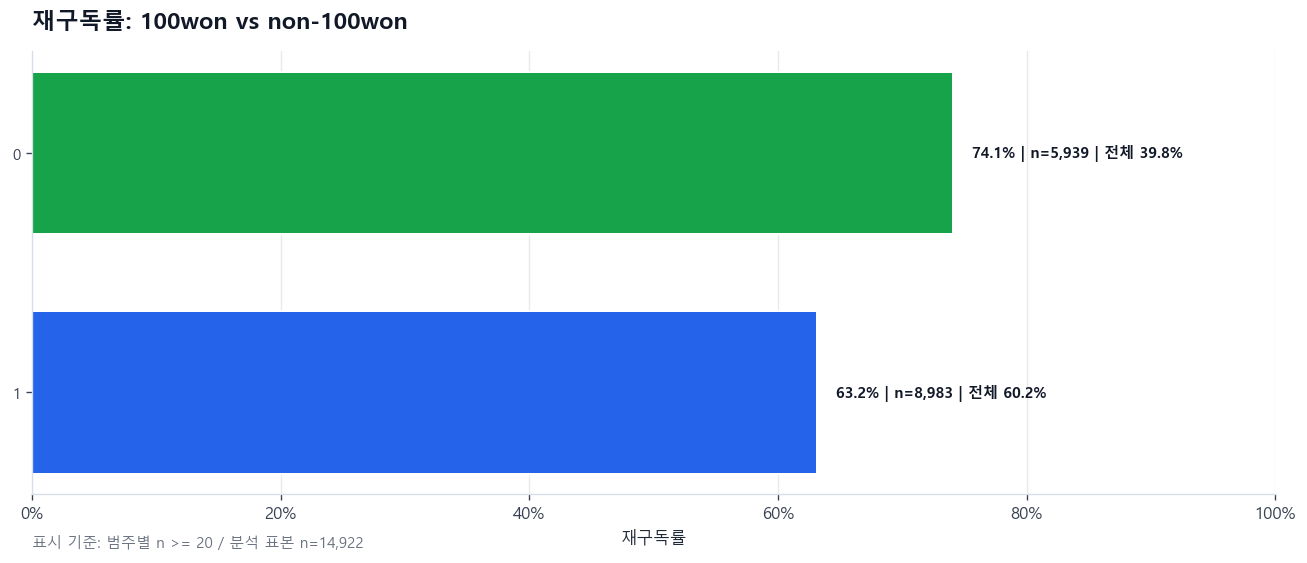

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_max_screen.png


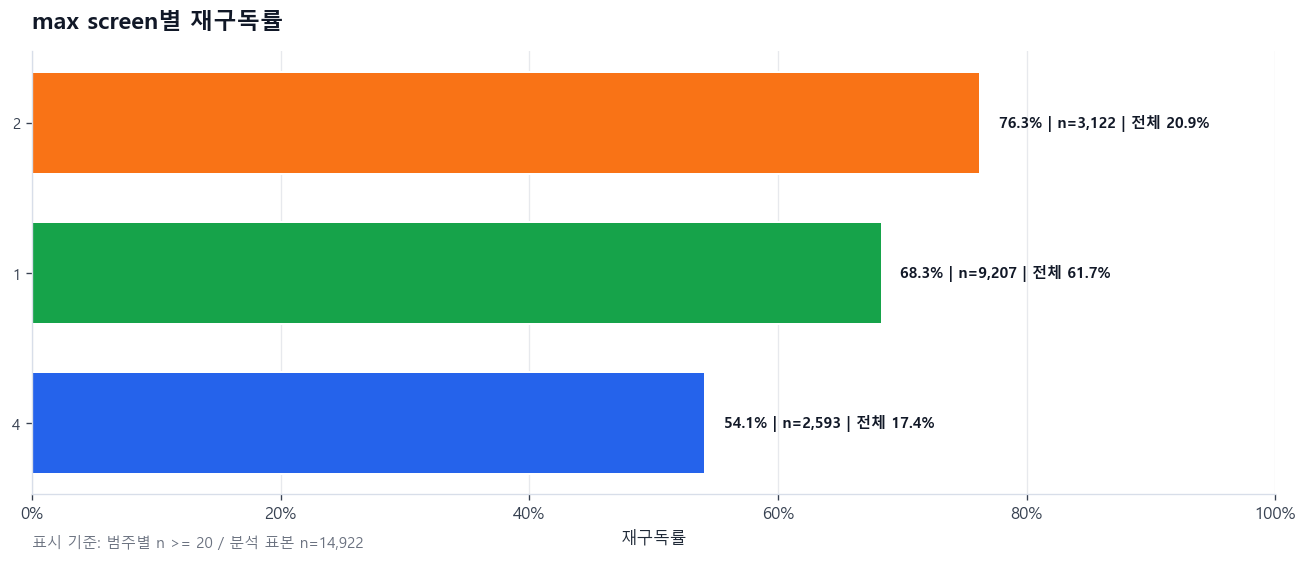

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_100won_max_screen.png


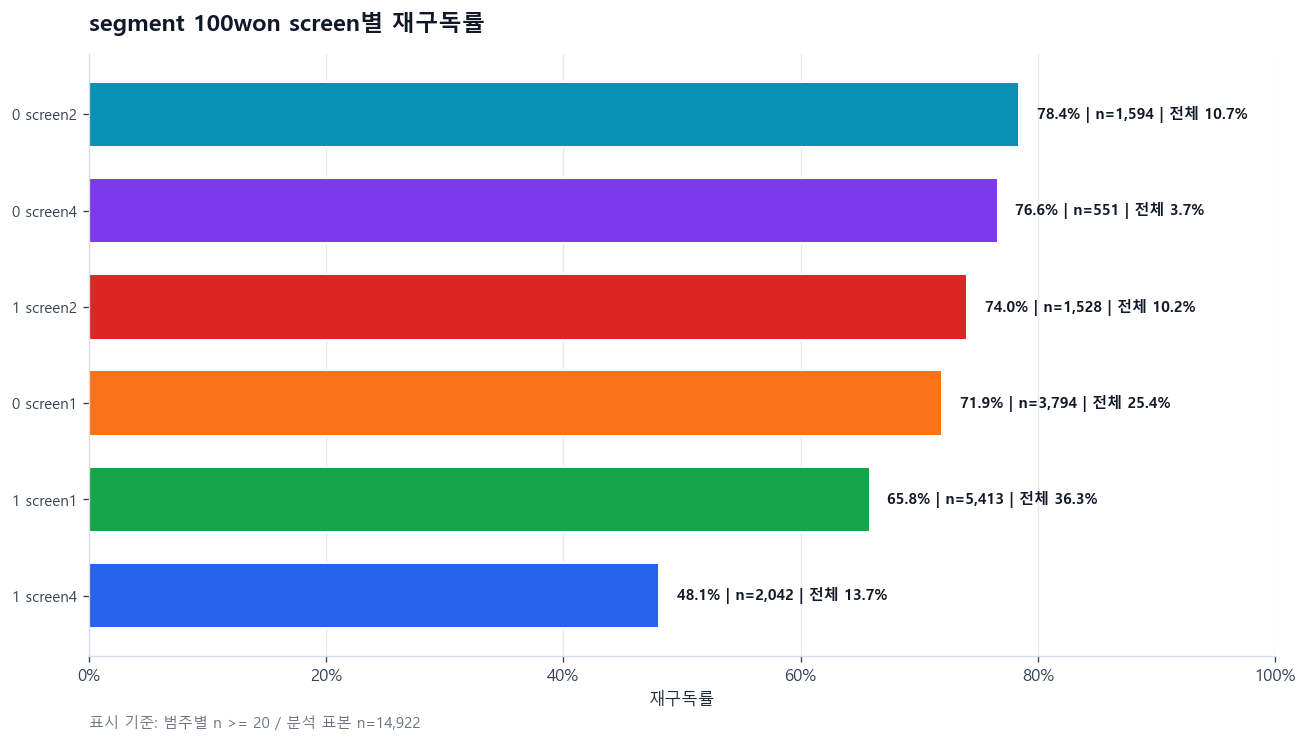

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_promo_x_2screen.png


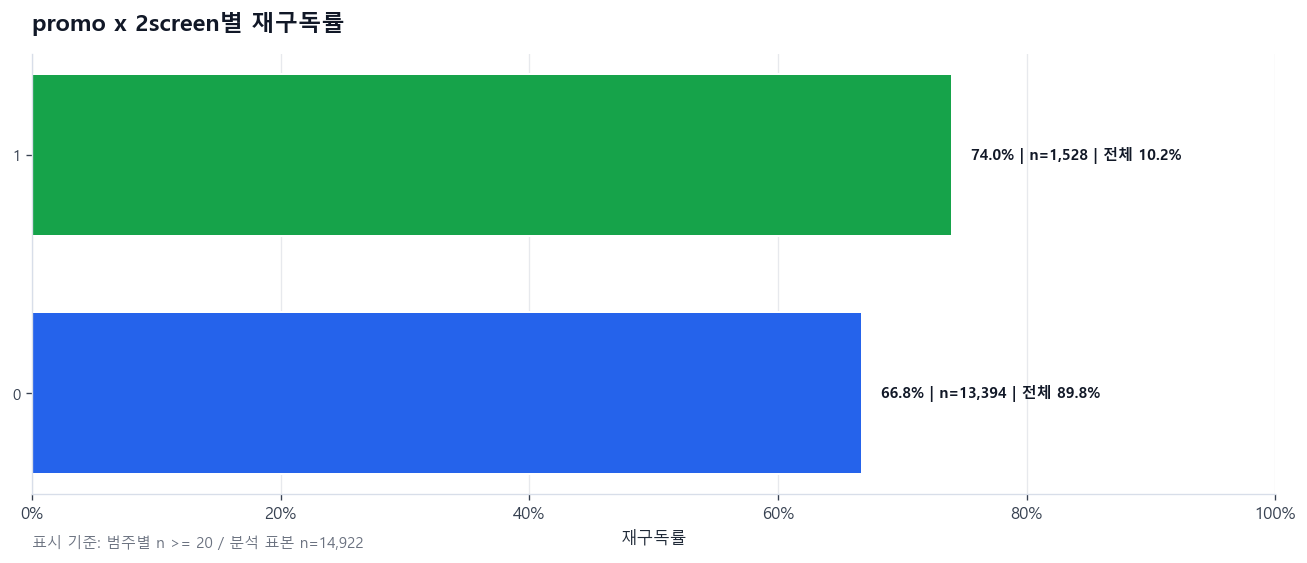

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_promo_x_4screen.png


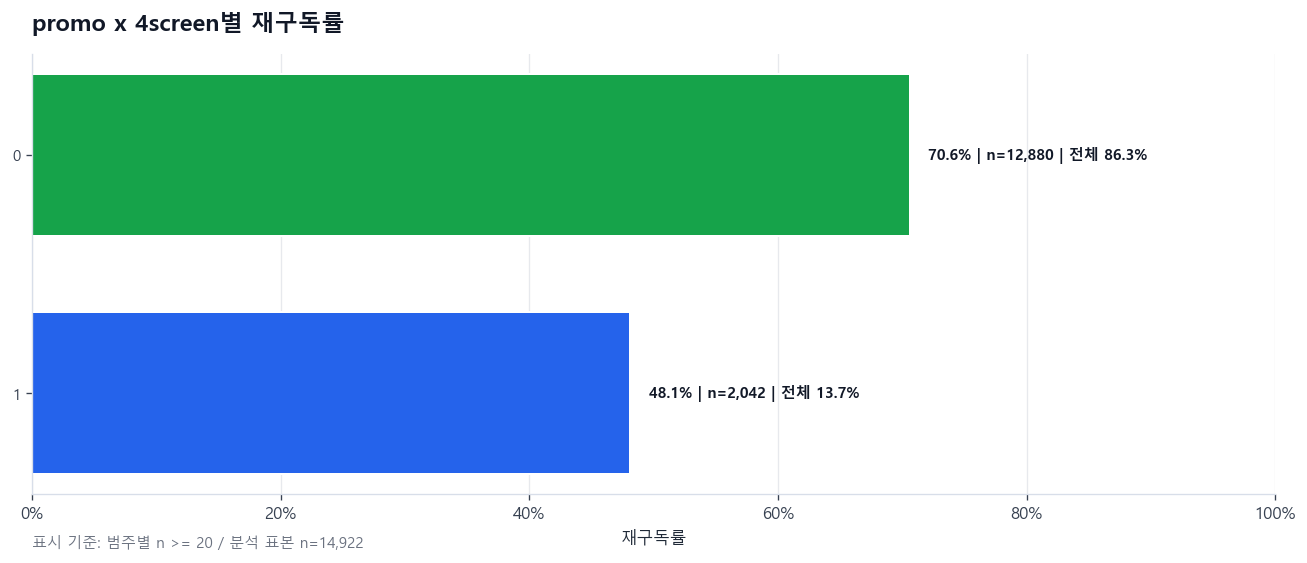

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_is_churn_prevented.png


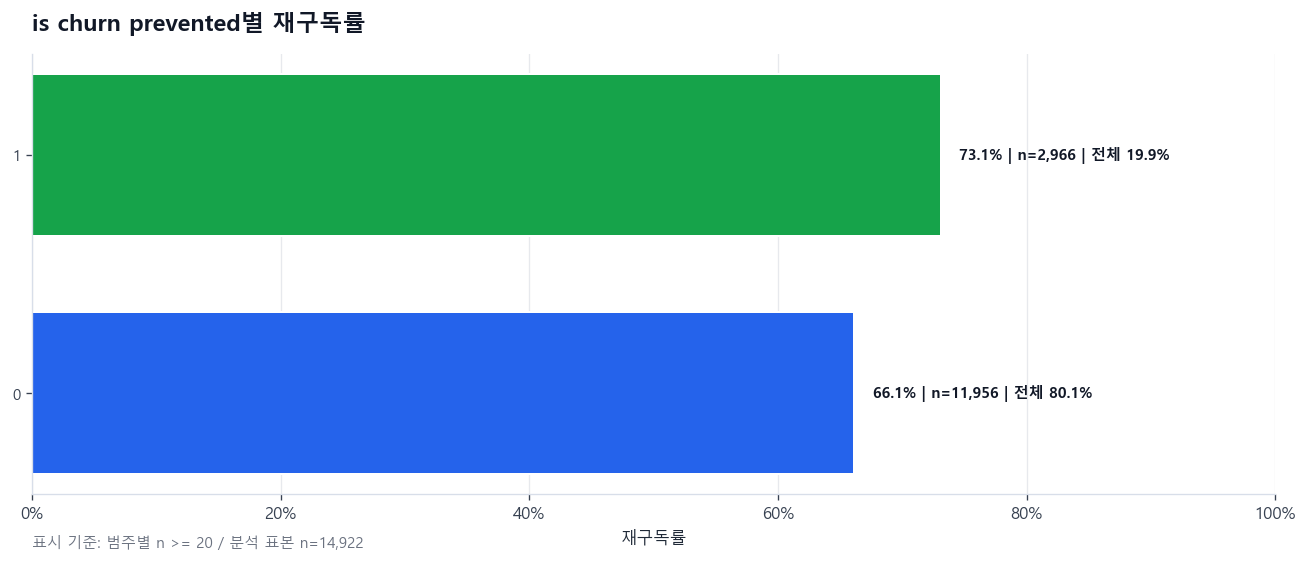

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_family_2screen_lifestyle.png


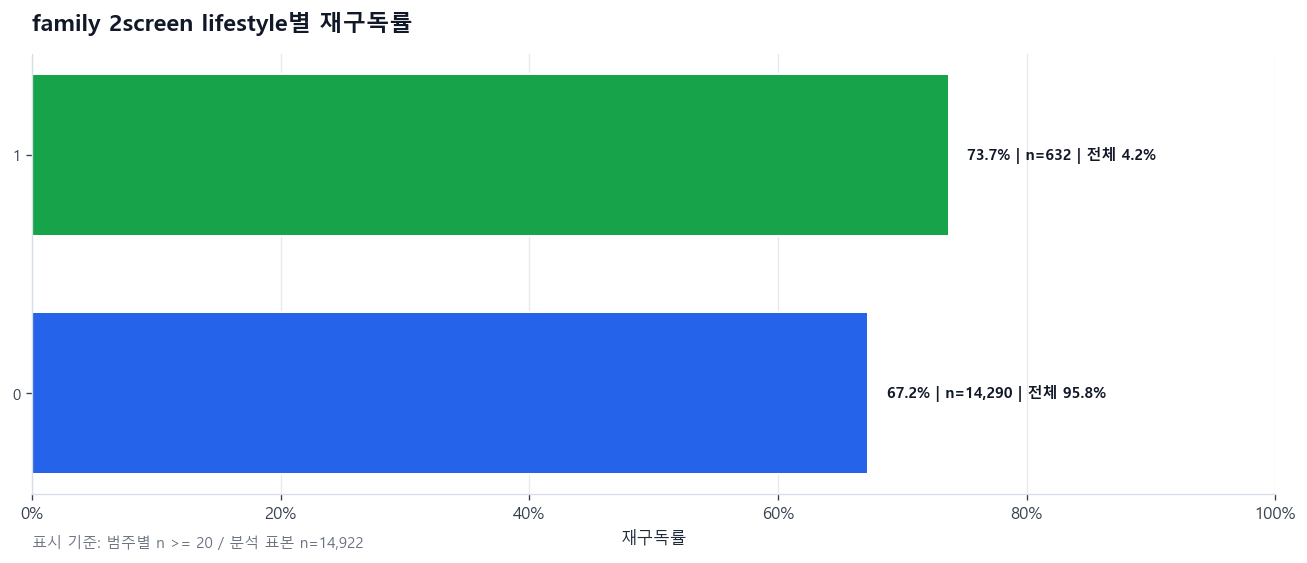

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_premium_action_trial_risk.png


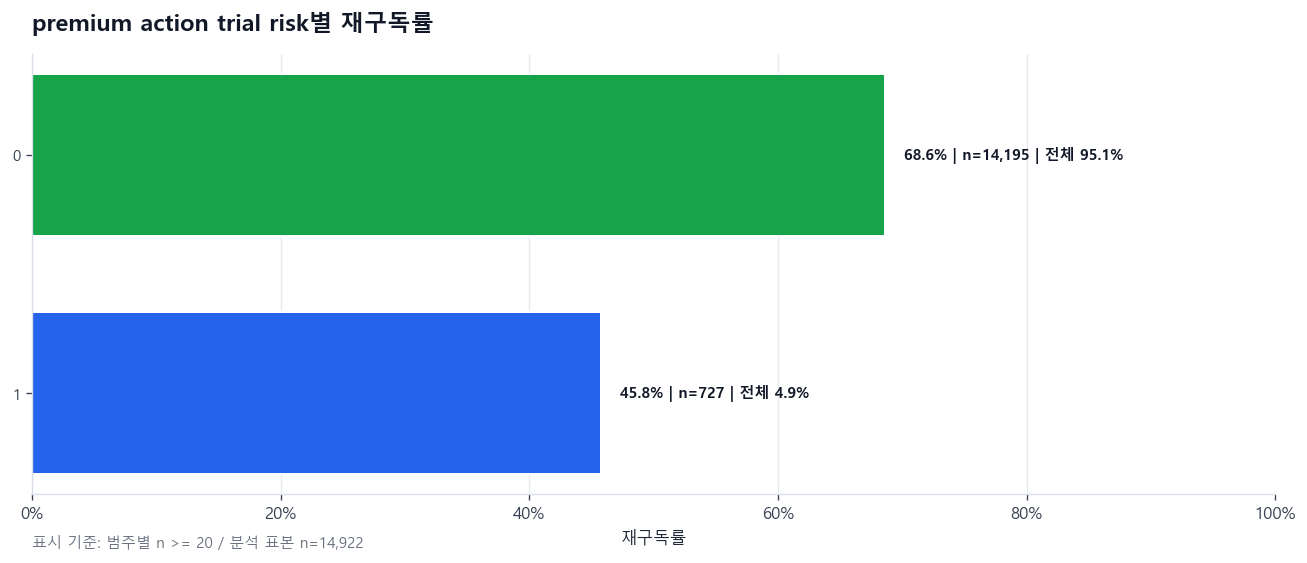

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_discount_sensitive_risk.png


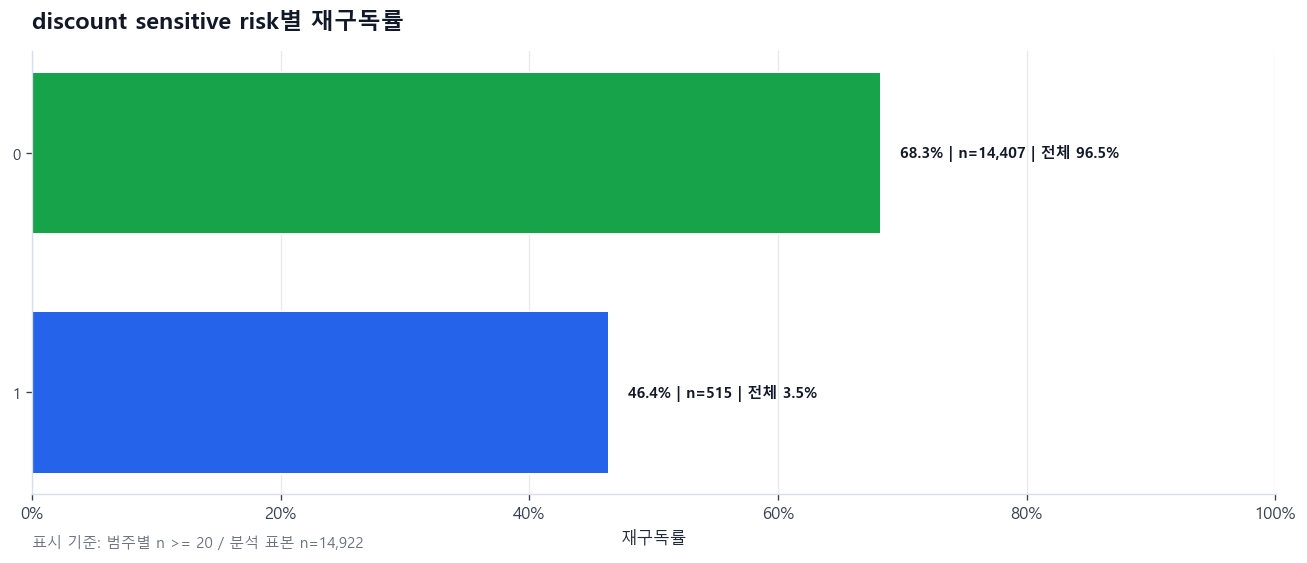

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_stable_2screen_active.png


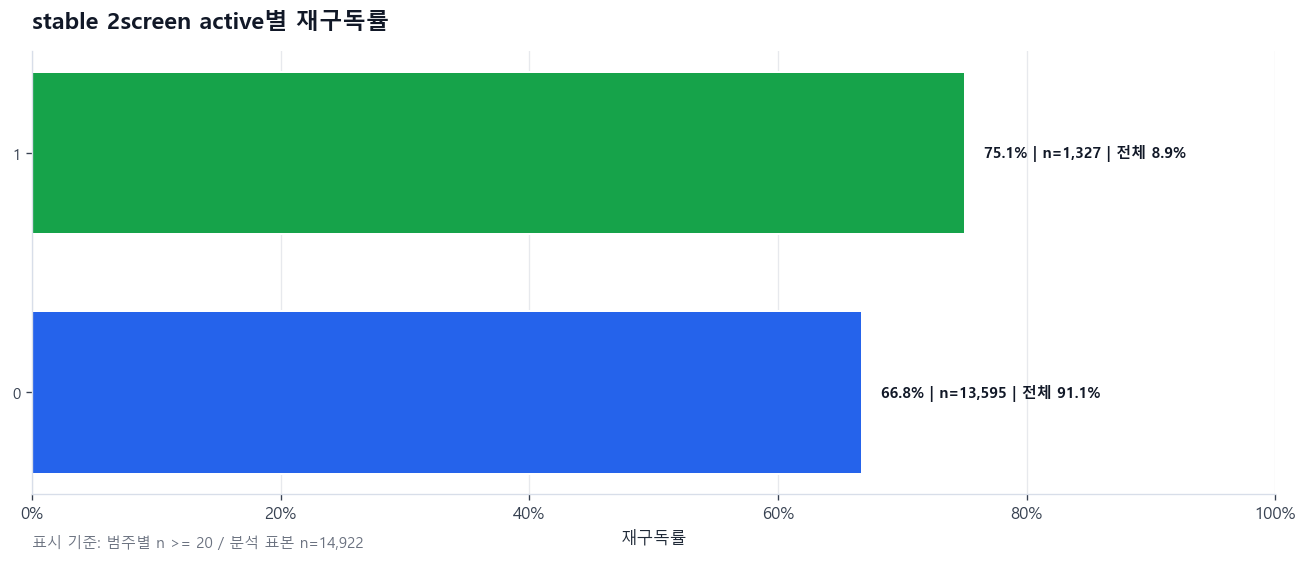

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_screen_1_flag.png


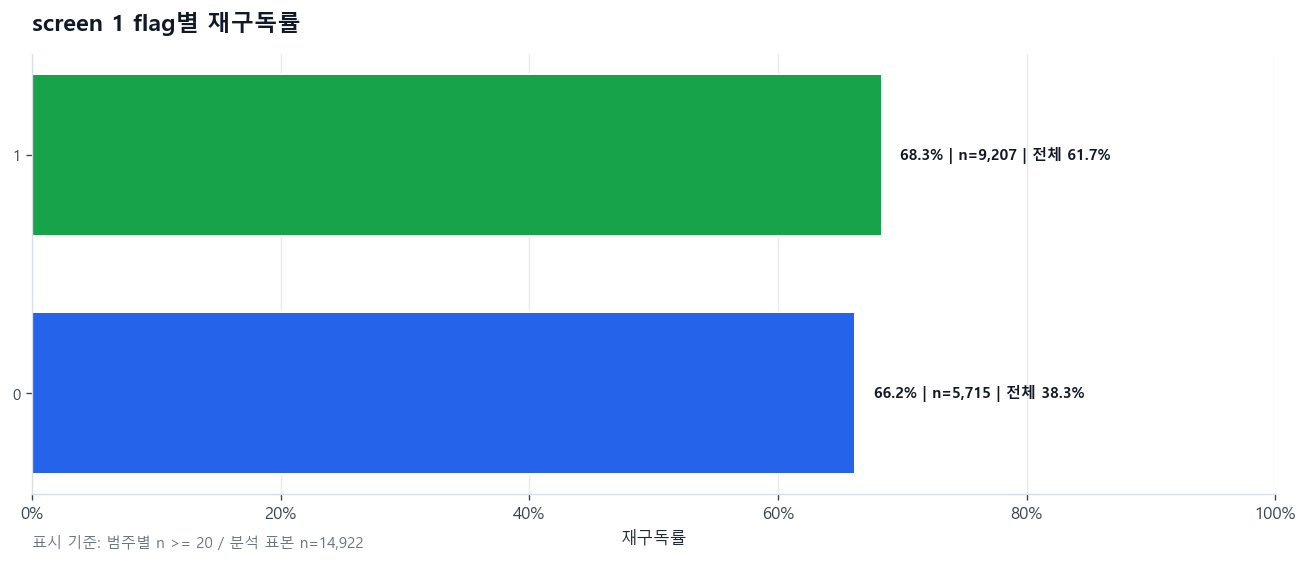

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_screen_2_flag.png


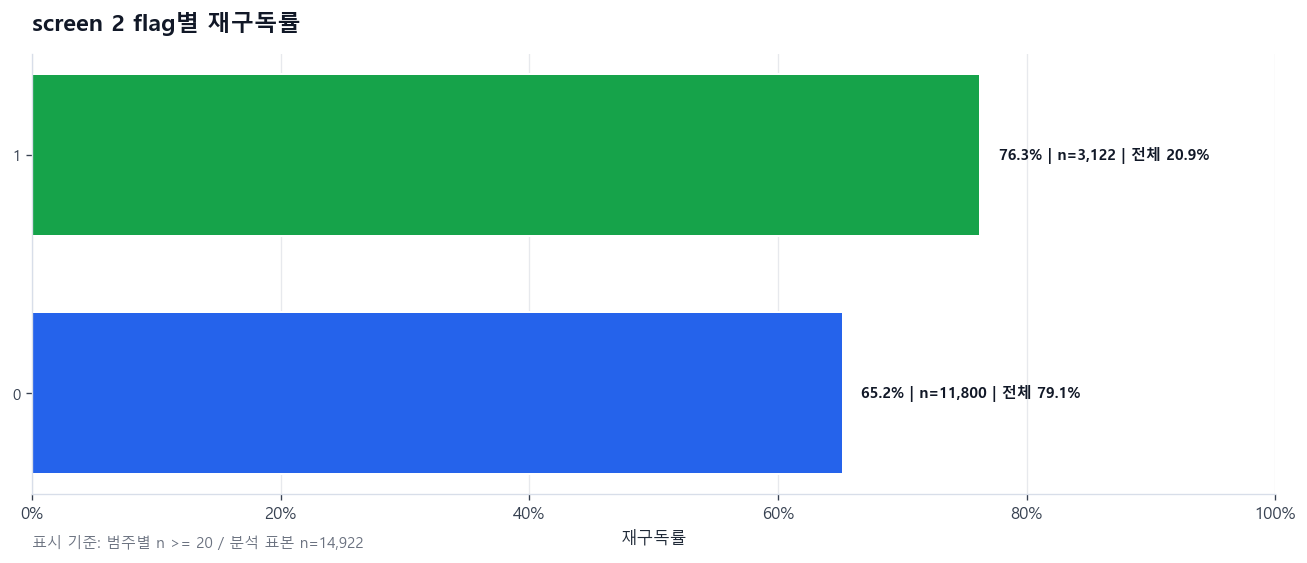

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_screen_4_flag.png


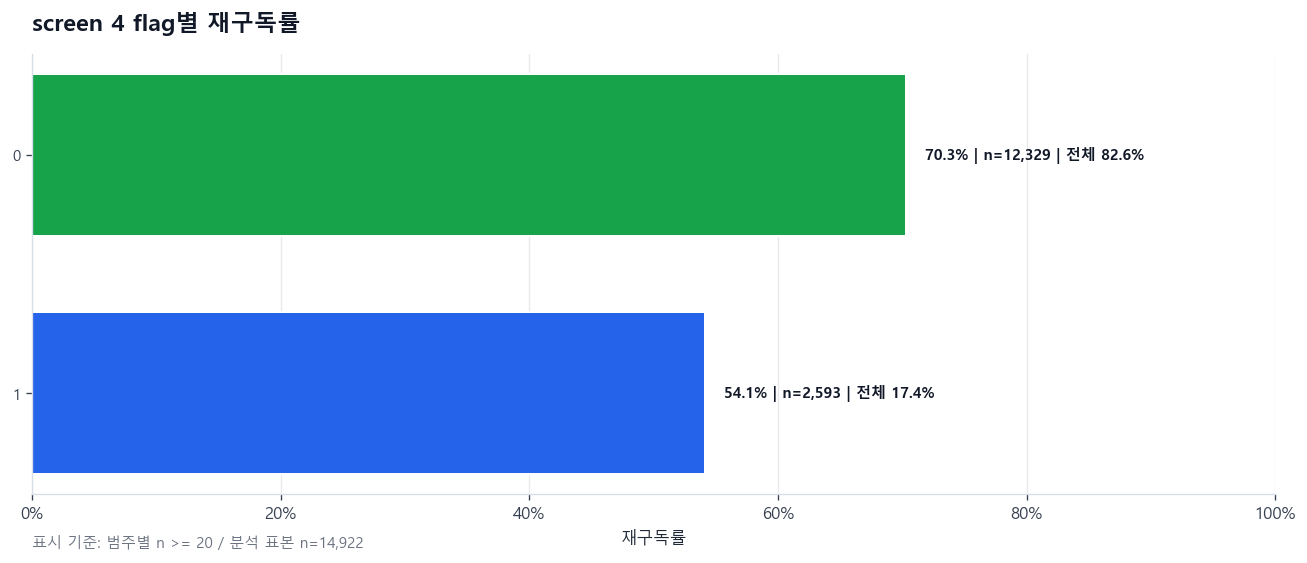

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_promo_x_1screen.png


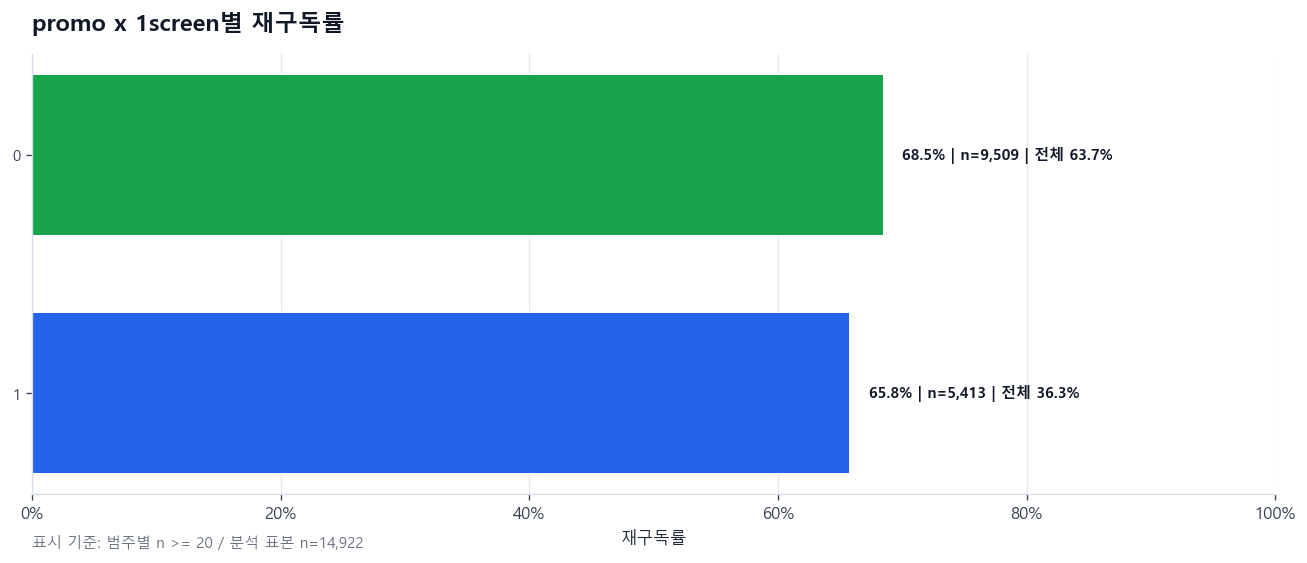

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_has_watch_obs.png


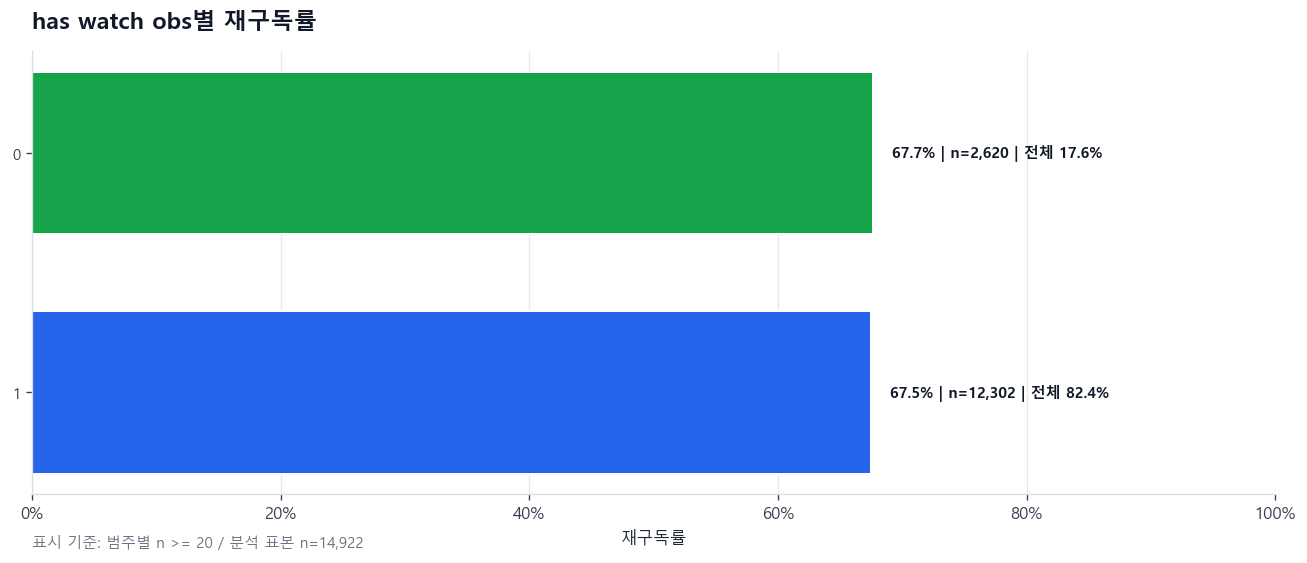

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_has_content_feature.png


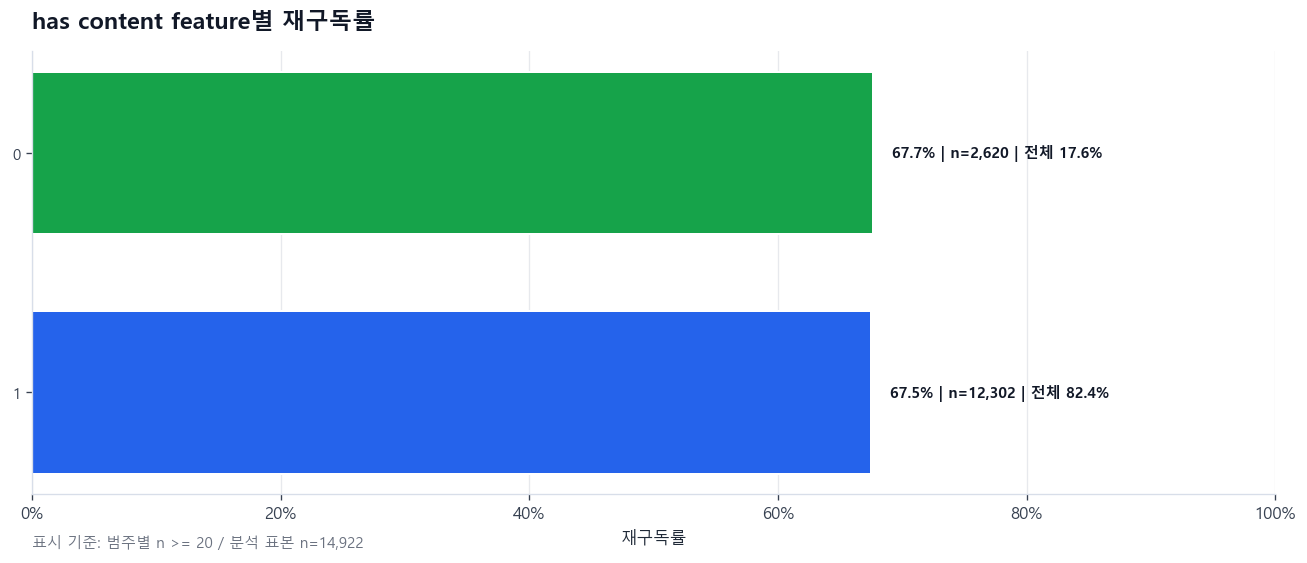

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_family_content_affinity.png


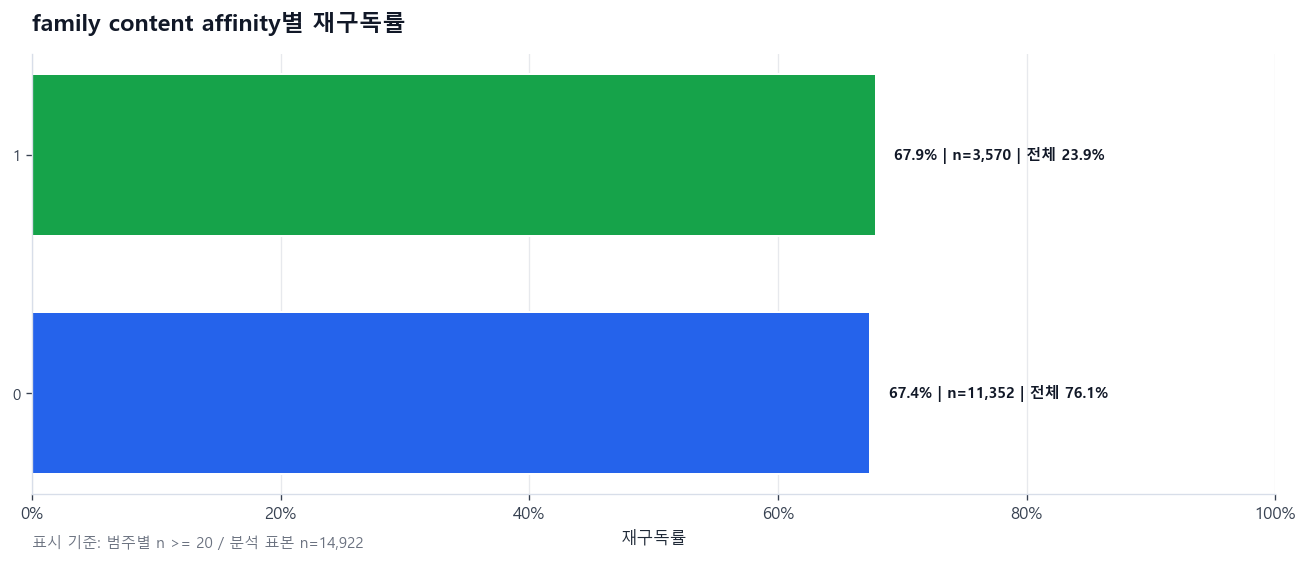

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_age_band.png


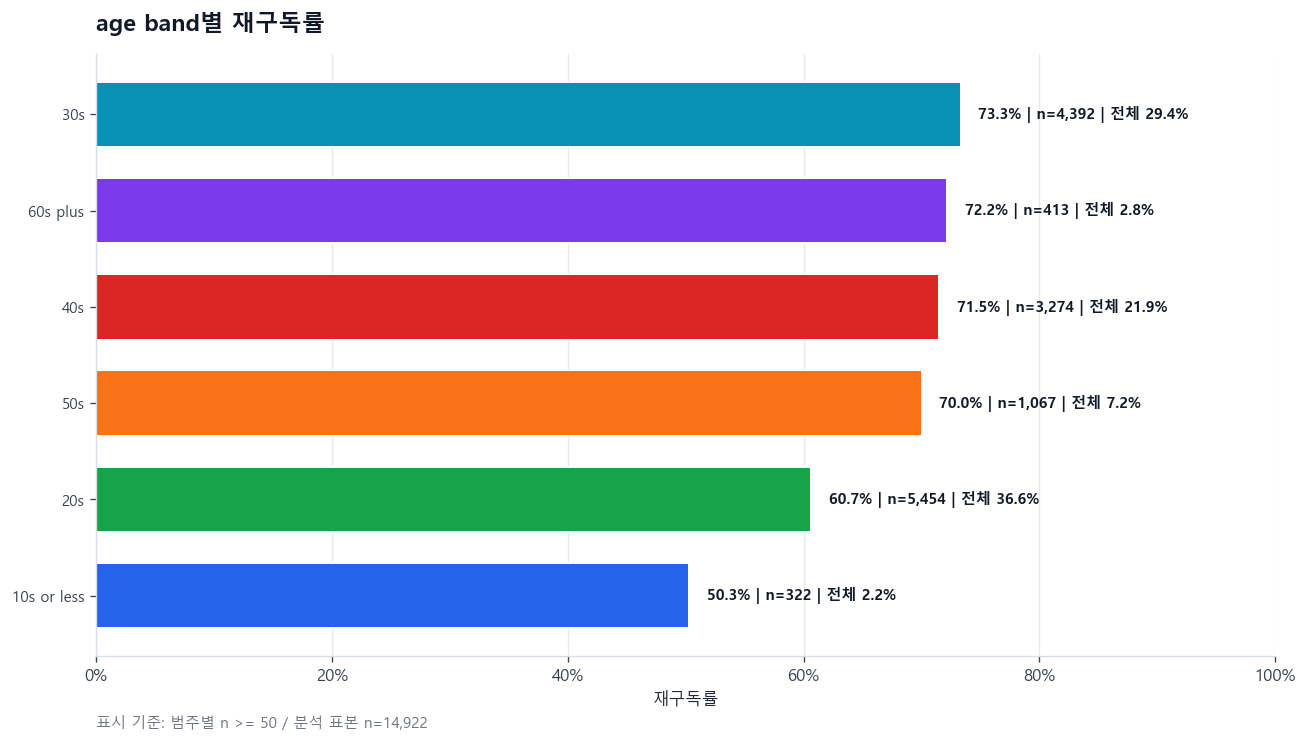

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_top_genre_tag.png


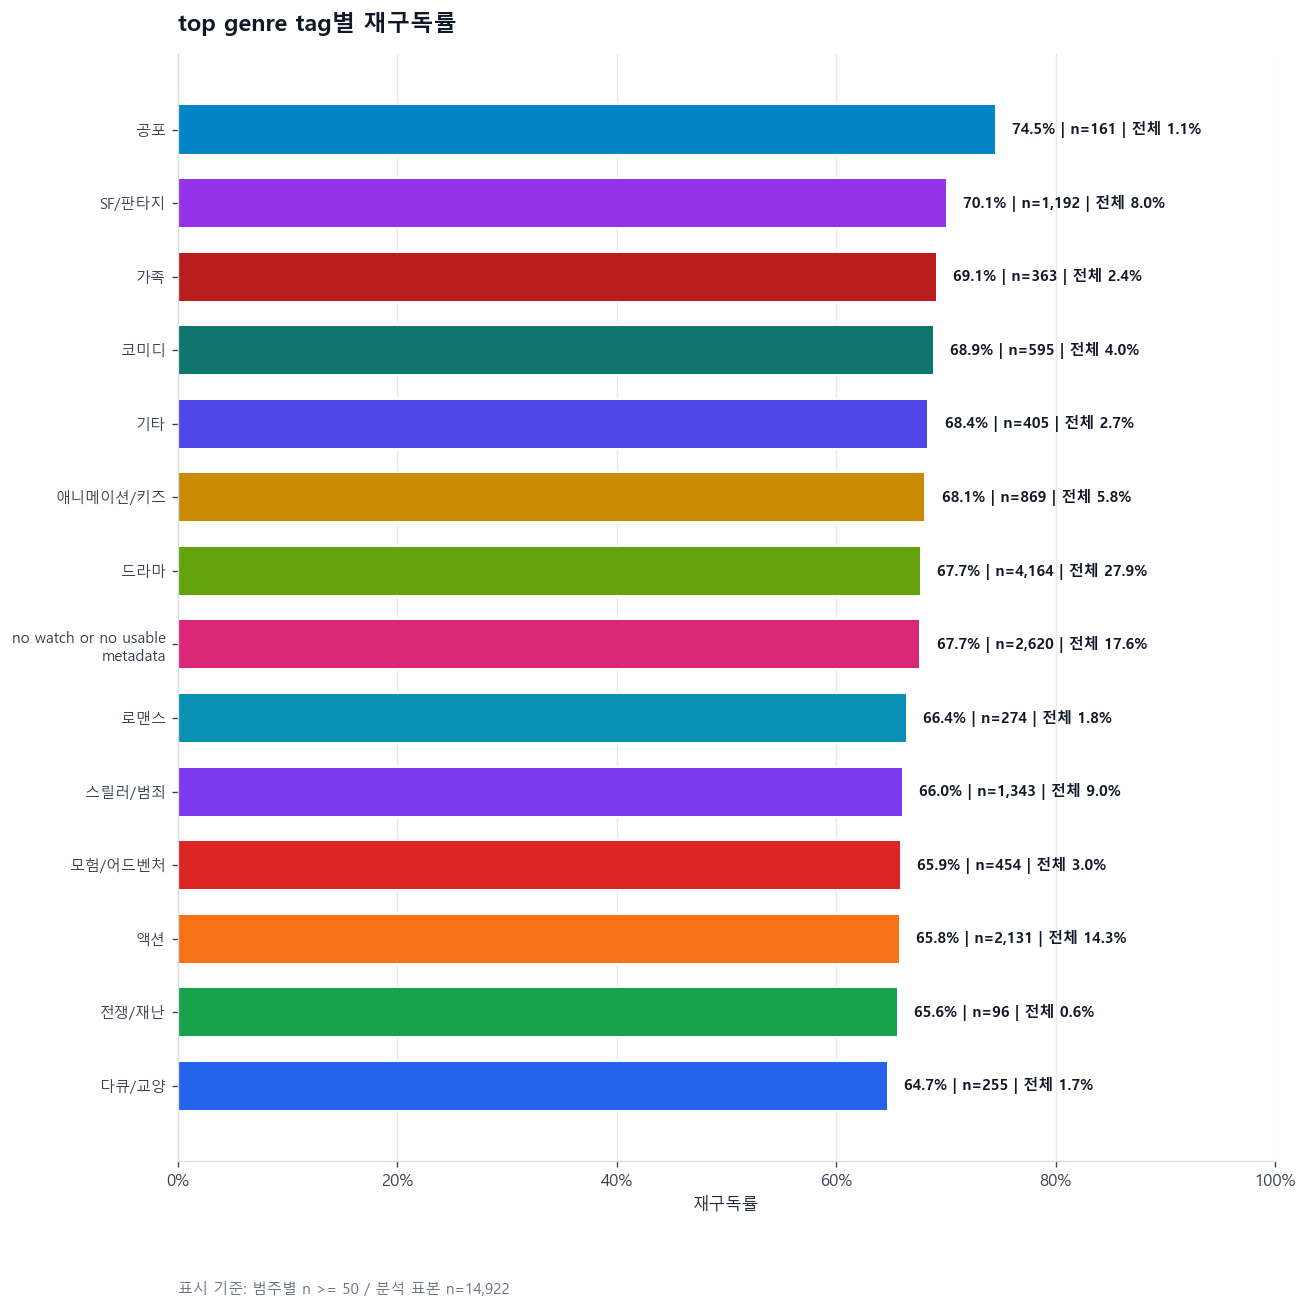

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_gender.png


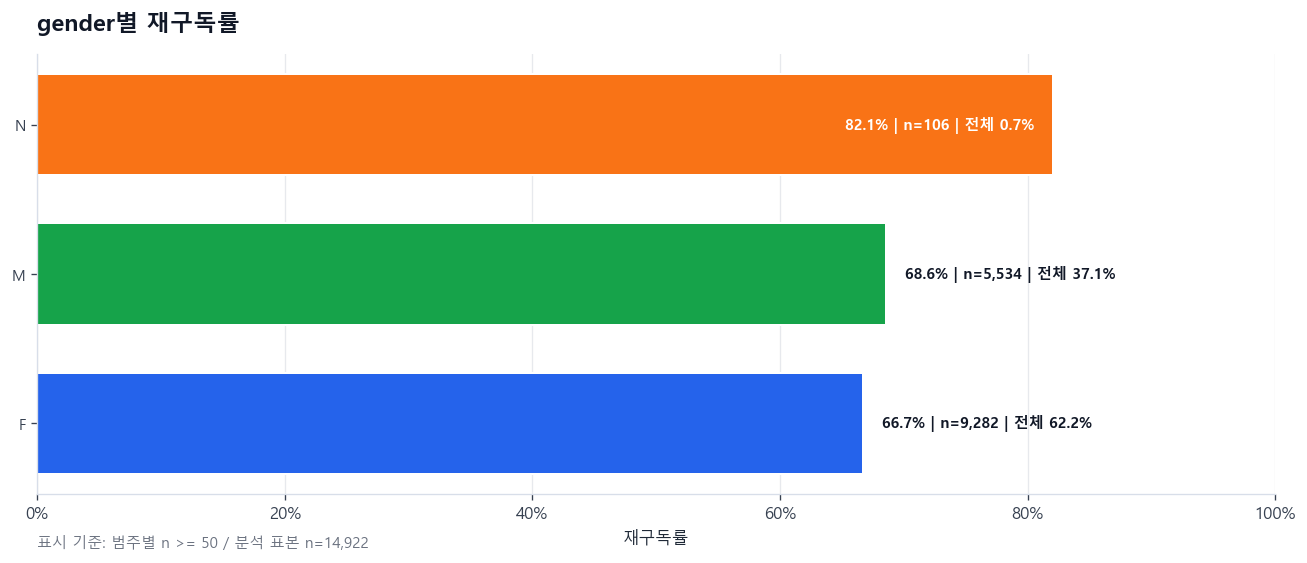

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_billing_method.png


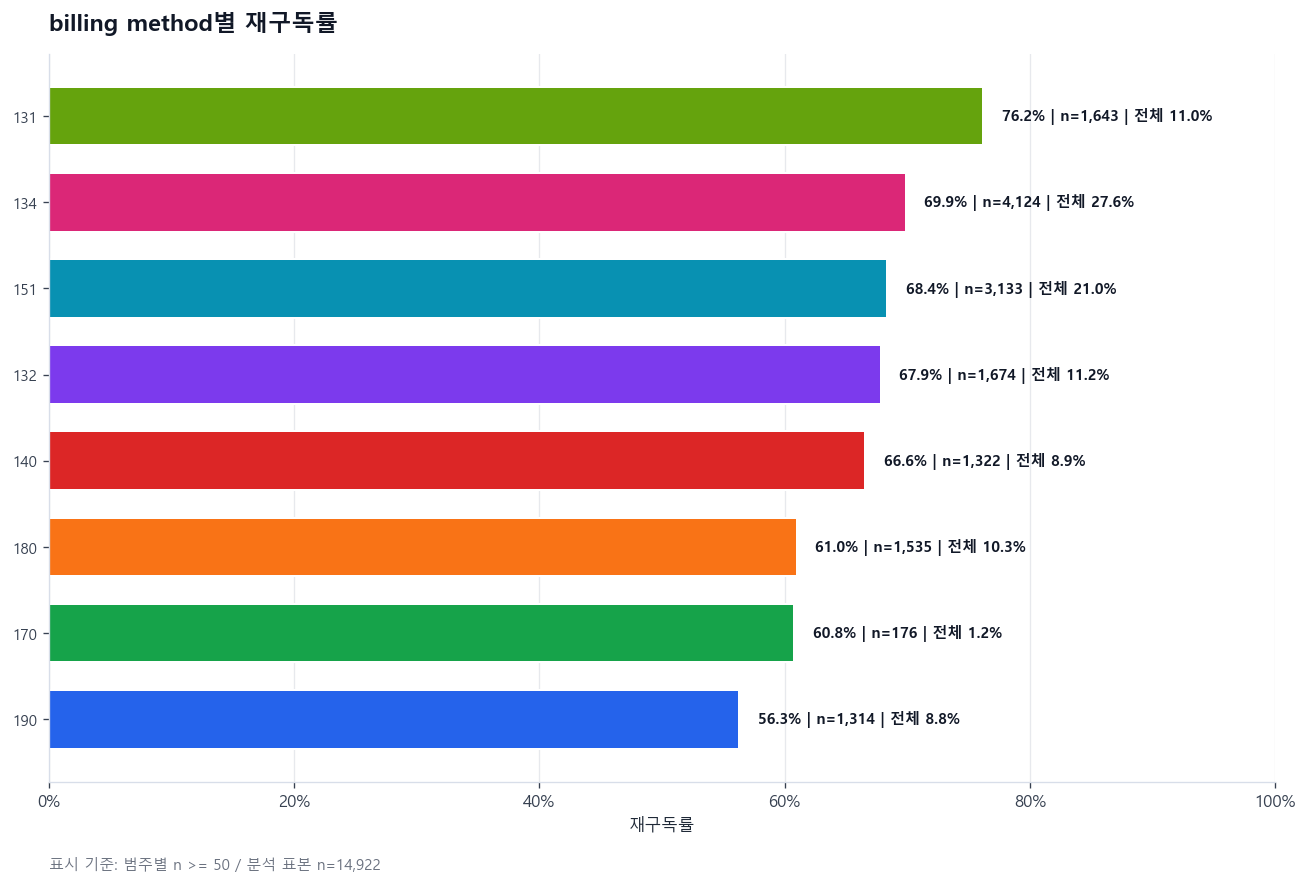

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_rate_by_payment_device.png


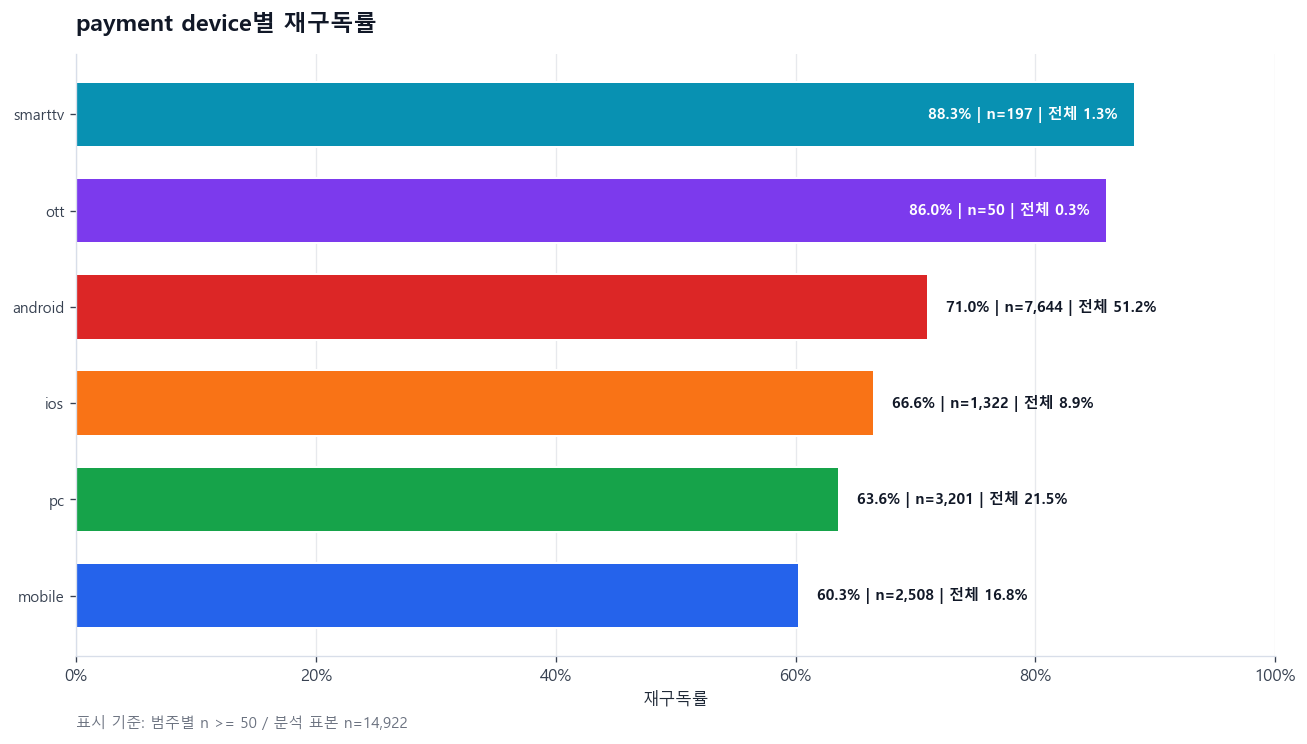

In [49]:
# 6-12. 핵심 categorical/binary rate plot

if RUN_CORE_FIGURES or RUN_ALL_FIGURES:
    plot_rate_by_category(df, 'is_100won', 'Repurchase rate: 100won vs non-100won', '06_rate_by_100won.png')
    plot_rate_by_category(df, 'max_screen', 'Repurchase rate by max_screen', '06_rate_by_max_screen.png')

    if {'is_100won', 'max_screen'}.issubset(df.columns):
        tmp = df.copy()
        tmp['segment_100won_screen'] = tmp['is_100won'].astype(str) + '_screen' + tmp['max_screen'].astype(str)
        plot_rate_by_category(tmp, 'segment_100won_screen', 'Repurchase rate by 100won x max_screen', '06_rate_by_100won_max_screen.png')

    binary_cols_to_plot = [
        'promo_x_2screen', 'promo_x_4screen', 'is_churn_prevented',
        'family_2screen_lifestyle', 'premium_action_trial_risk',
        'discount_sensitive_risk', 'stable_2screen_active',
    ]
    if RUN_ALL_FIGURES:
        binary_cols_to_plot += [
            'screen_1_flag', 'screen_2_flag', 'screen_4_flag',
            'promo_x_1screen', 'has_watch_obs', 'has_content_feature',
            'family_content_affinity', 'premium_action_content_affinity',
        ]
    for col in binary_cols_to_plot:
        if col in df.columns:
            plot_rate_by_category(df, col, f'Repurchase rate by {col}', f'06_rate_by_{col}.png')

    cat_cols_to_plot = ['age_band', 'top_genre_tag']
    if RUN_ALL_FIGURES:
        cat_cols_to_plot += ['gender', 'billing_method', 'payment_device']
    for col in cat_cols_to_plot:
        if col in df.columns:
            plot_rate_by_category(df, col, f'Repurchase rate by {col}', f'06_rate_by_{col}.png', min_n=50)

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_age.png


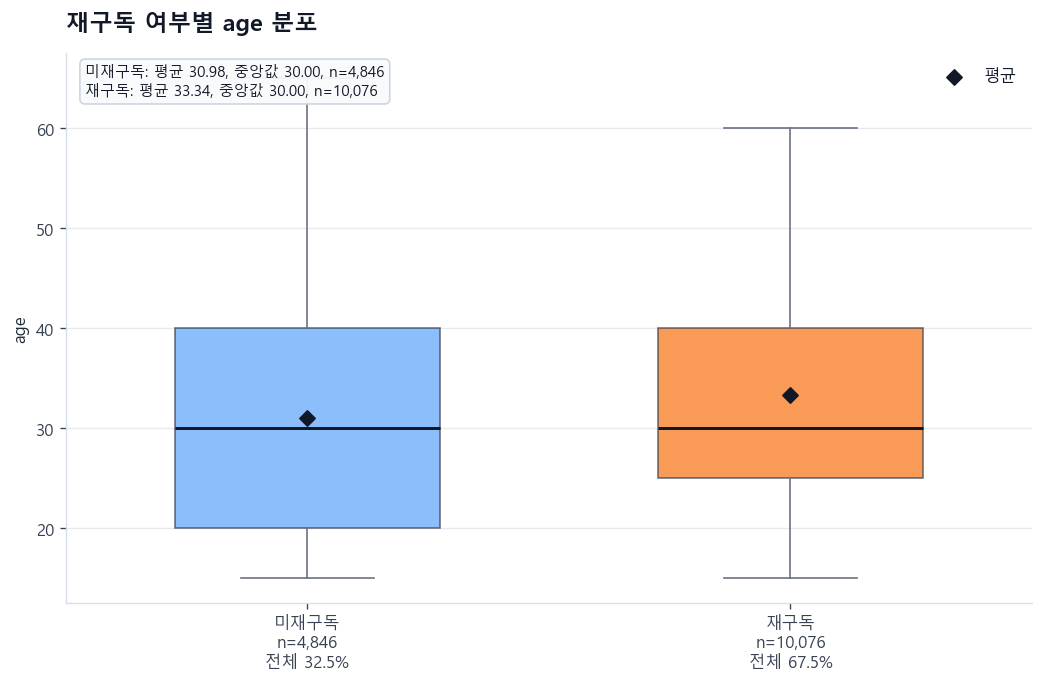

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_total_watch_time.png


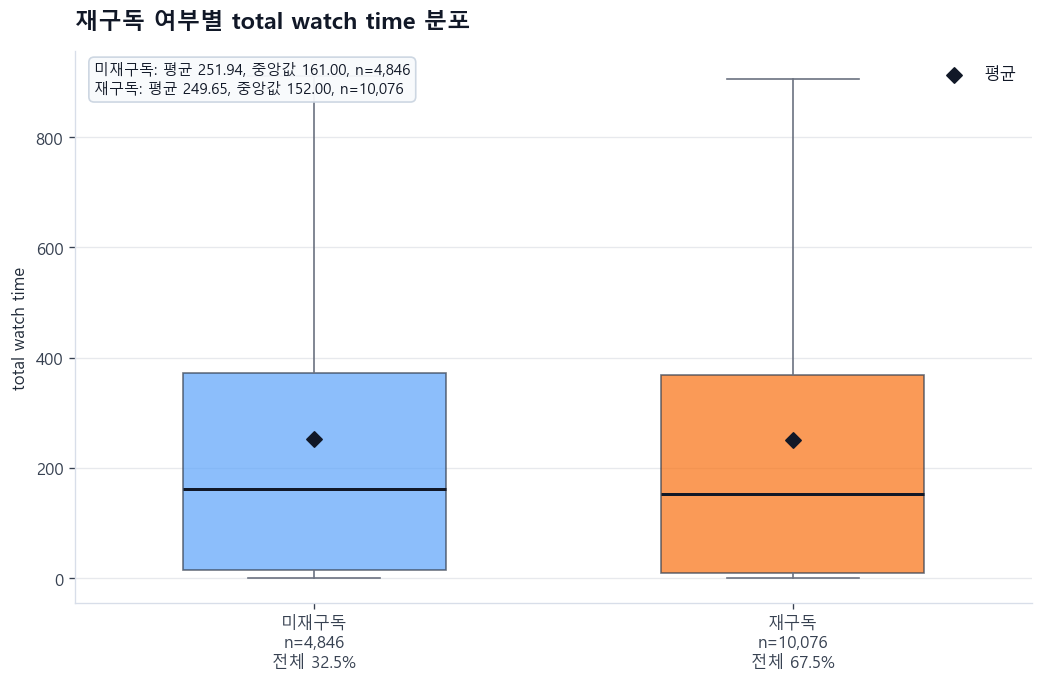

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_total_sessions.png


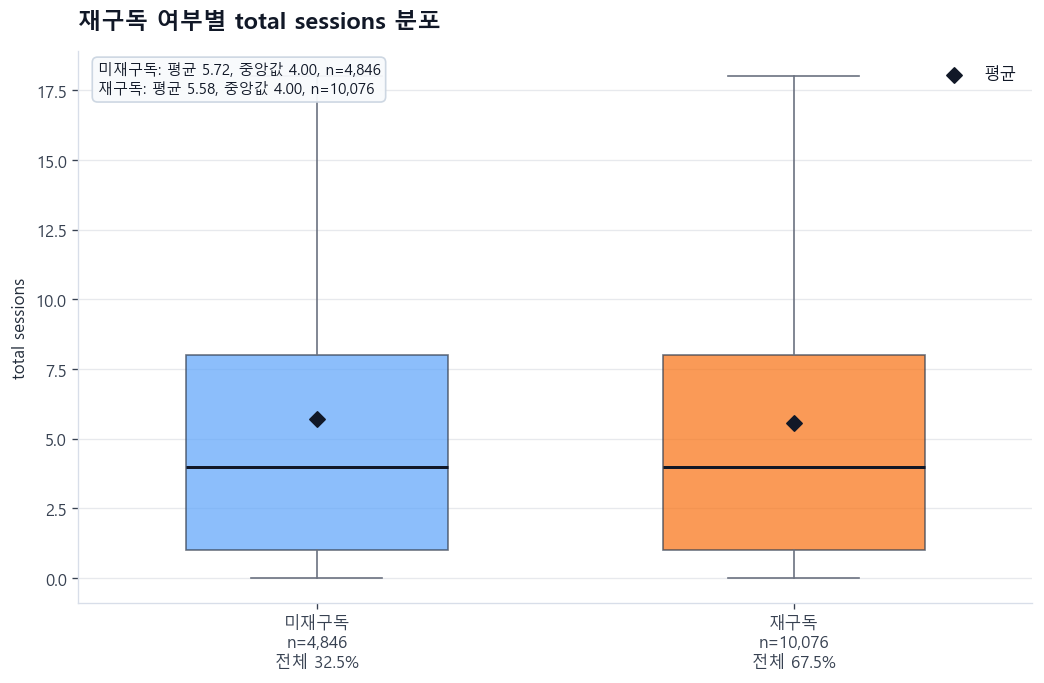

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_unique_contents.png


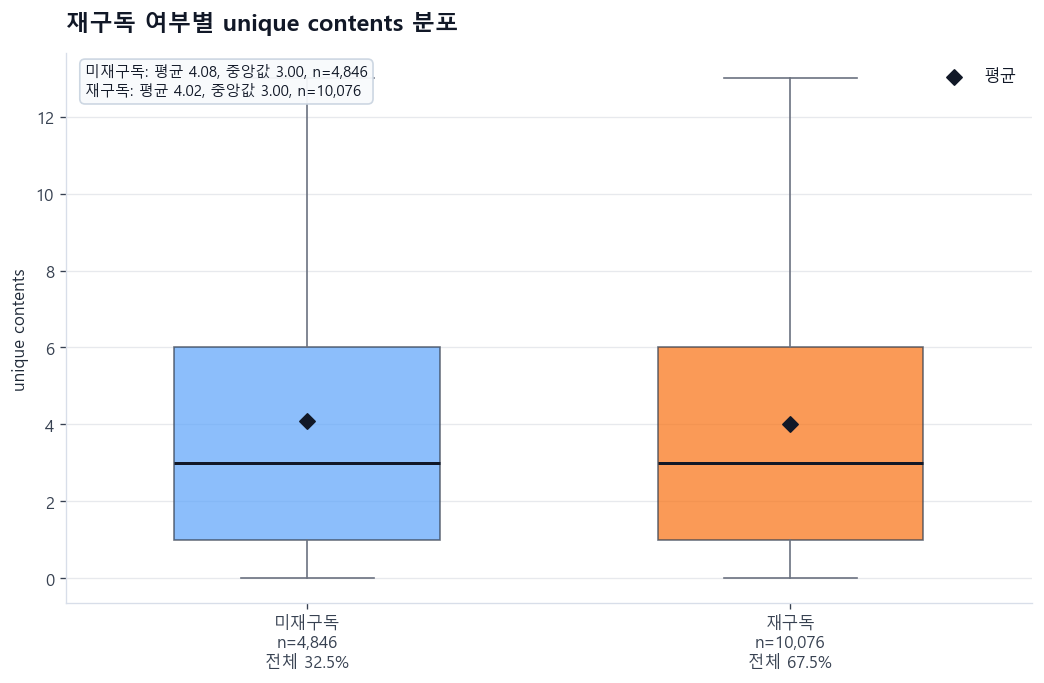

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_unique_days.png


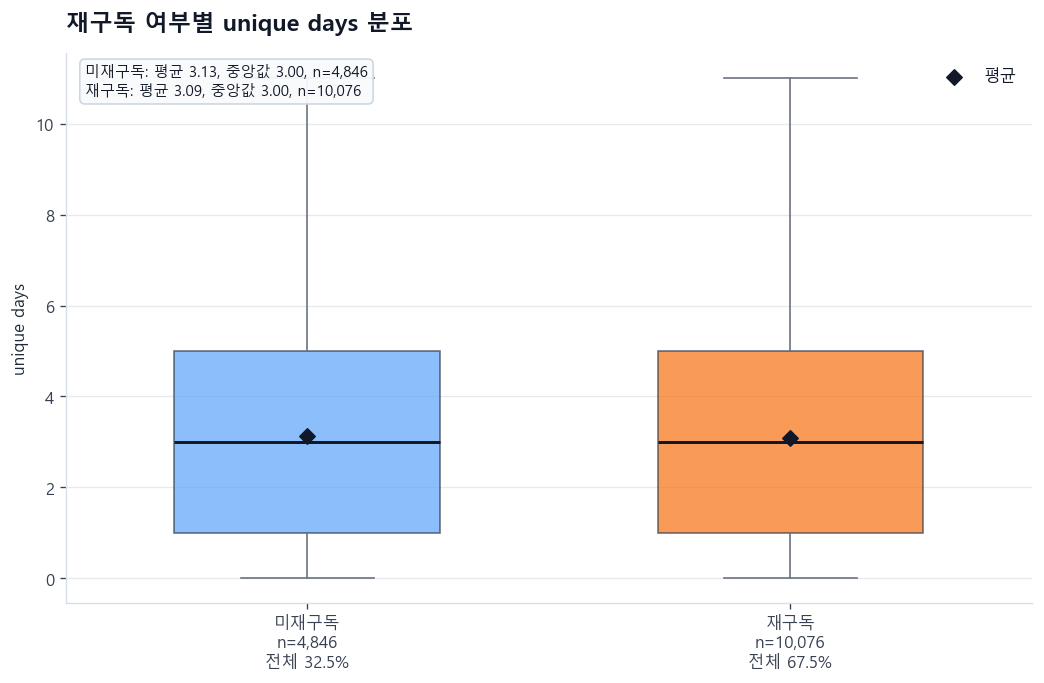

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_week1_watch_time.png


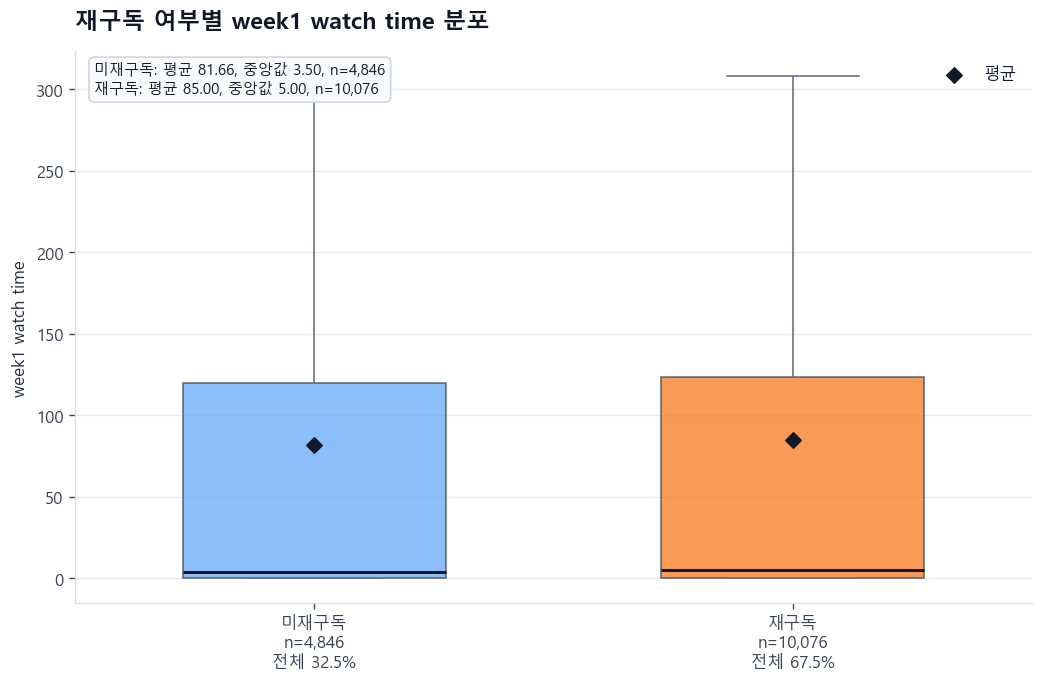

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_week2_watch_time.png


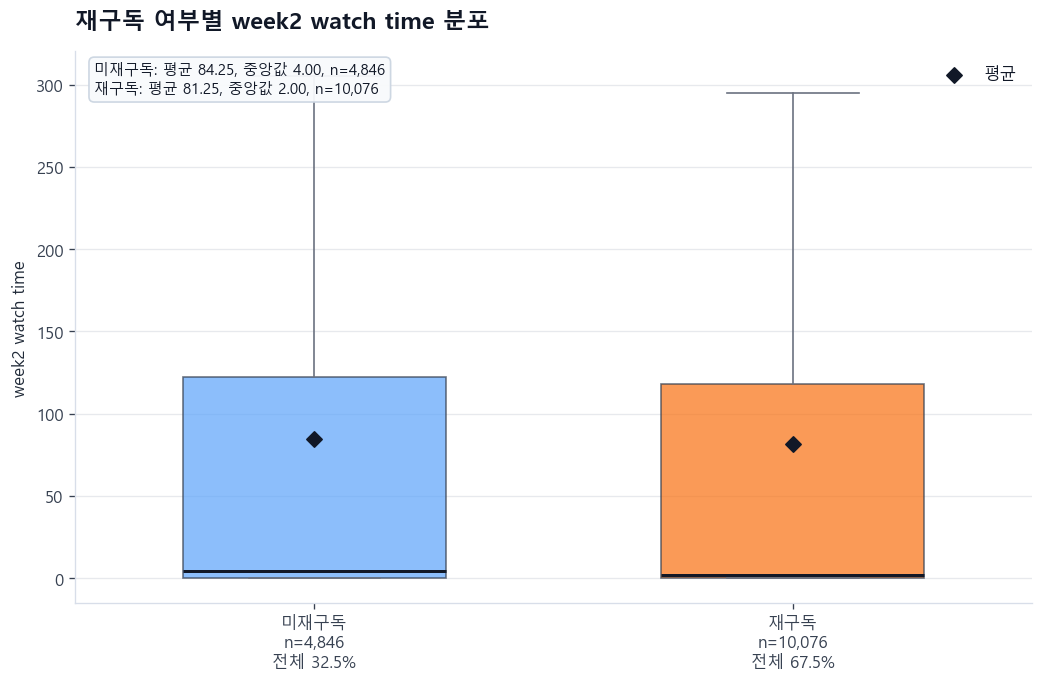

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_week3_watch_time.png


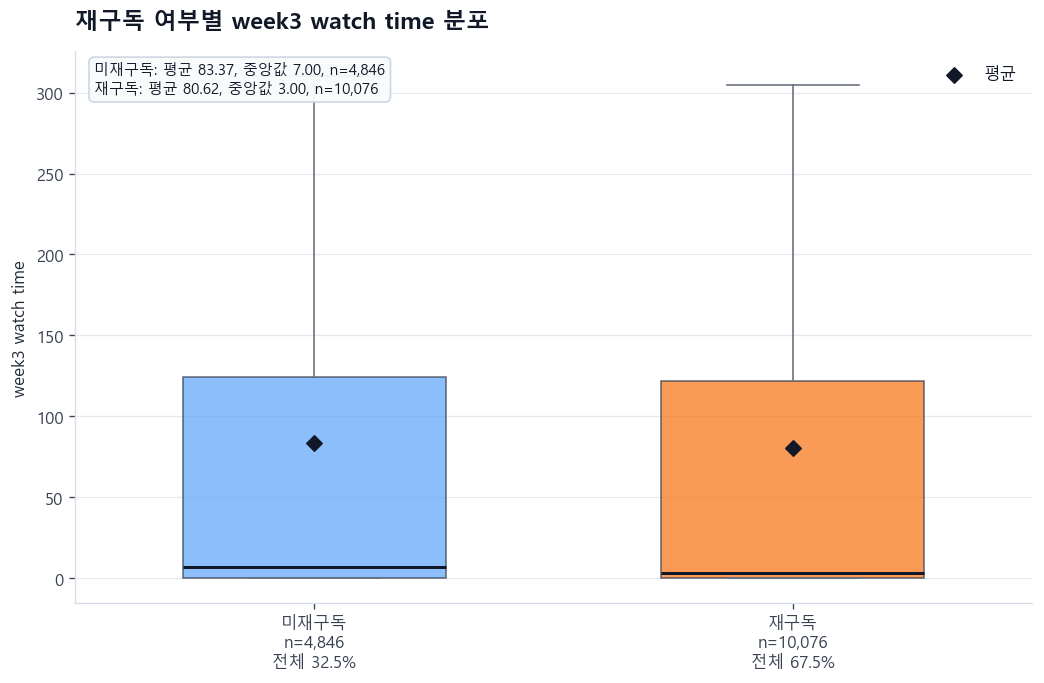

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_week1_ratio.png


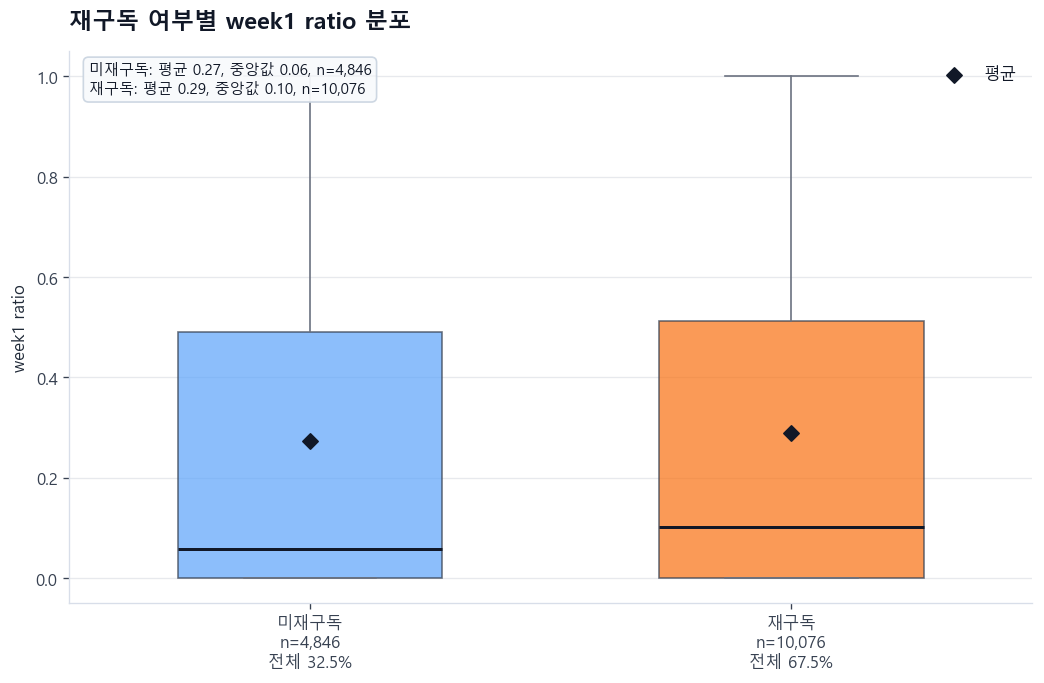

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_week2_ratio.png


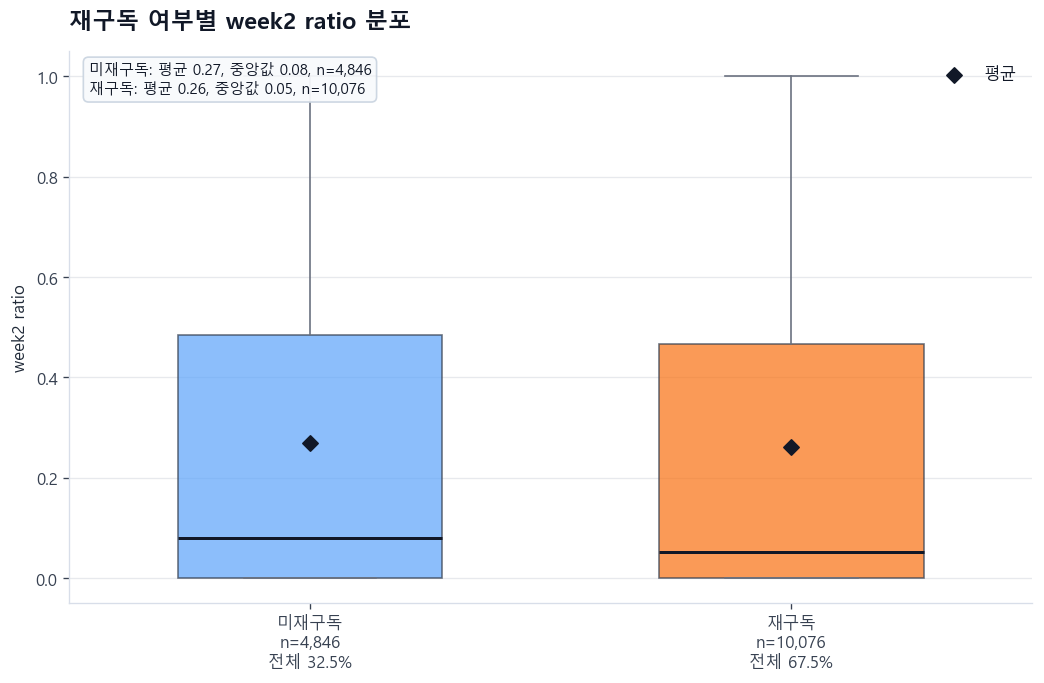

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_week3_ratio.png


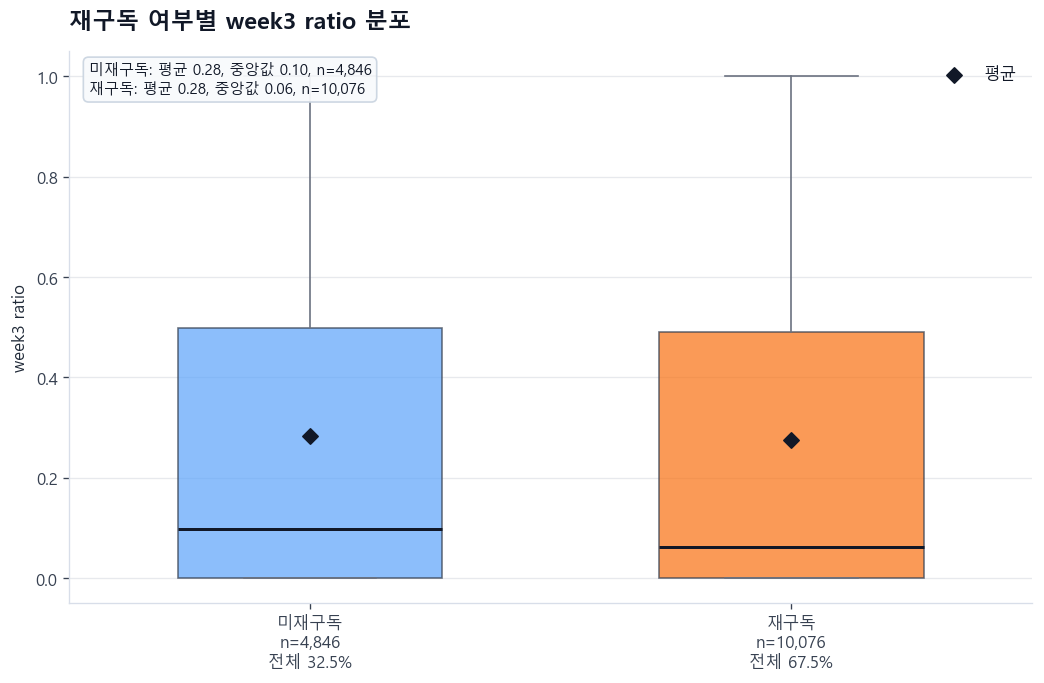

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_w3_minus_w1_watch_time.png


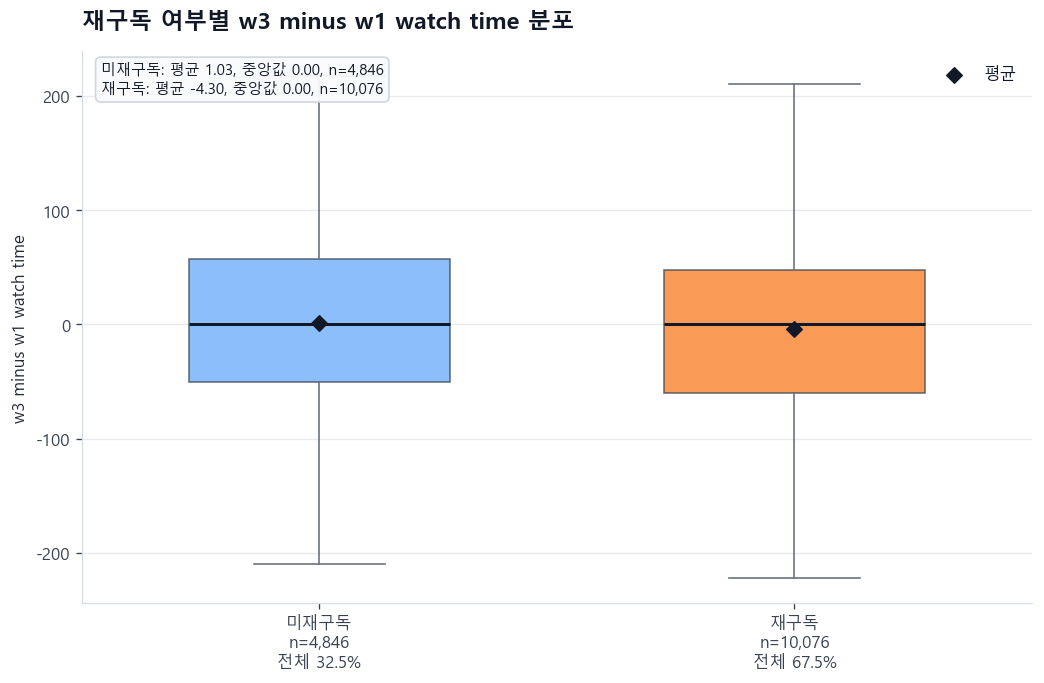

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_daily_watch_slope.png


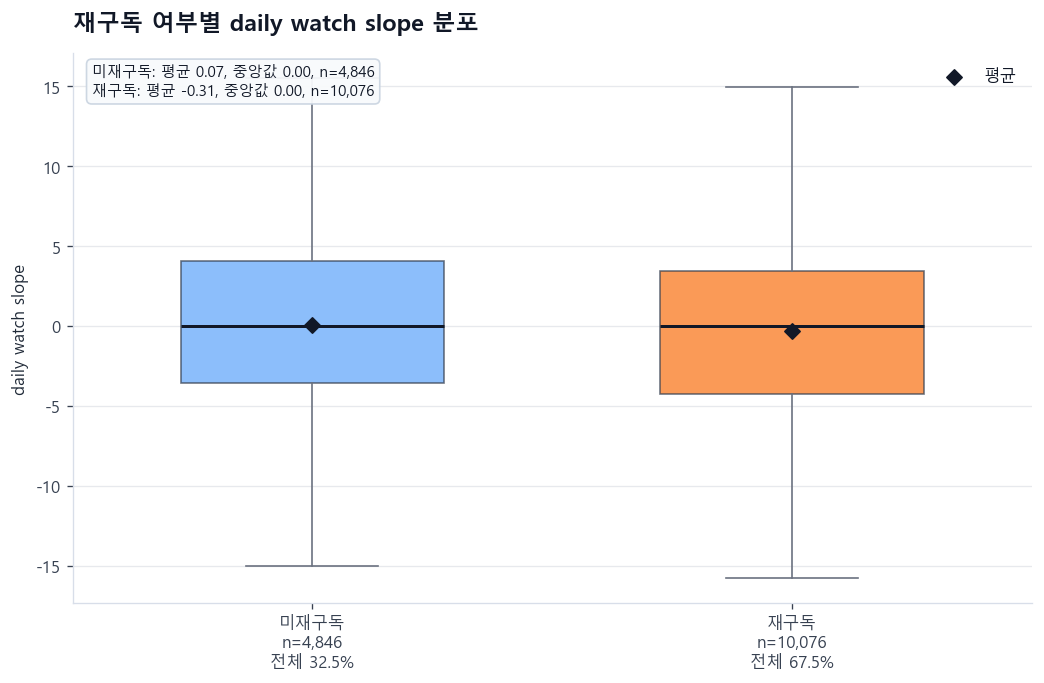

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_max_day_share.png


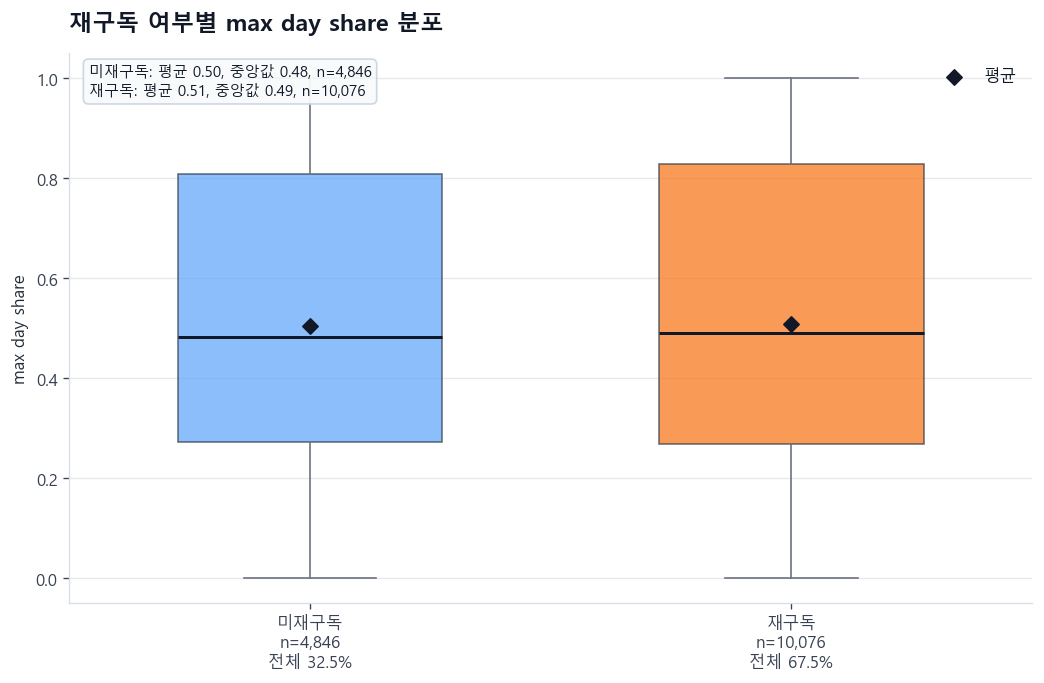

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_days_since_last_watch_to_obs_end.png


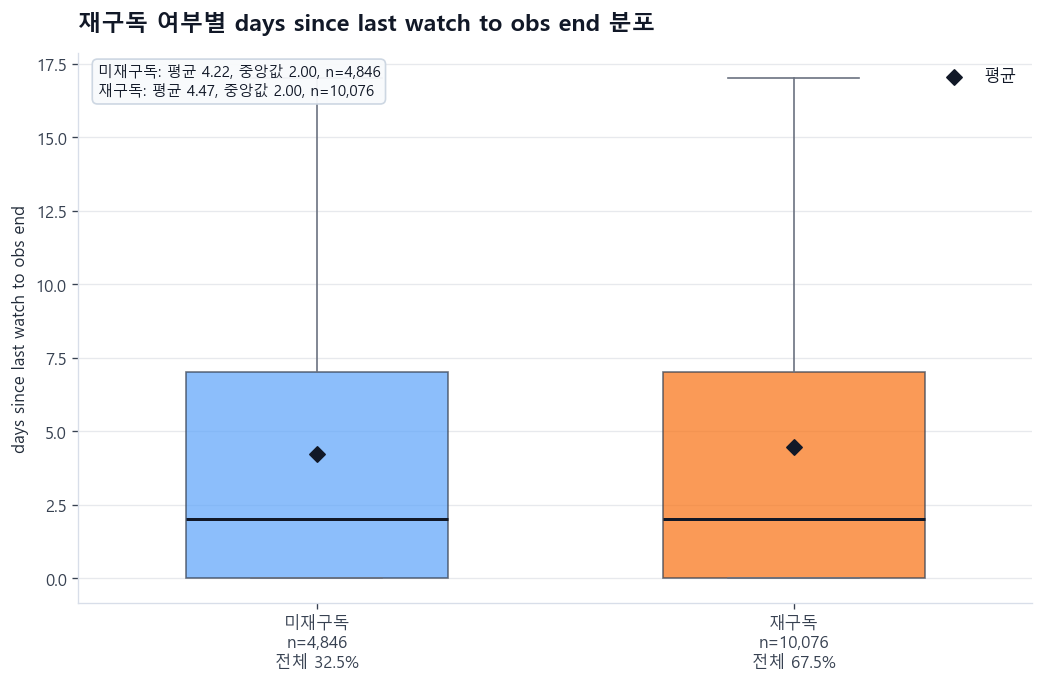

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_metadata_covered_watch_ratio.png


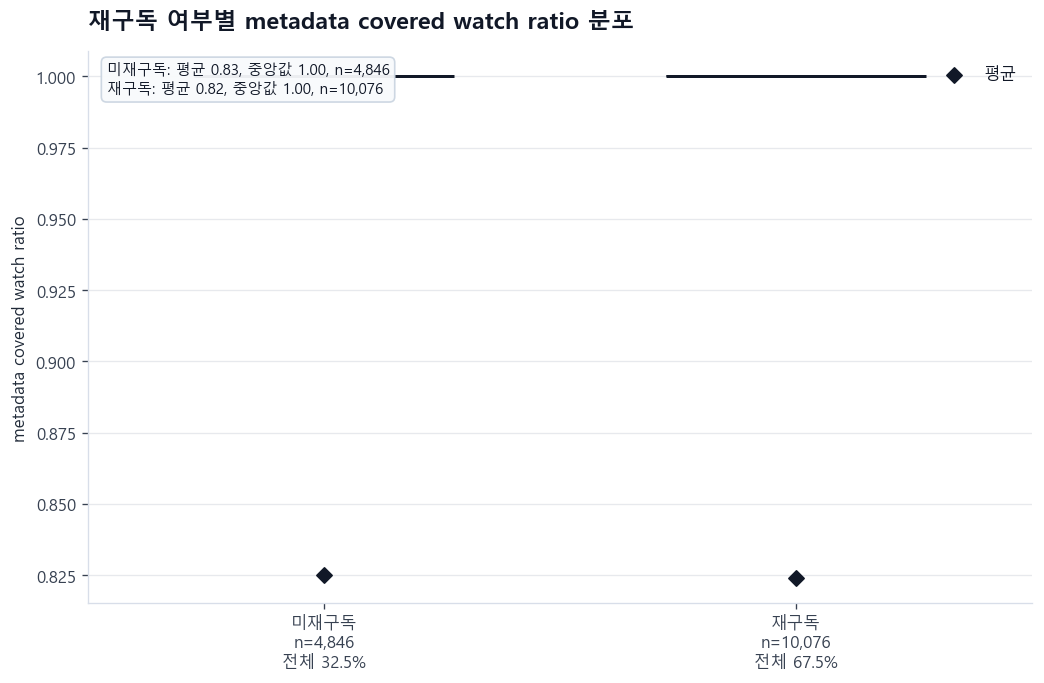

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_metadata_missing_watch_ratio.png


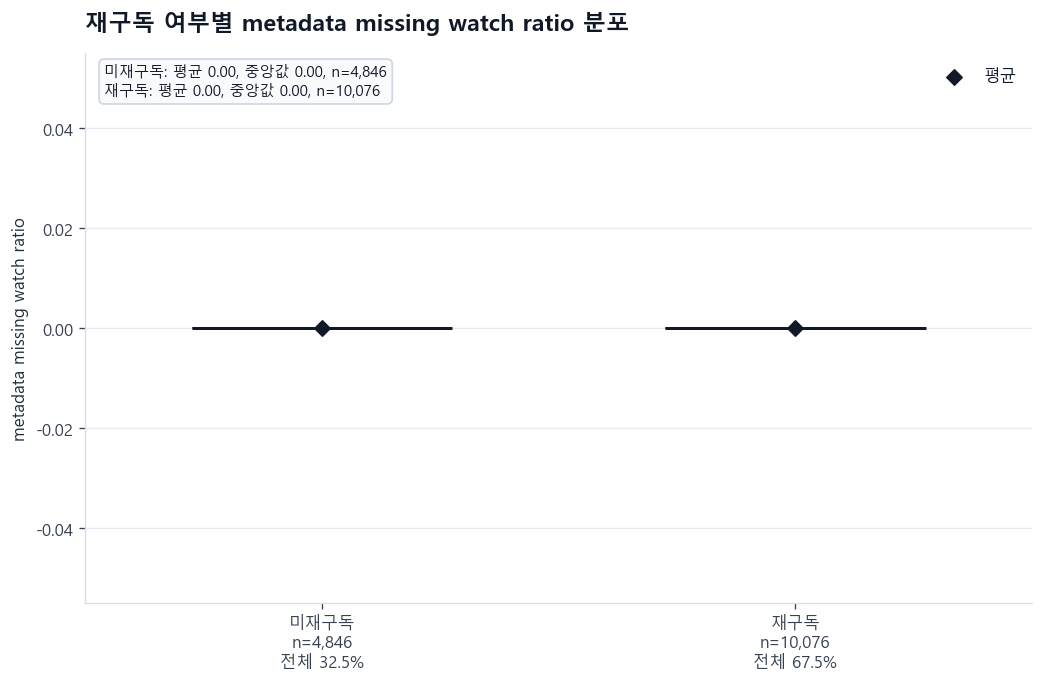

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_tag_ratio_가족.png


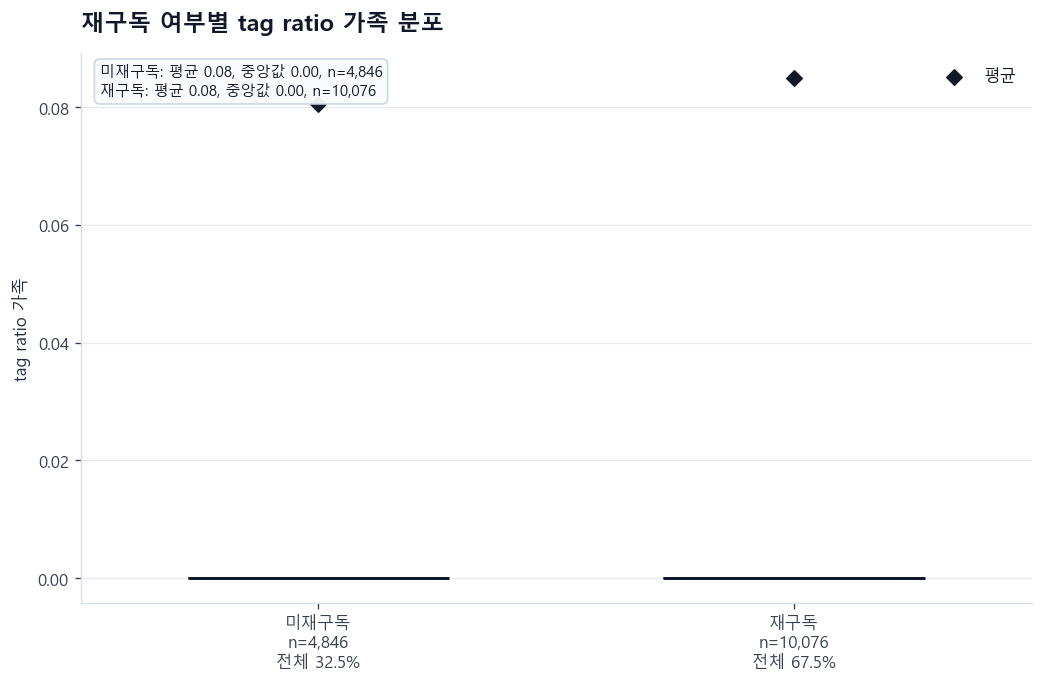

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_tag_ratio_액션.png


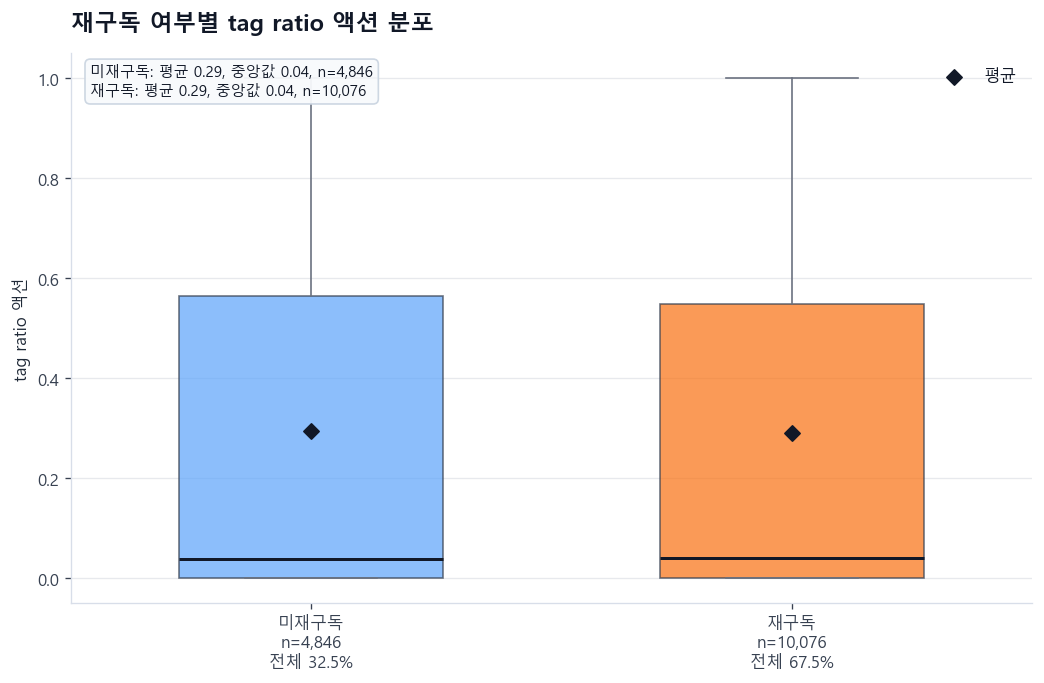

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_tag_ratio_드라마.png


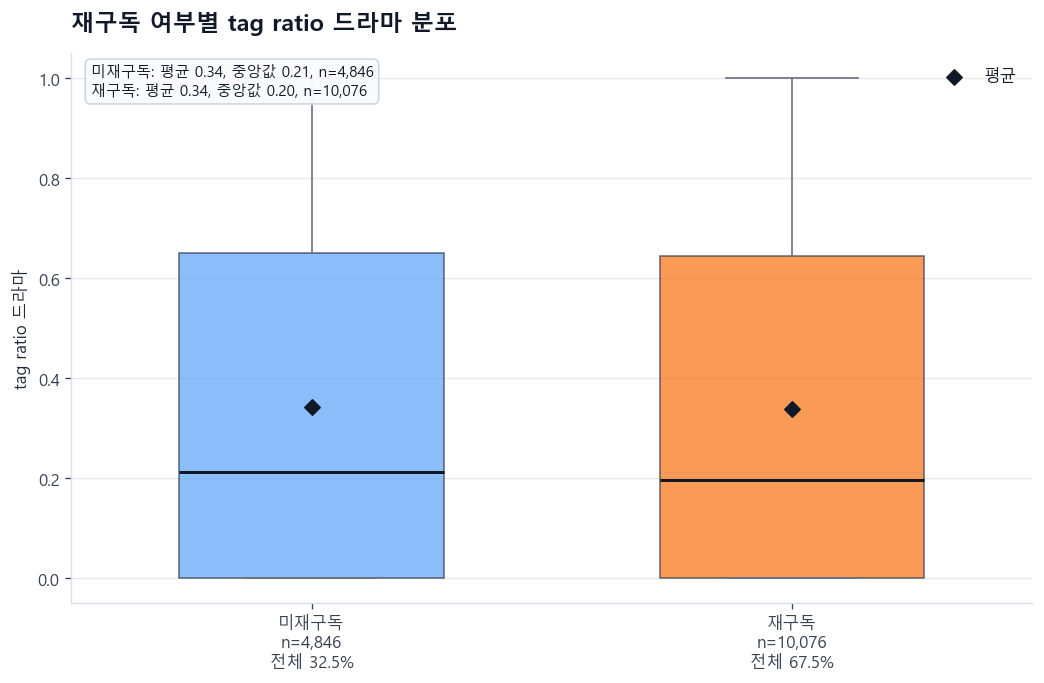

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_rating_ratio_전체.png


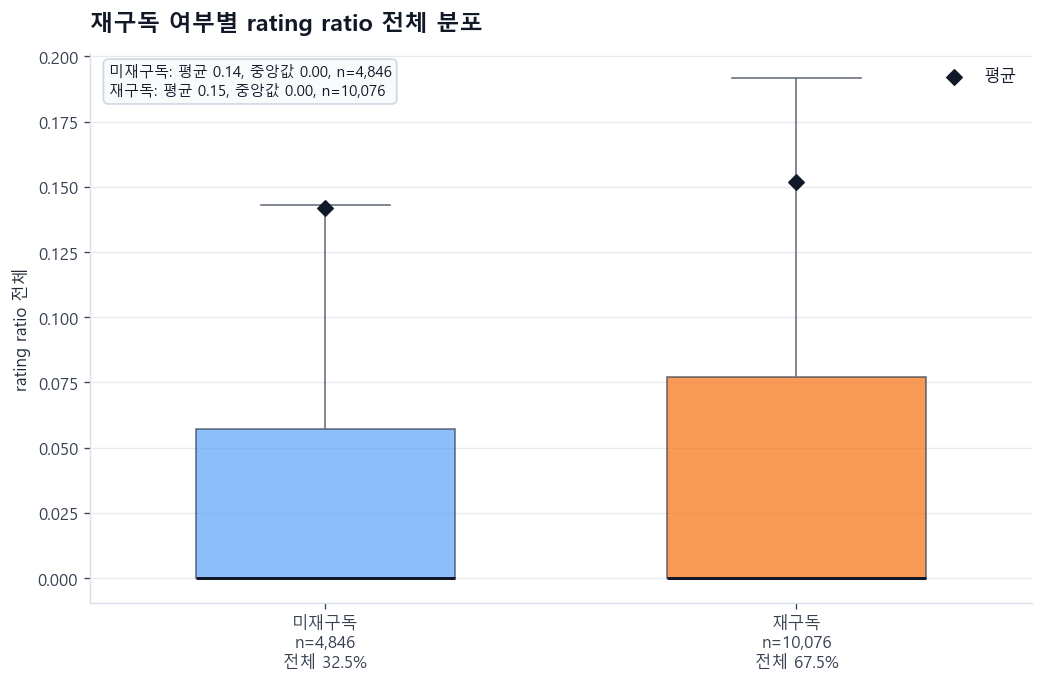

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_rating_ratio_12세.png


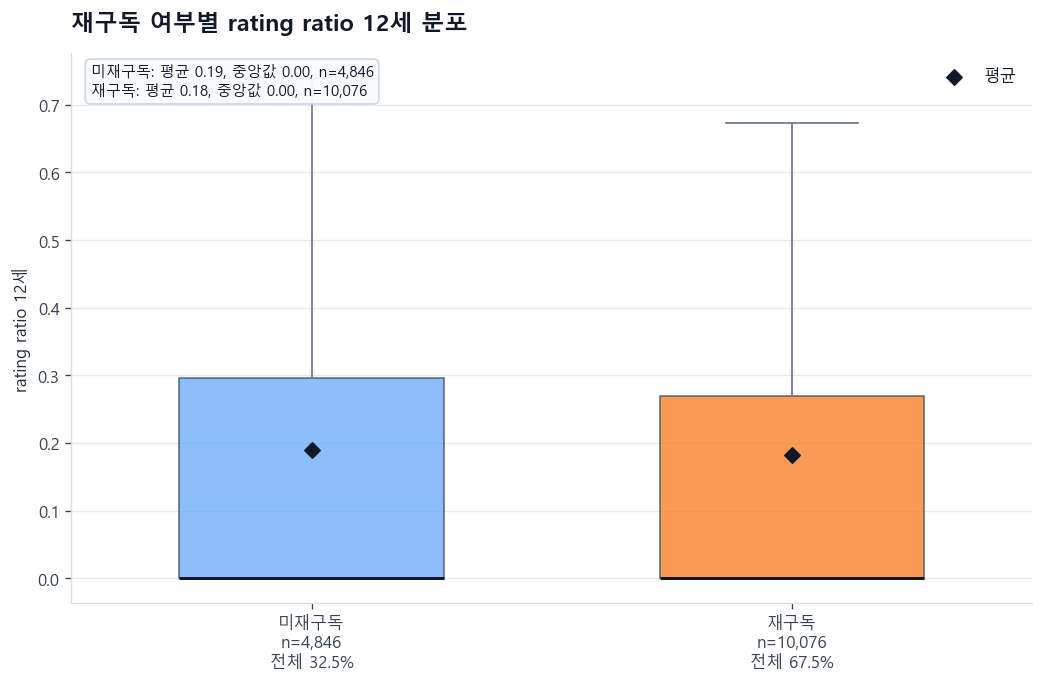

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_rating_ratio_15세.png


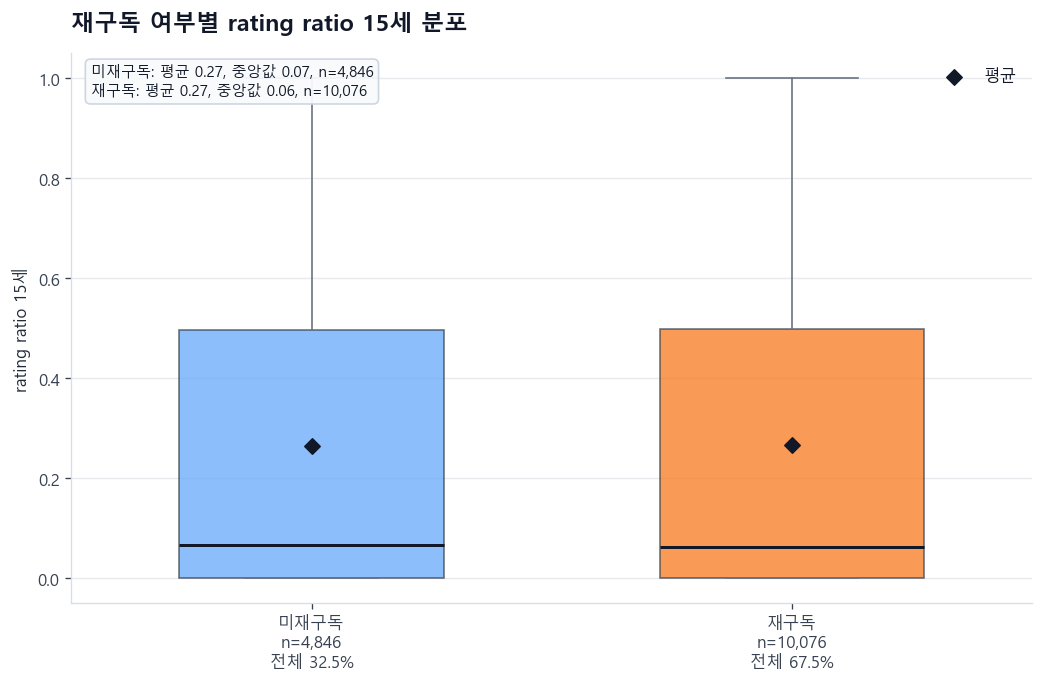

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_rating_ratio_청불.png


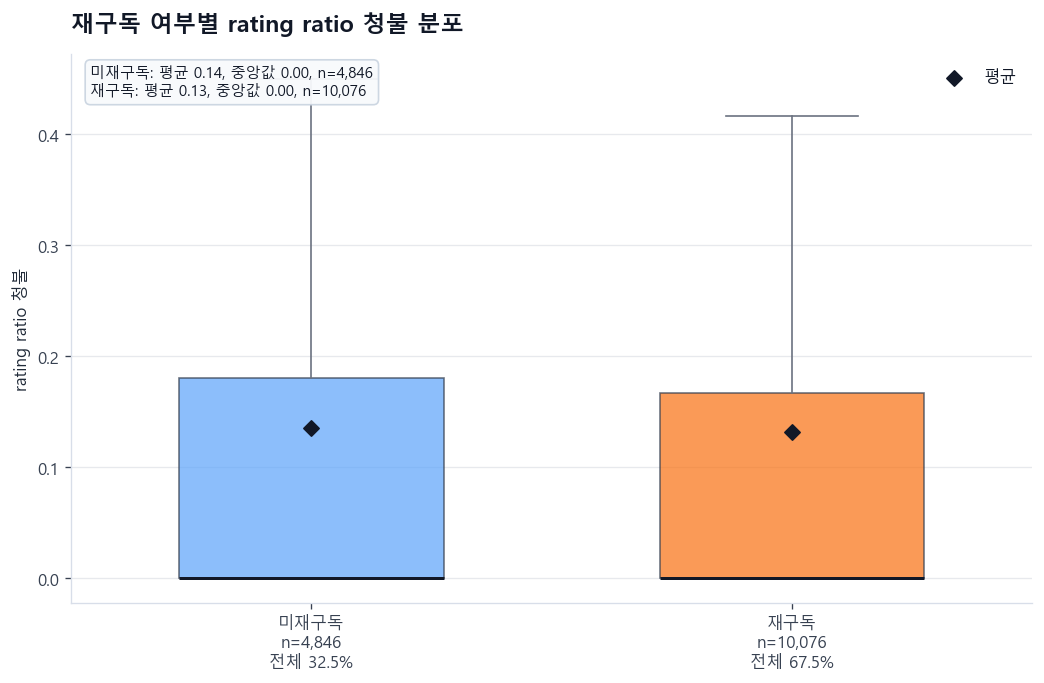

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_is_long_movie_ratio.png


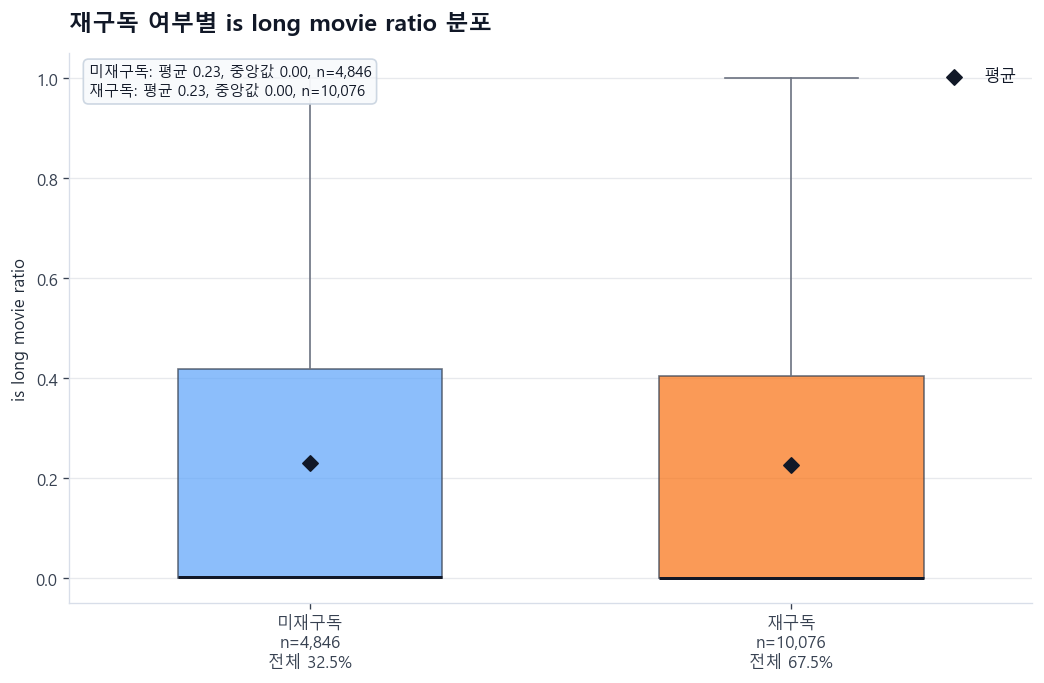

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_is_recent_content_ratio.png


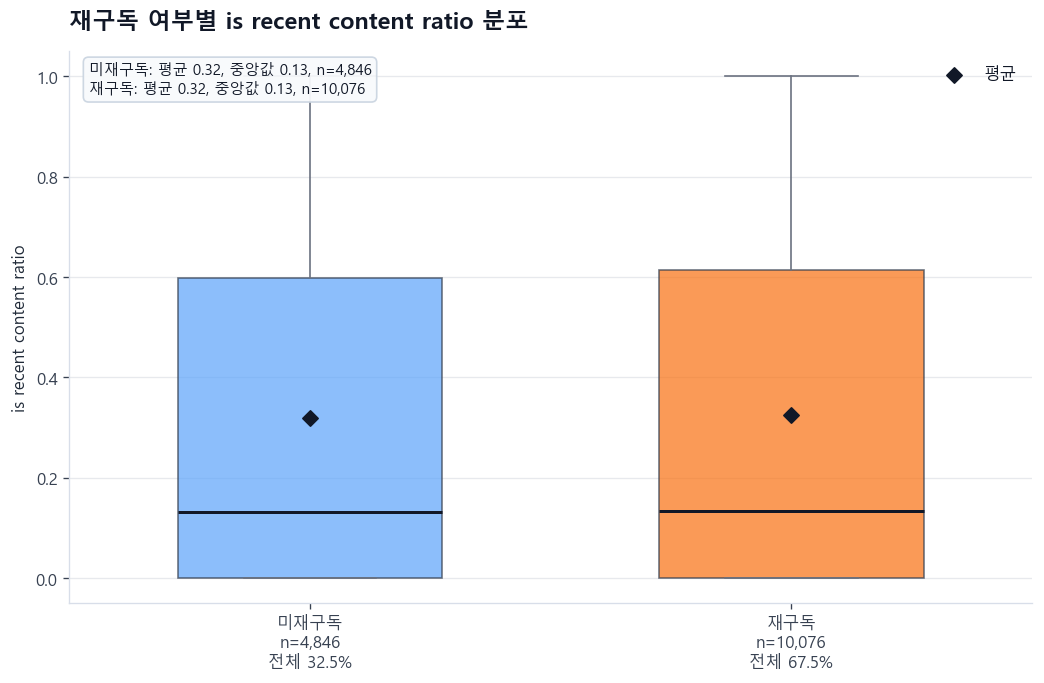

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_avg_runtime_weighted.png


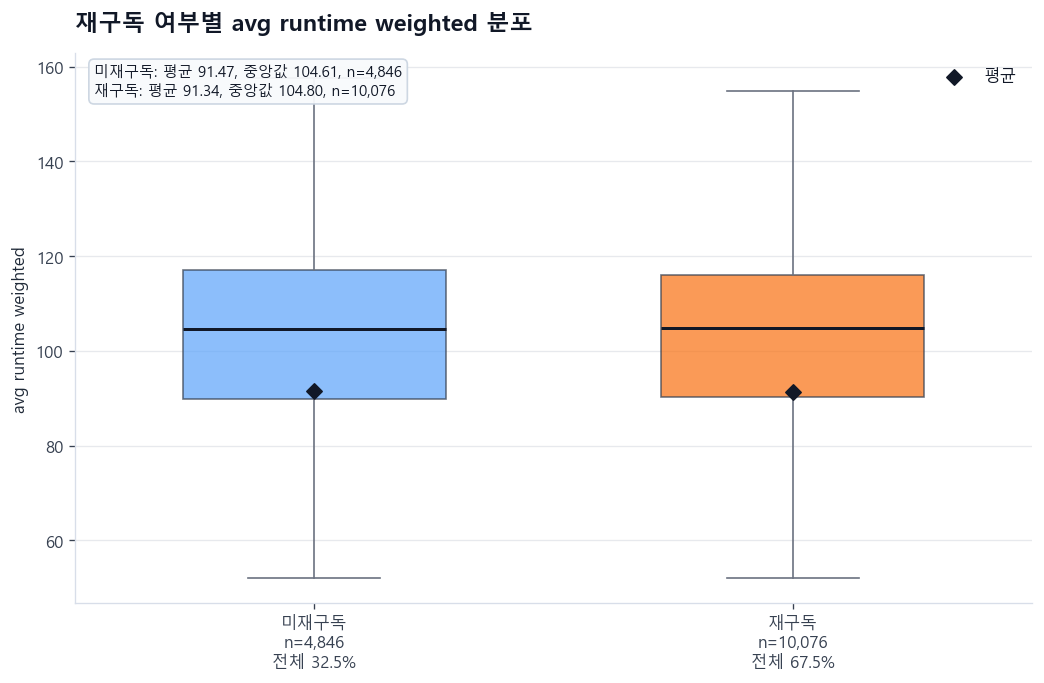

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_genre_tag_entropy_norm.png


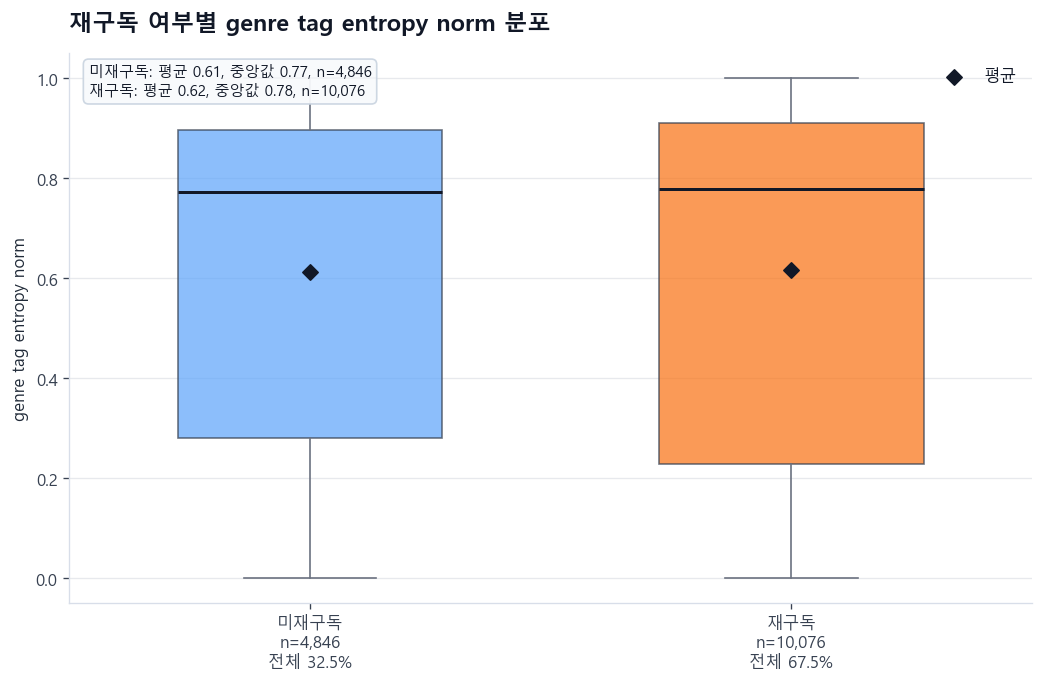

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_box_country_entropy_norm.png


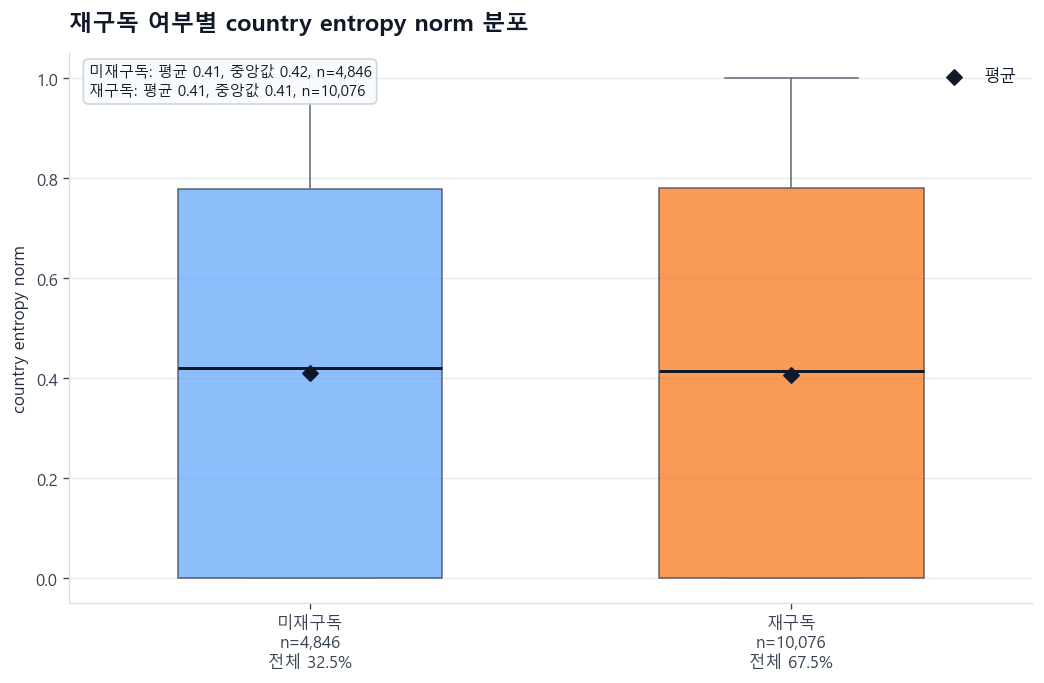

In [50]:
# 6-13. 핵심 numeric distribution plot

if RUN_ALL_FIGURES:
    numeric_plot_features = [
        'age', 'total_watch_time', 'total_sessions', 'unique_contents', 'unique_days',
        'week1_watch_time', 'week2_watch_time', 'week3_watch_time',
        'week1_ratio', 'week2_ratio', 'week3_ratio',
        'w3_minus_w1_watch_time', 'daily_watch_slope',
        'max_day_share', 'days_since_last_watch_to_obs_end',
        'metadata_covered_watch_ratio', 'metadata_missing_watch_ratio',
        'tag_ratio_애니메이션/키즈', 'tag_ratio_가족', 'tag_ratio_액션',
        'tag_ratio_SF/판타지', 'tag_ratio_스릴러/범죄', 'tag_ratio_드라마',
        'rating_ratio_전체', 'rating_ratio_12세', 'rating_ratio_15세', 'rating_ratio_청불',
        'is_long_movie_ratio', 'is_recent_content_ratio', 'avg_runtime_weighted',
        'genre_tag_entropy_norm', 'country_entropy_norm',
    ]
    for col in numeric_plot_features:
        if col in df.columns:
            safe_name = col.replace('/', '_').replace(' ', '_')
            plot_numeric_by_target(df, col, f'{col} by repurchase', f'06_box_{safe_name}.png')

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_100won_rate_by_max_screen.png


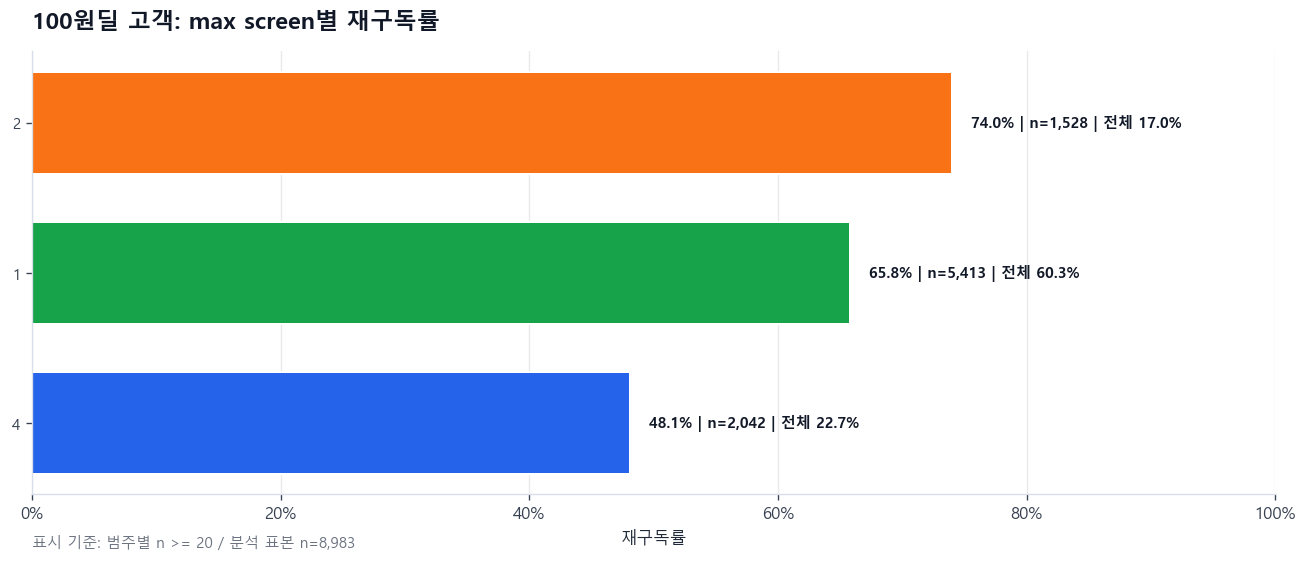

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_100won_rate_by_screen_1_flag.png


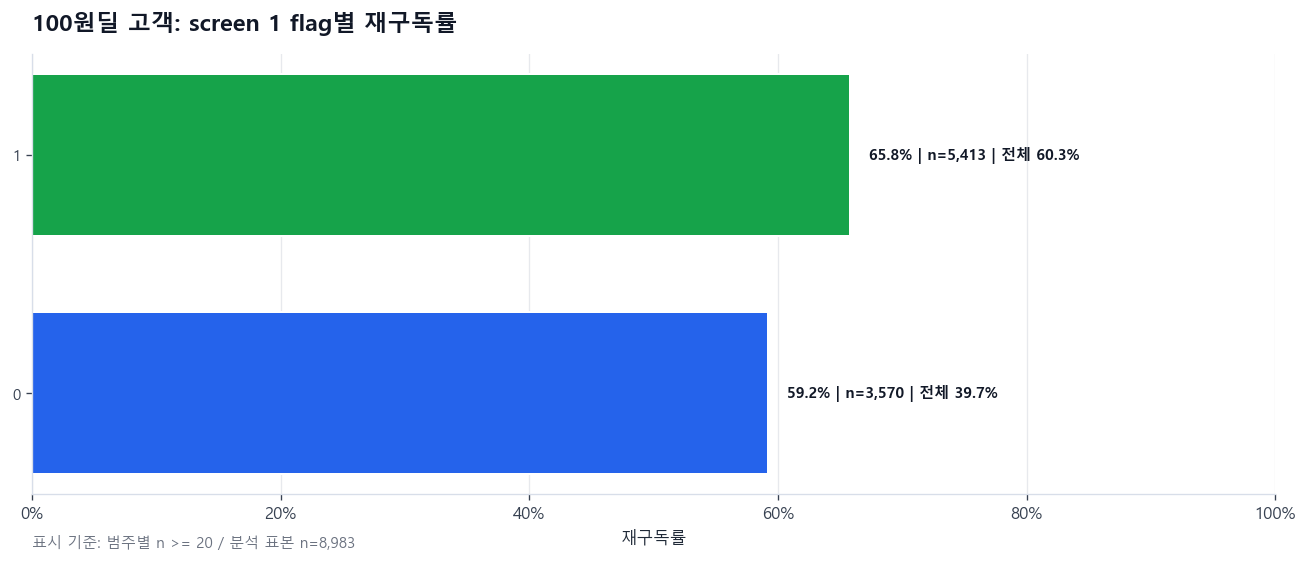

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_100won_rate_by_screen_2_flag.png


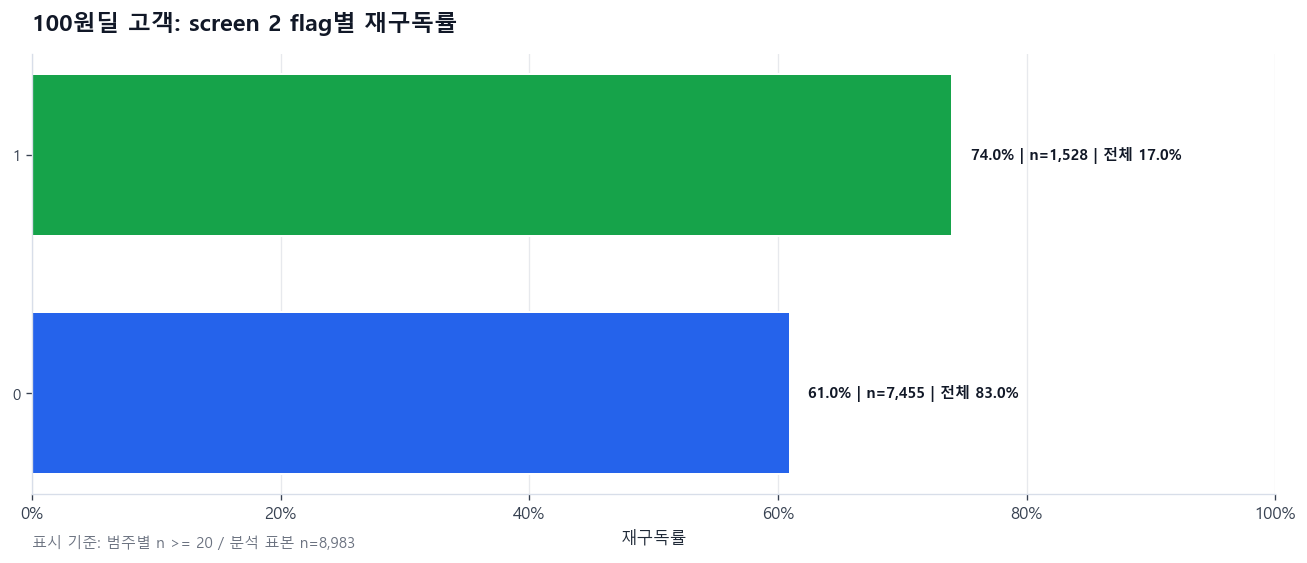

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_100won_rate_by_screen_4_flag.png


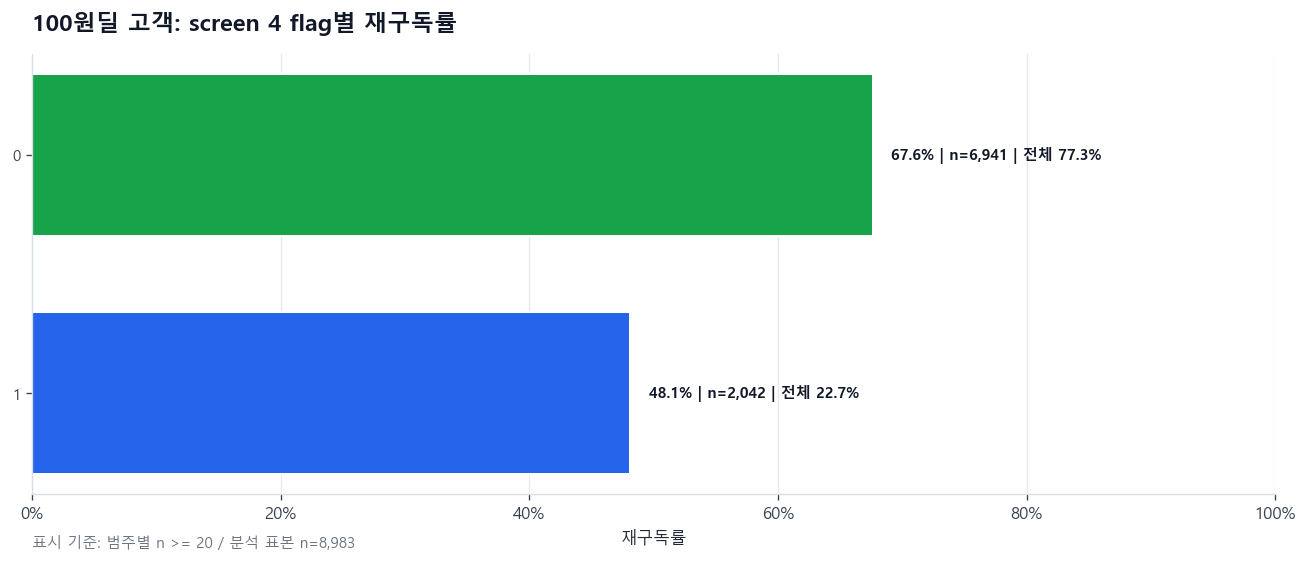

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_100won_rate_by_is_churn_prevented.png


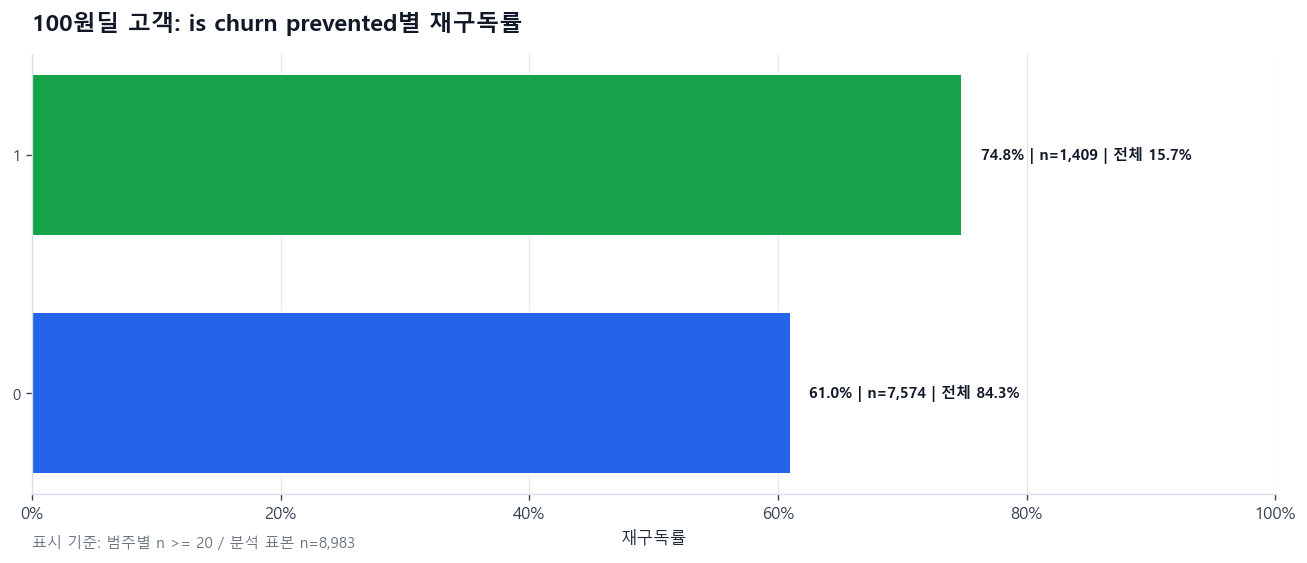

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_100won_box_week1_ratio.png


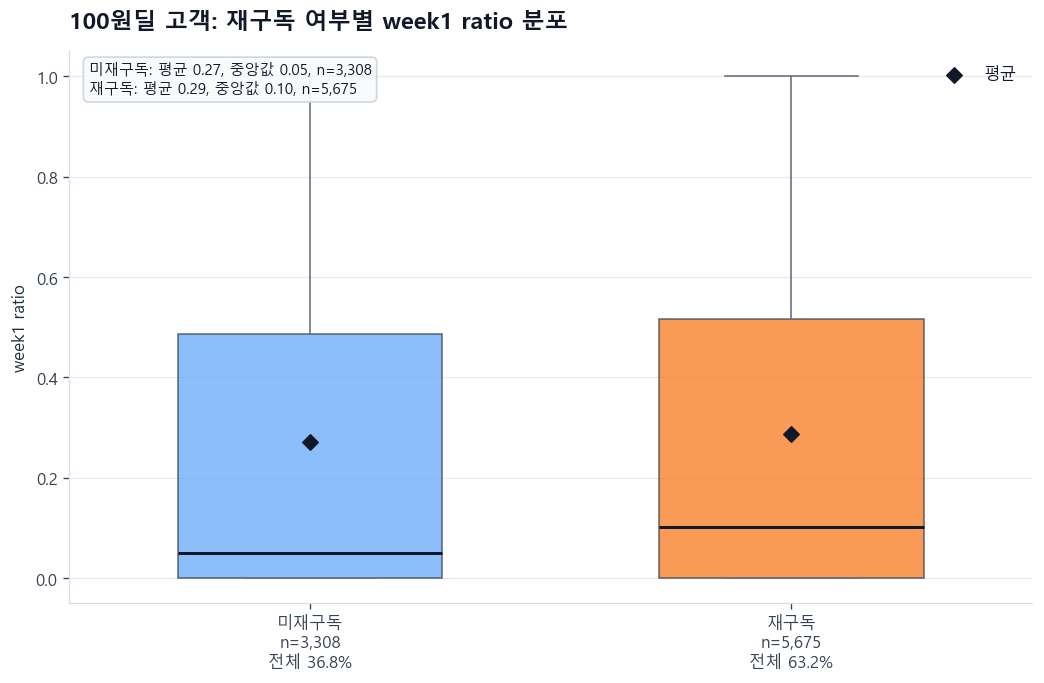

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_100won_box_week3_ratio.png


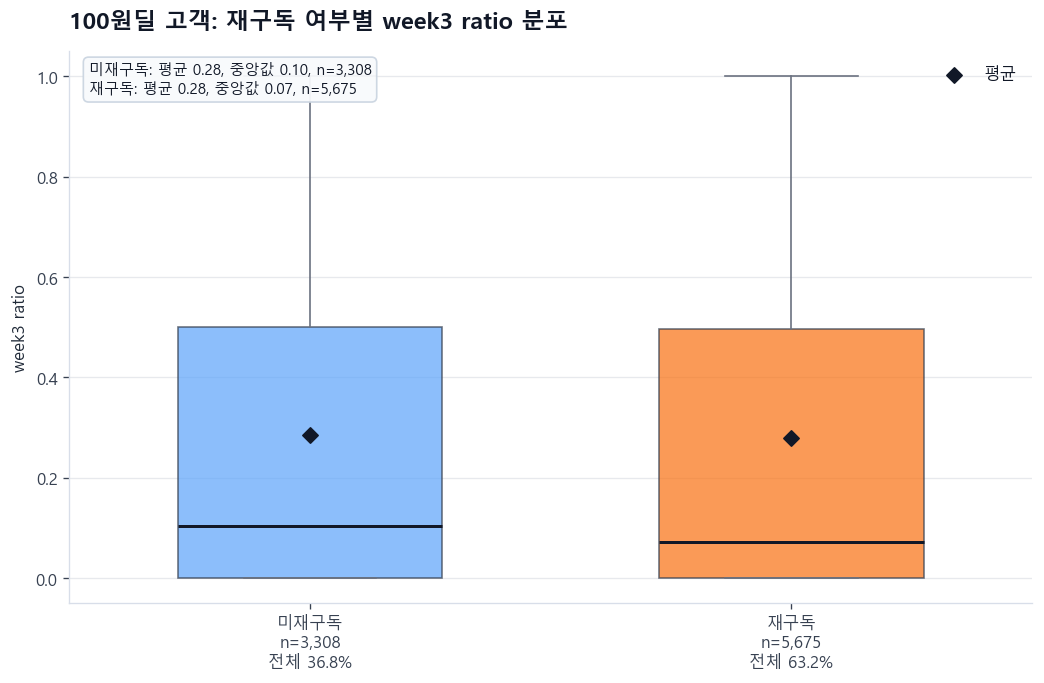

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_100won_box_w3_minus_w1_watch_time.png


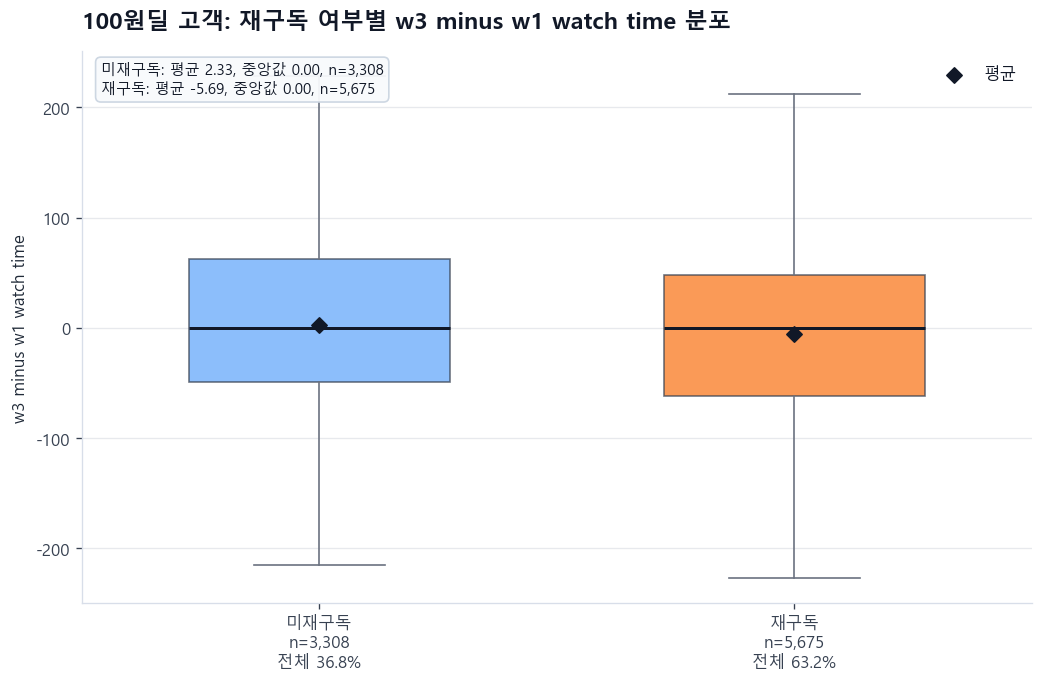

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_100won_box_daily_watch_slope.png


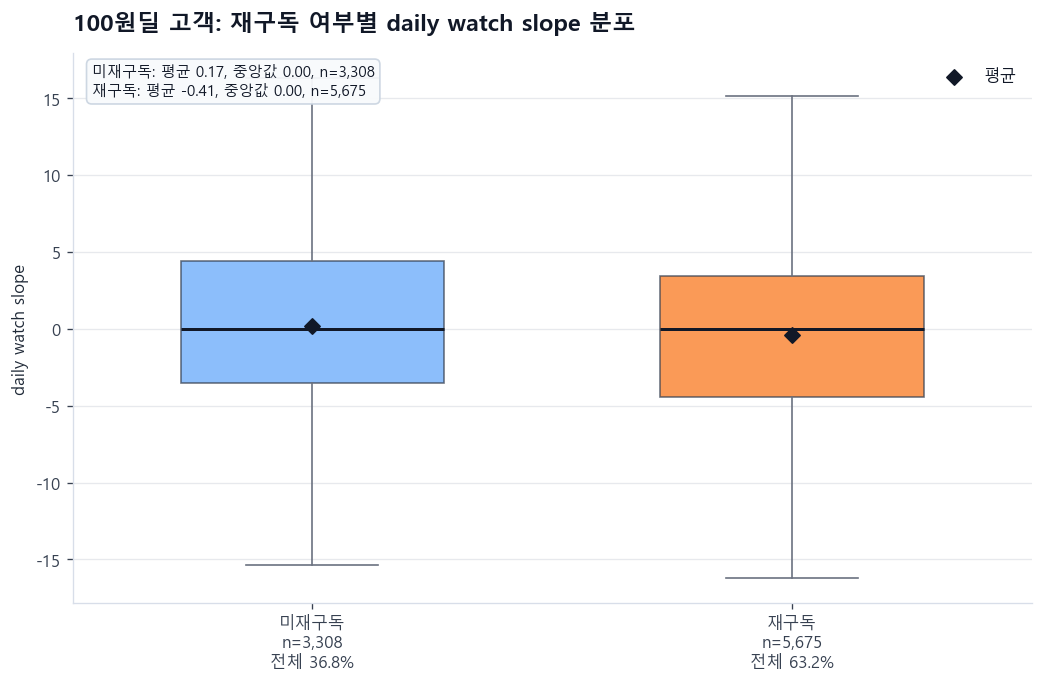

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_100won_box_total_watch_time.png


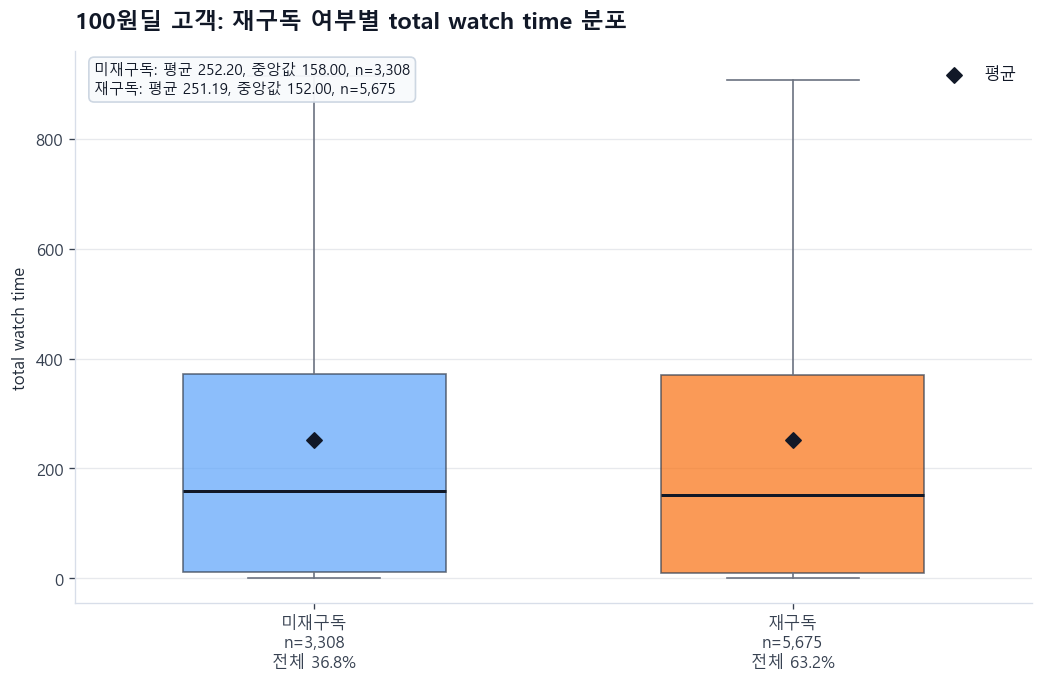

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_promo2_rate_by_family_content_affinity.png


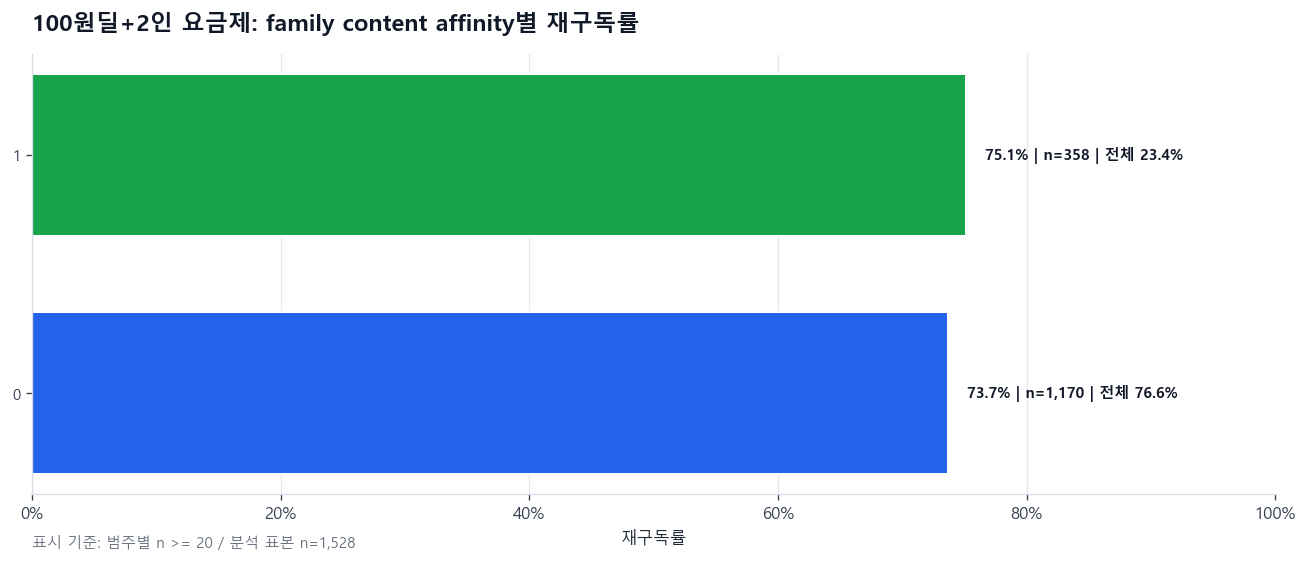

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_promo2_rate_by_family_2screen_lifestyle.png


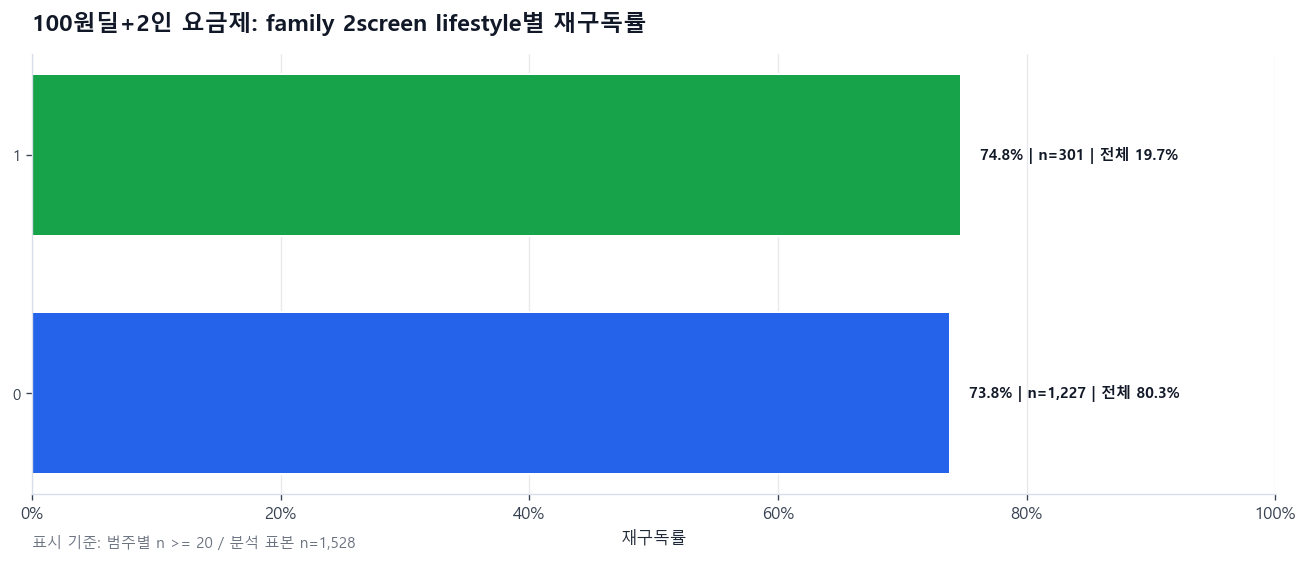

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_promo2_box_rating_ratio_전체.png


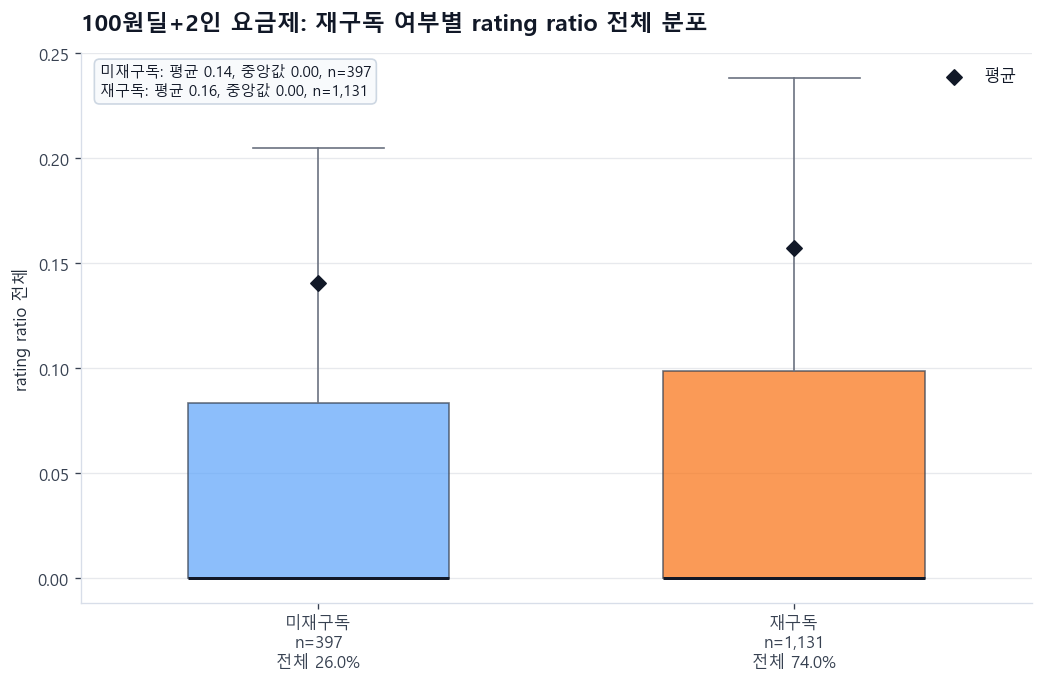

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_promo4_rate_by_premium_action_trial_risk.png


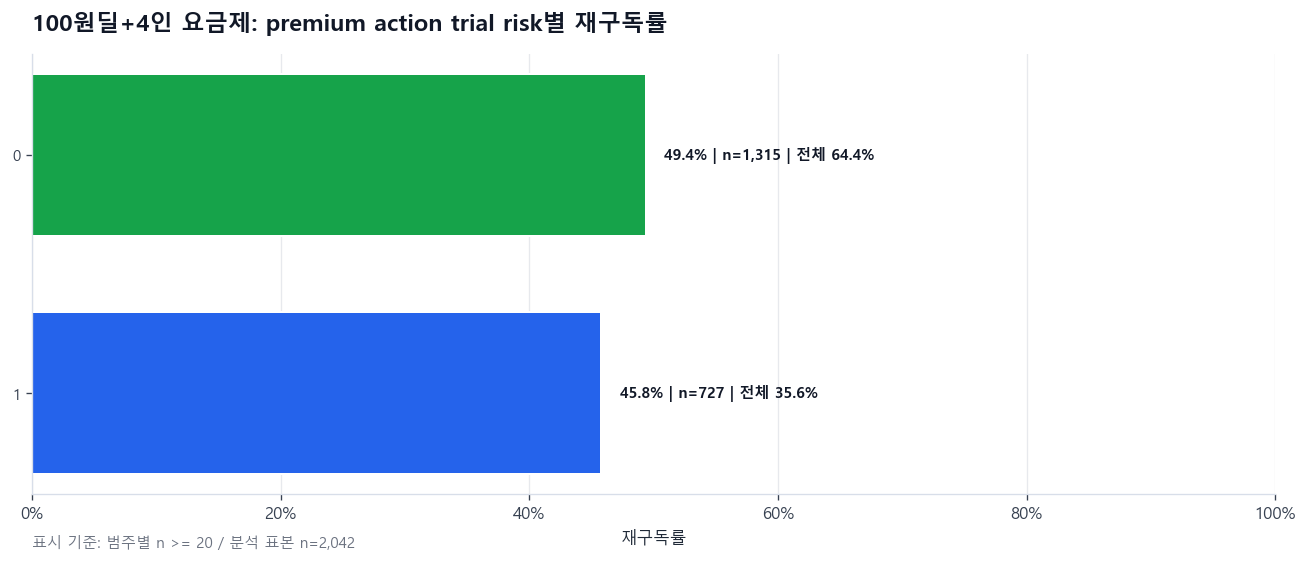

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_promo4_box_tag_ratio_액션.png


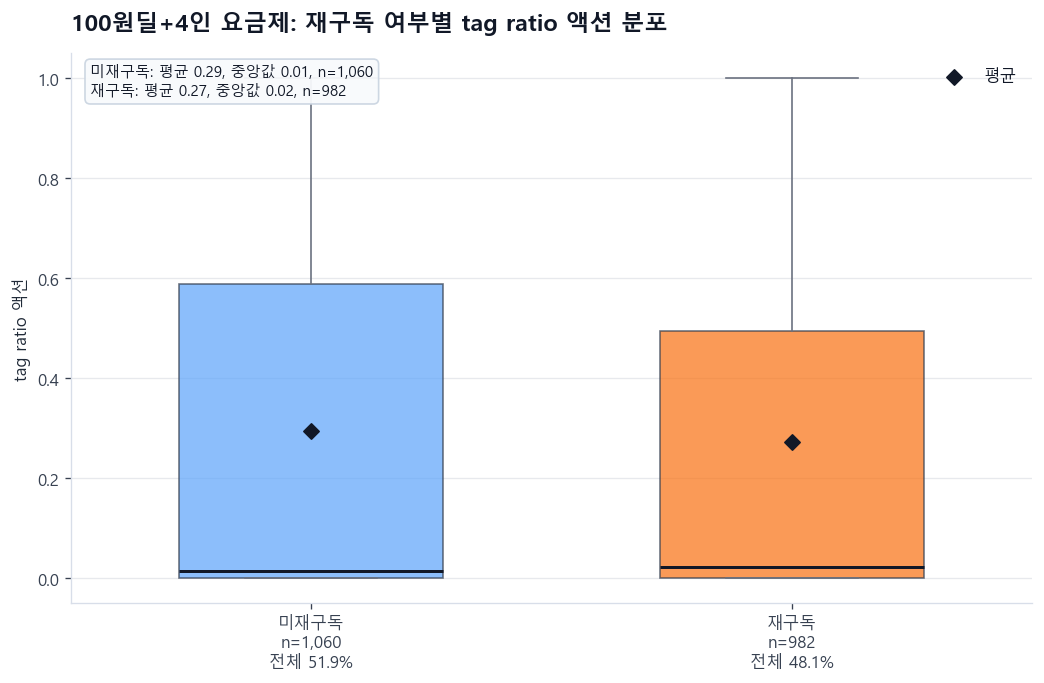

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_promo4_box_is_long_movie_ratio.png


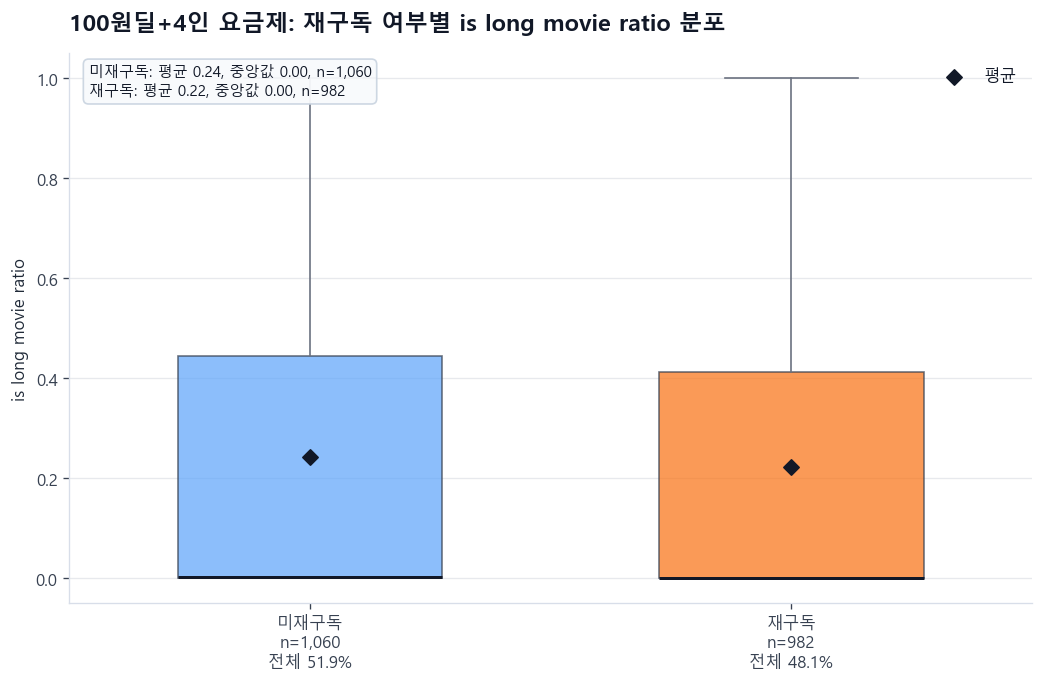

In [51]:
# 6-14. 세그먼트 내부 핵심 시각화

if RUN_CORE_FIGURES and 'is_100won' in df.columns:
    mask_100won = safe_mask(df['is_100won'], 1)
    for col in ['max_screen', 'screen_1_flag', 'screen_2_flag', 'screen_4_flag', 'is_churn_prevented']:
        if col in df.columns:
            plot_rate_by_category(df, col, f'100won only: repurchase rate by {col}', f'06_100won_rate_by_{col}.png', group_filter=mask_100won)

    for col in ['week1_ratio', 'week3_ratio', 'w3_minus_w1_watch_time', 'daily_watch_slope', 'total_watch_time']:
        if col in df.columns:
            plot_numeric_by_target(df, col, f'100won only: {col} by repurchase', f'06_100won_box_{col}.png', group_filter=mask_100won)

if RUN_ALL_FIGURES and {'is_100won', 'max_screen'}.issubset(df.columns):
    mask_promo2 = safe_mask(df['is_100won'], 1) & (pd.to_numeric(df['max_screen'], errors='coerce') == 2)
    mask_promo4 = safe_mask(df['is_100won'], 1) & (pd.to_numeric(df['max_screen'], errors='coerce') == 4)

    for col in ['family_content_affinity', 'family_2screen_lifestyle', 'tag_ratio_애니메이션/키즈', 'rating_ratio_전체']:
        if col in df.columns:
            if infer_feature_type(df[col]) == 'binary':
                plot_rate_by_category(df, col, f'100won+2screen: repurchase by {col}', f'06_promo2_rate_by_{col}.png', group_filter=mask_promo2)
            else:
                plot_numeric_by_target(df, col, f'100won+2screen: {col} by repurchase', f'06_promo2_box_{col.replace("/", "_")}.png', group_filter=mask_promo2)

    for col in ['premium_action_content_affinity', 'premium_action_trial_risk', 'tag_ratio_액션', 'tag_ratio_SF/판타지', 'is_long_movie_ratio']:
        if col in df.columns:
            if infer_feature_type(df[col]) == 'binary':
                plot_rate_by_category(df, col, f'100won+4screen: repurchase by {col}', f'06_promo4_rate_by_{col}.png', group_filter=mask_promo4)
            else:
                plot_numeric_by_target(df, col, f'100won+4screen: {col} by repurchase', f'06_promo4_box_{col.replace("/", "_")}.png', group_filter=mask_promo4)

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_top_fdr_all.png


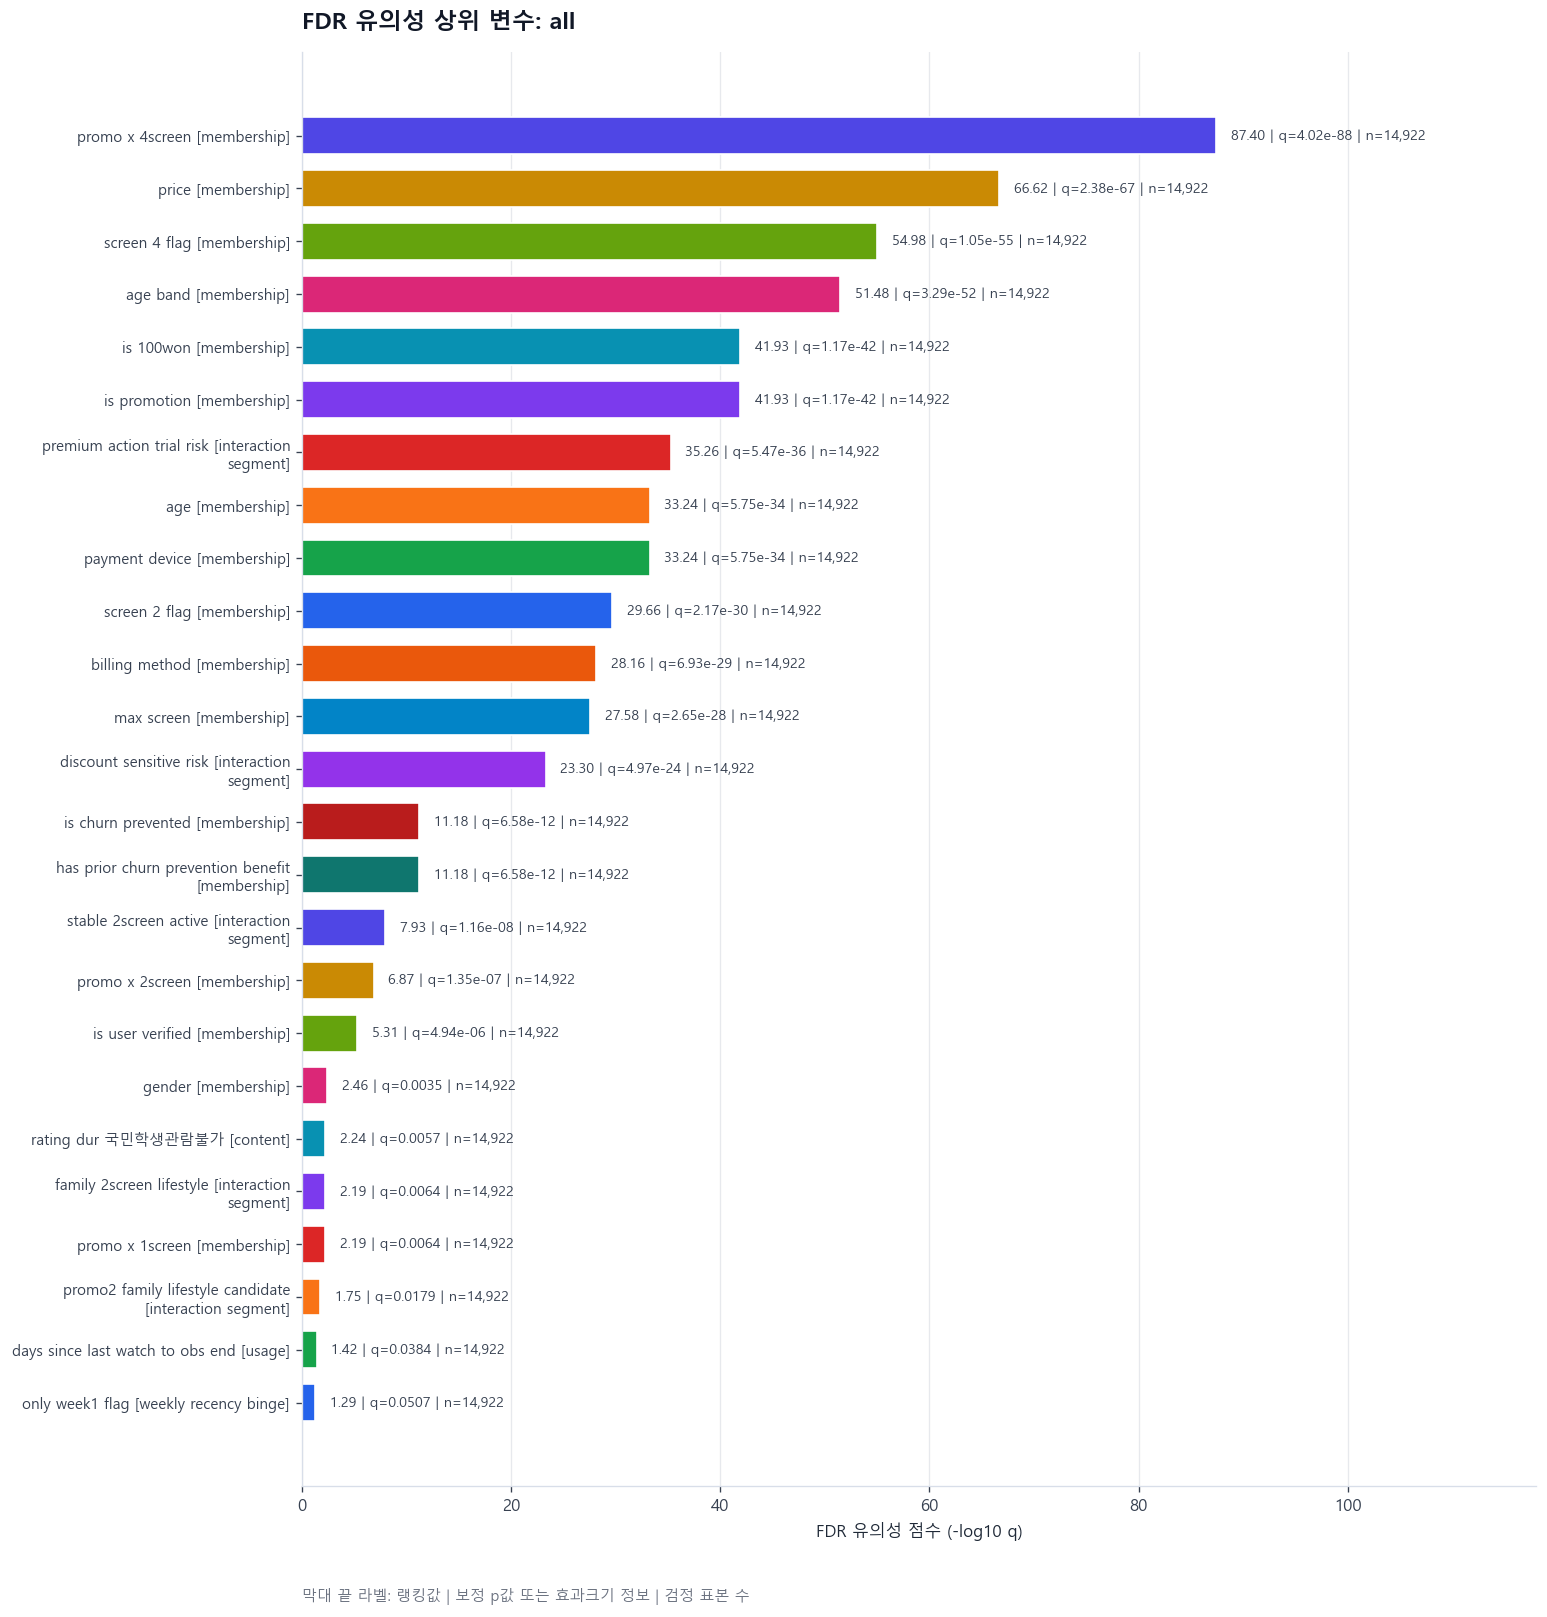

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_top_effect_all.png


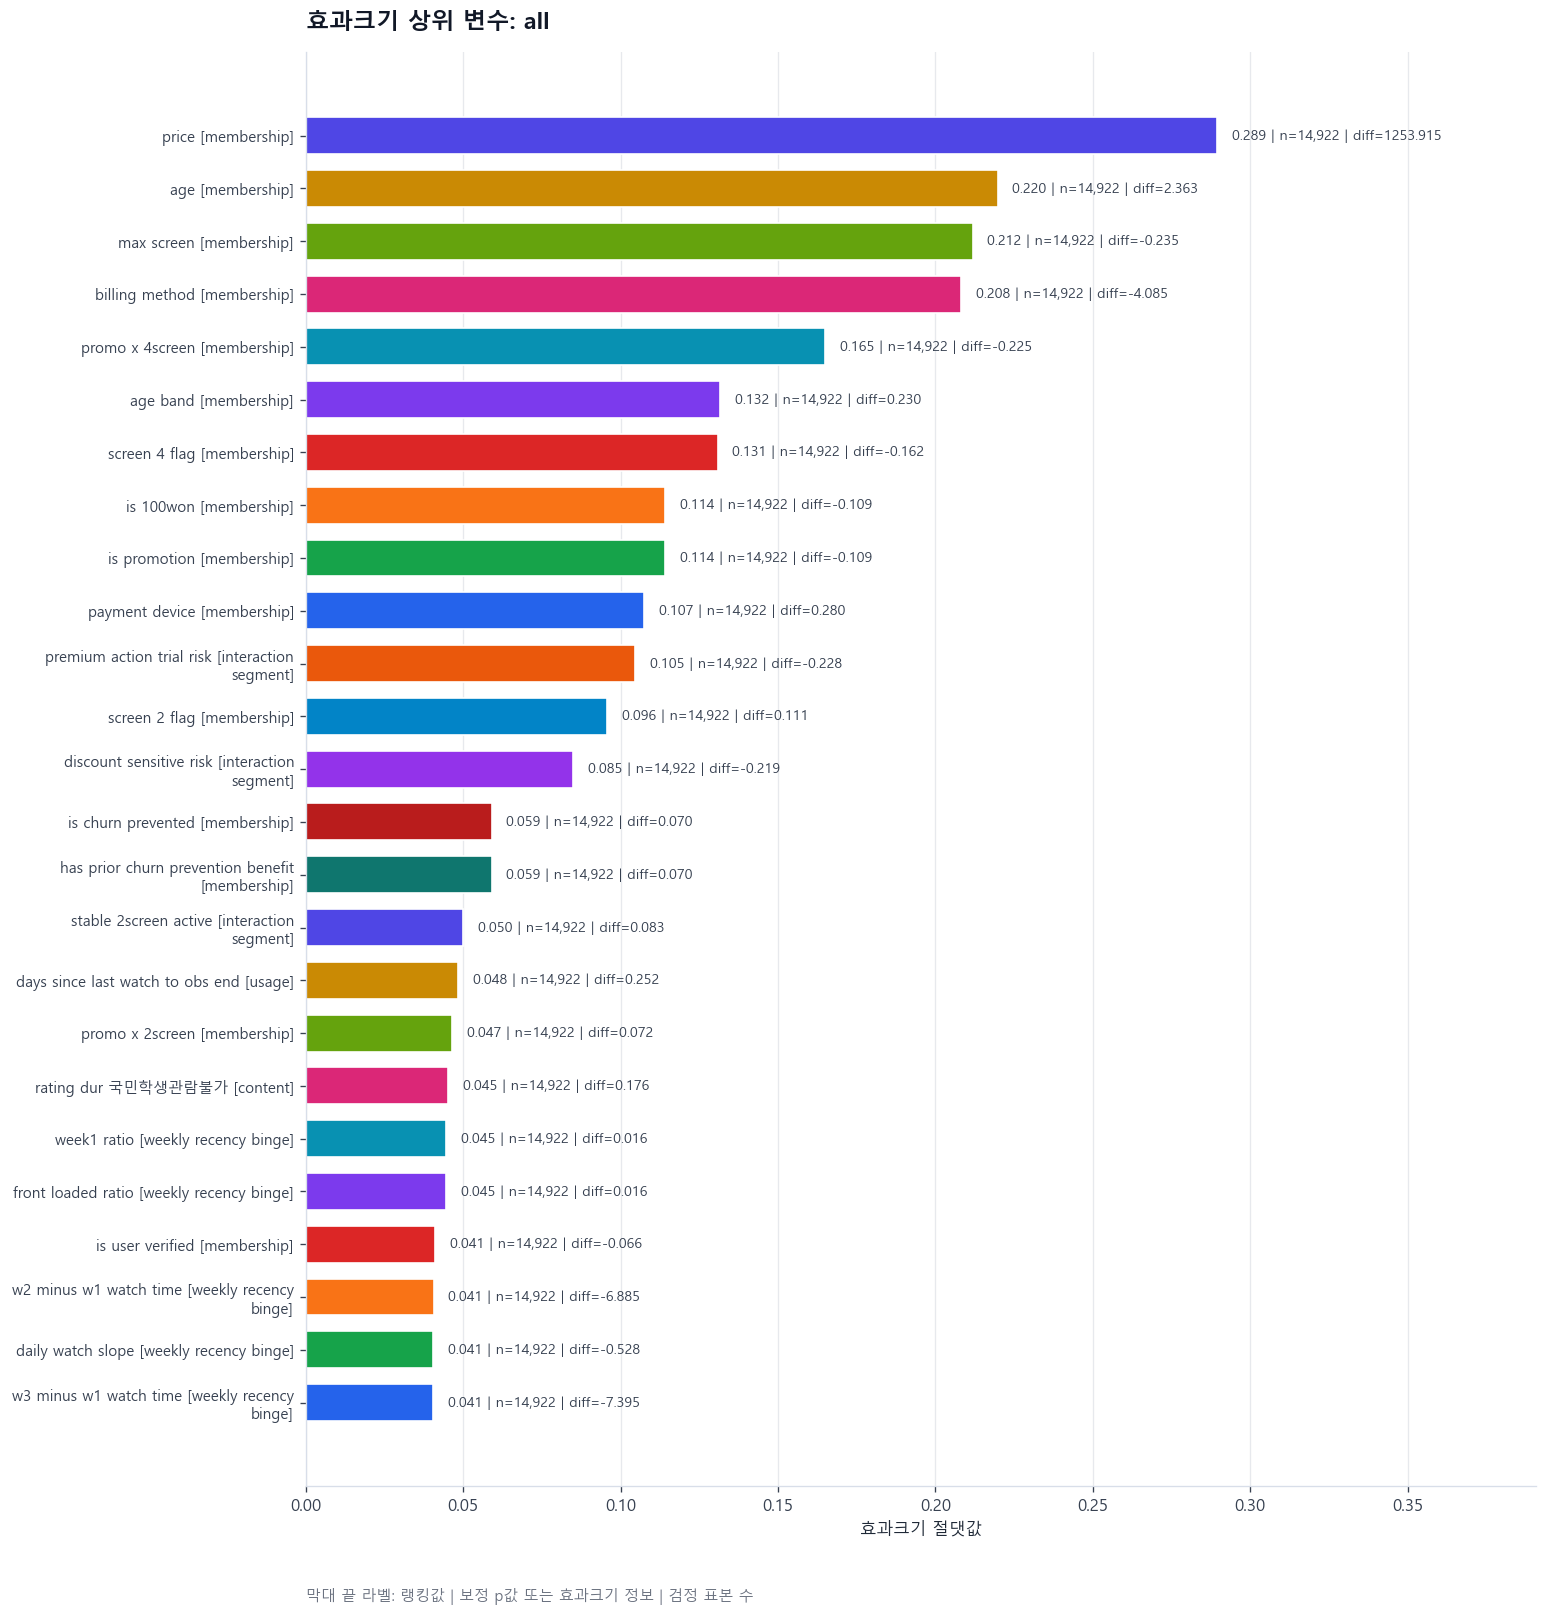

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_top_fdr_100won.png


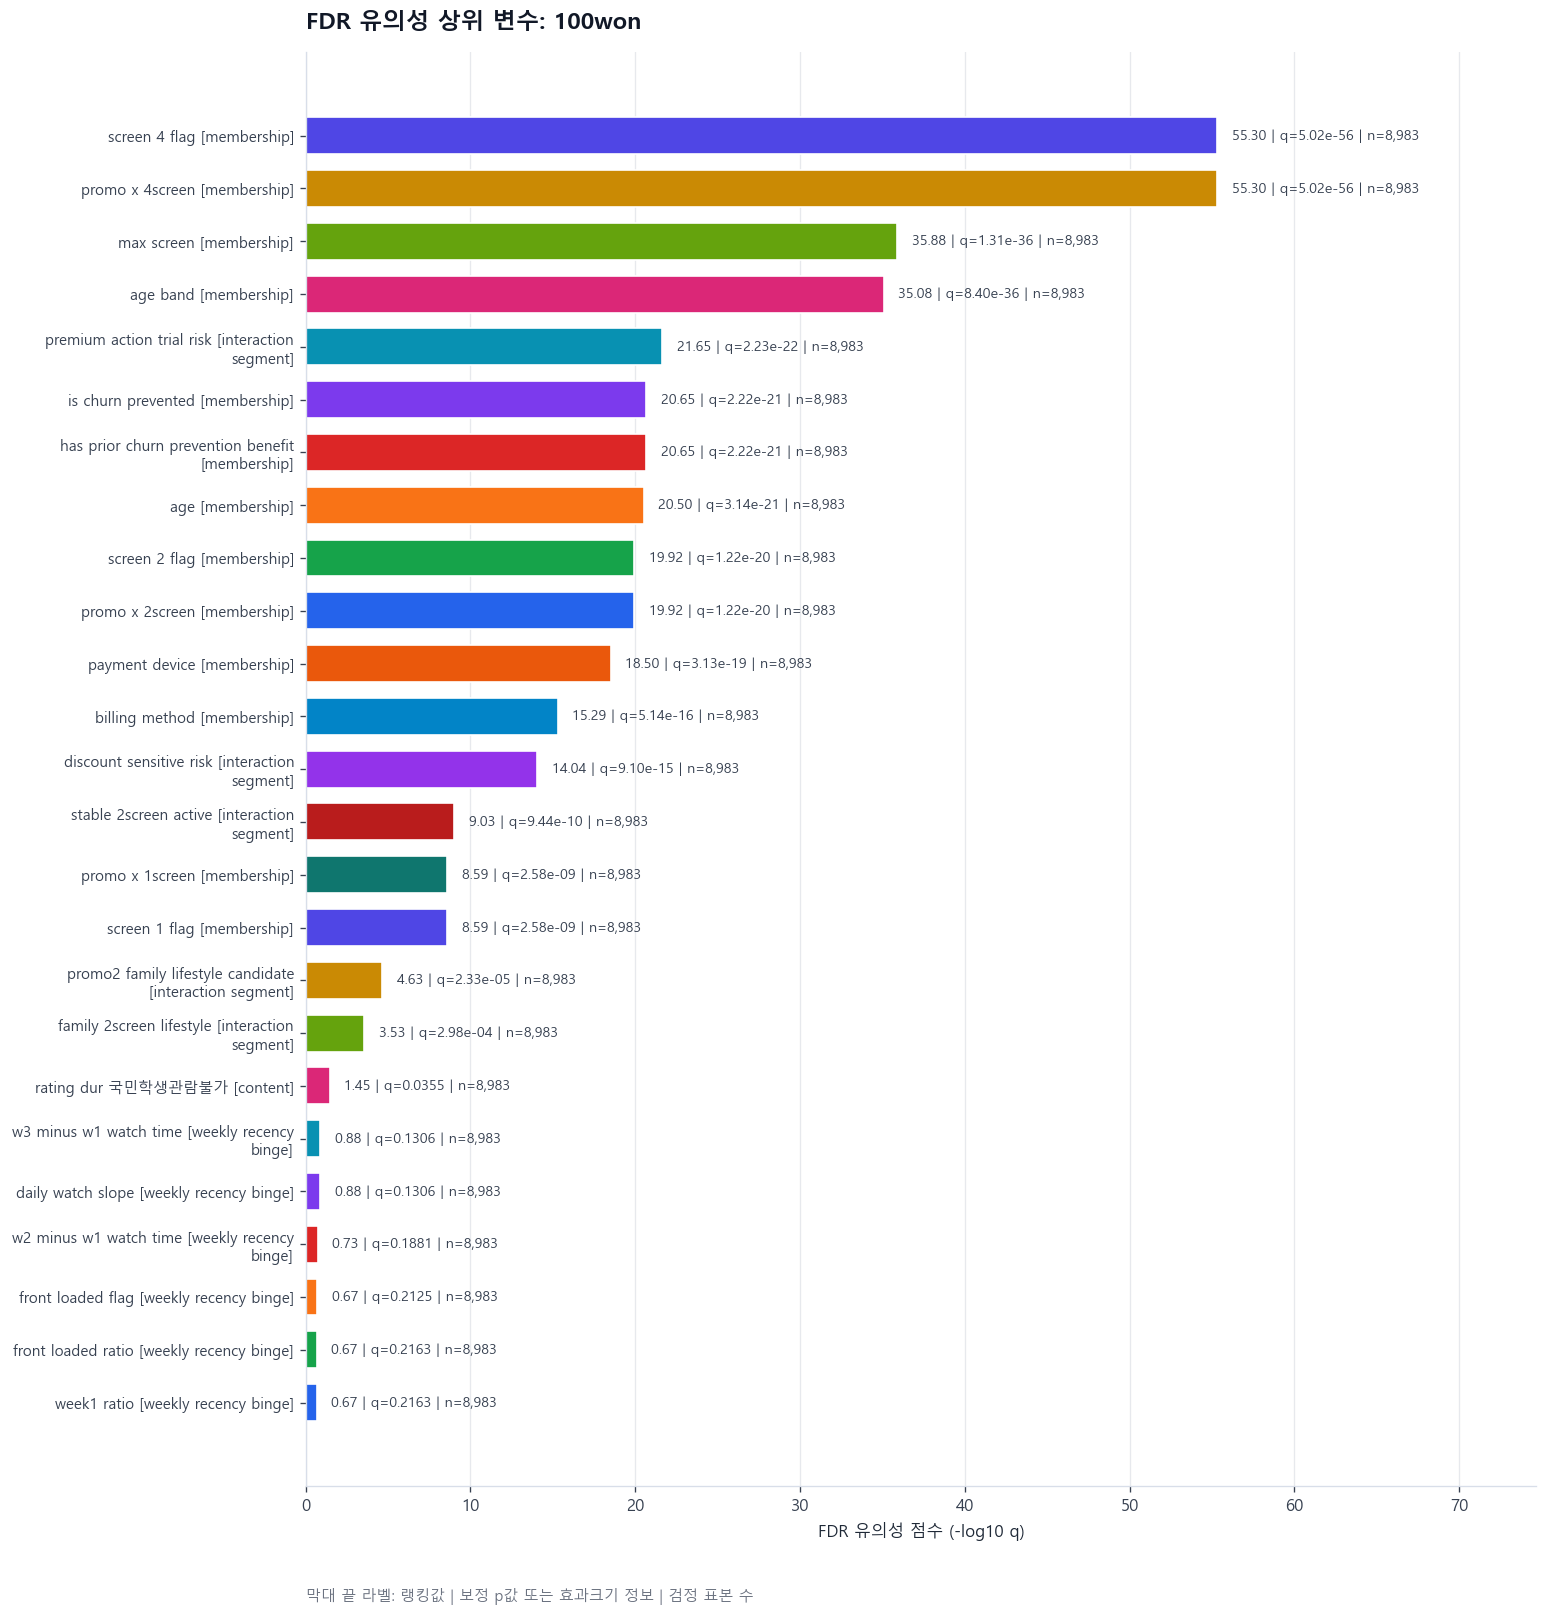

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_top_effect_100won.png


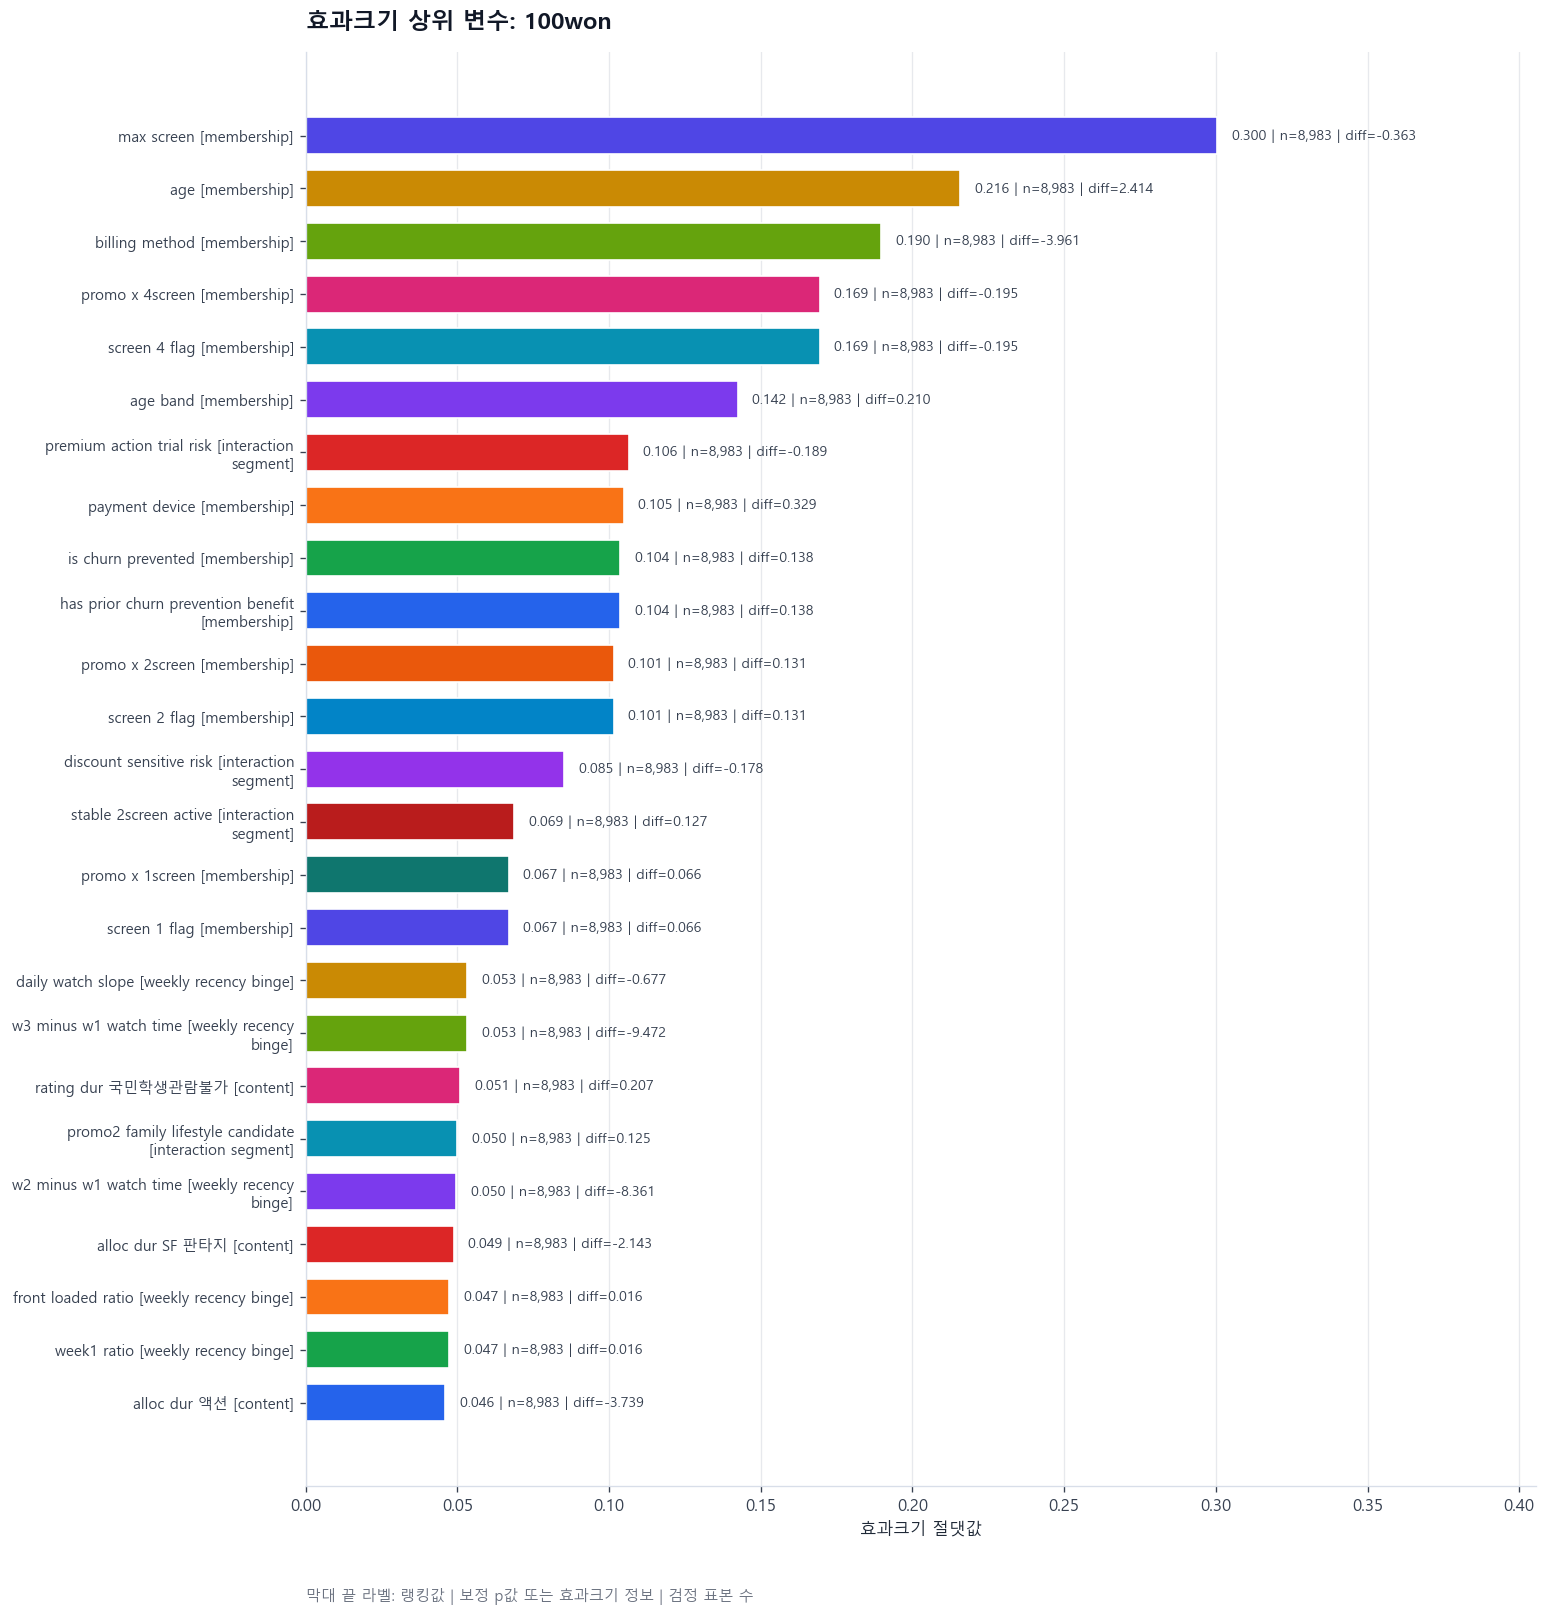

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_top_fdr_100won_screen2.png


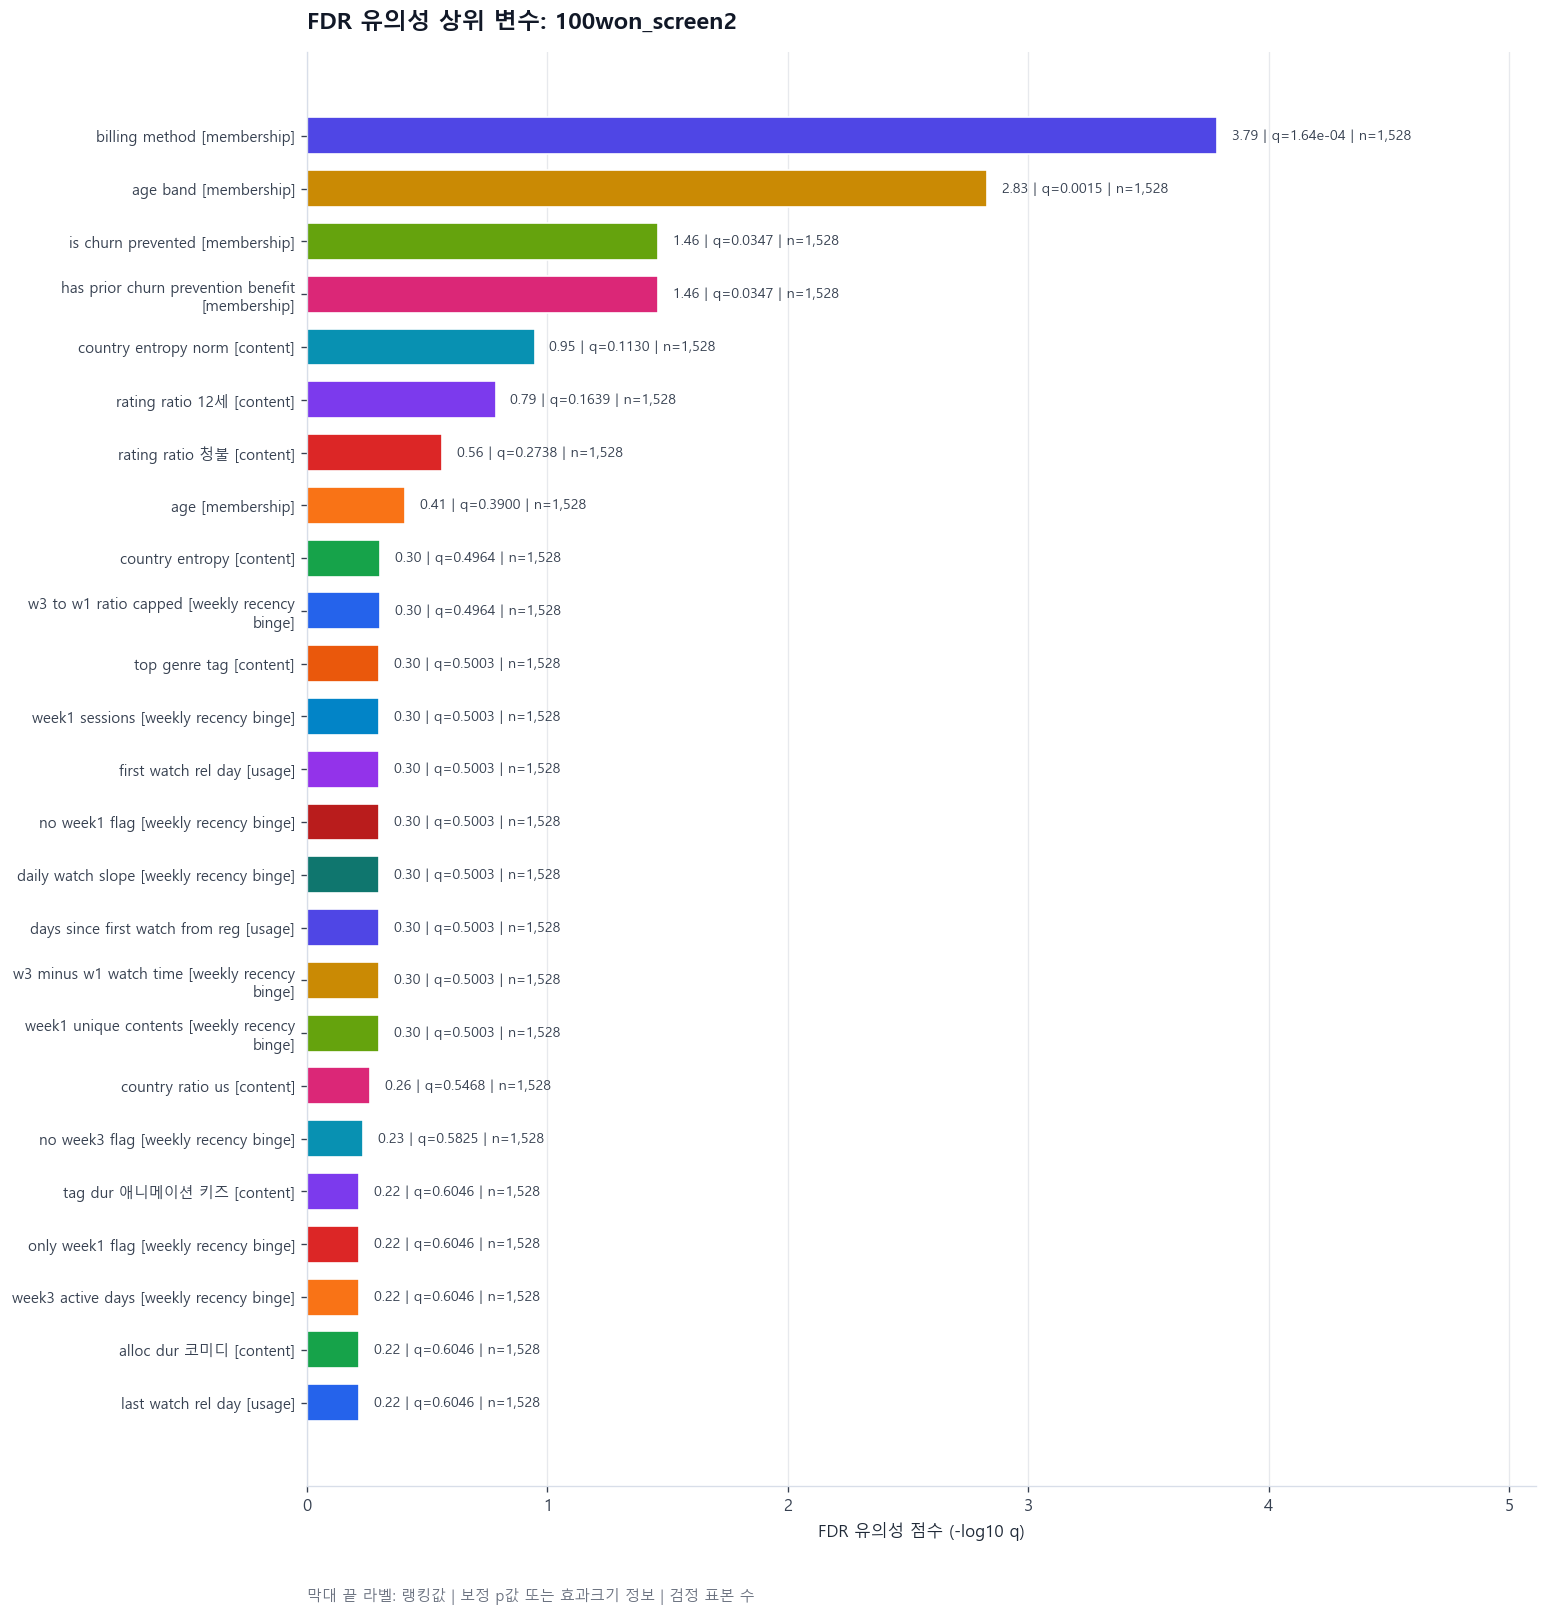

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_top_effect_100won_screen2.png


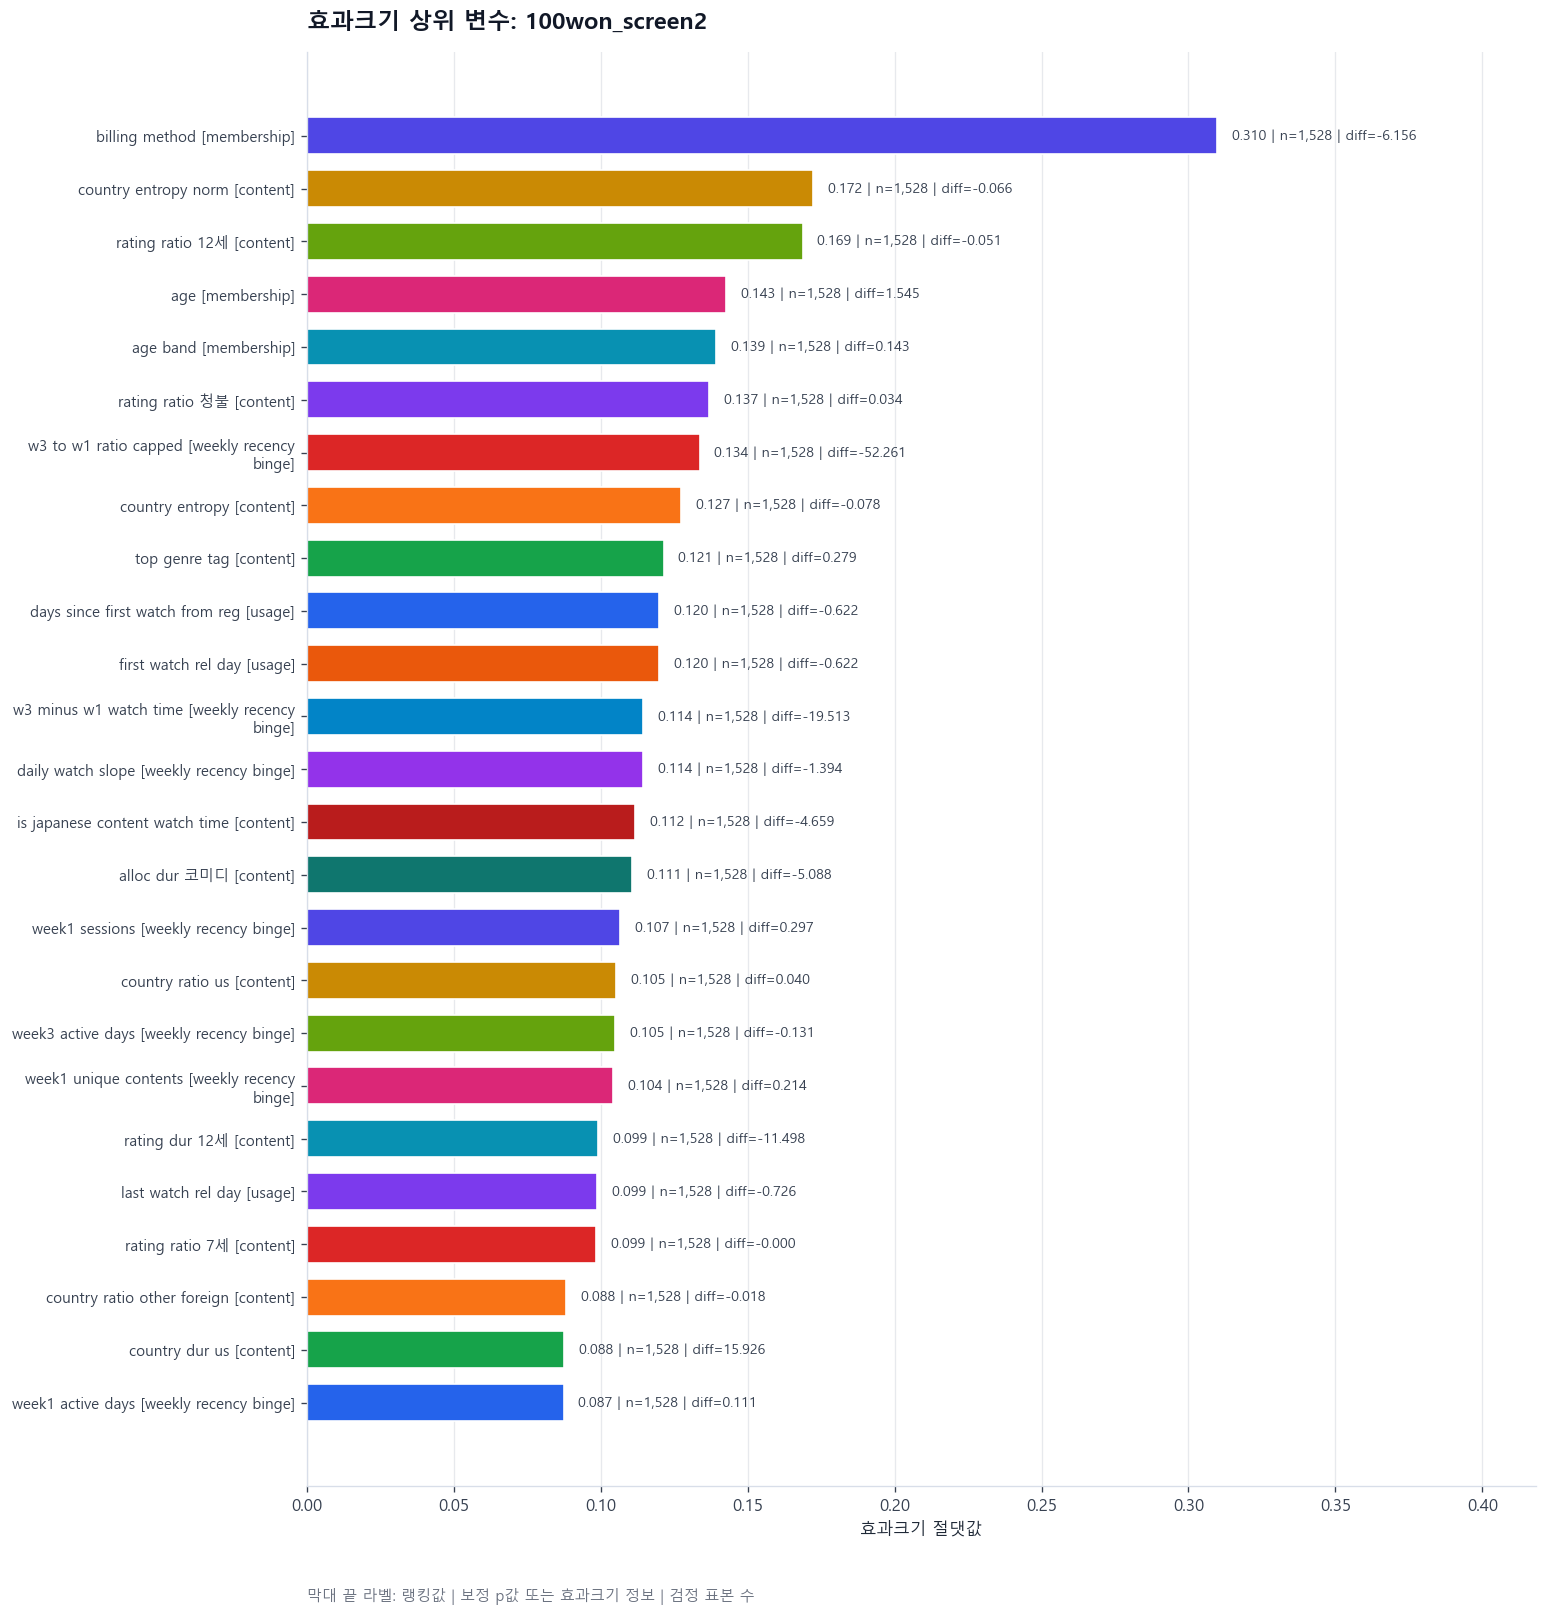

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_top_fdr_100won_screen4.png


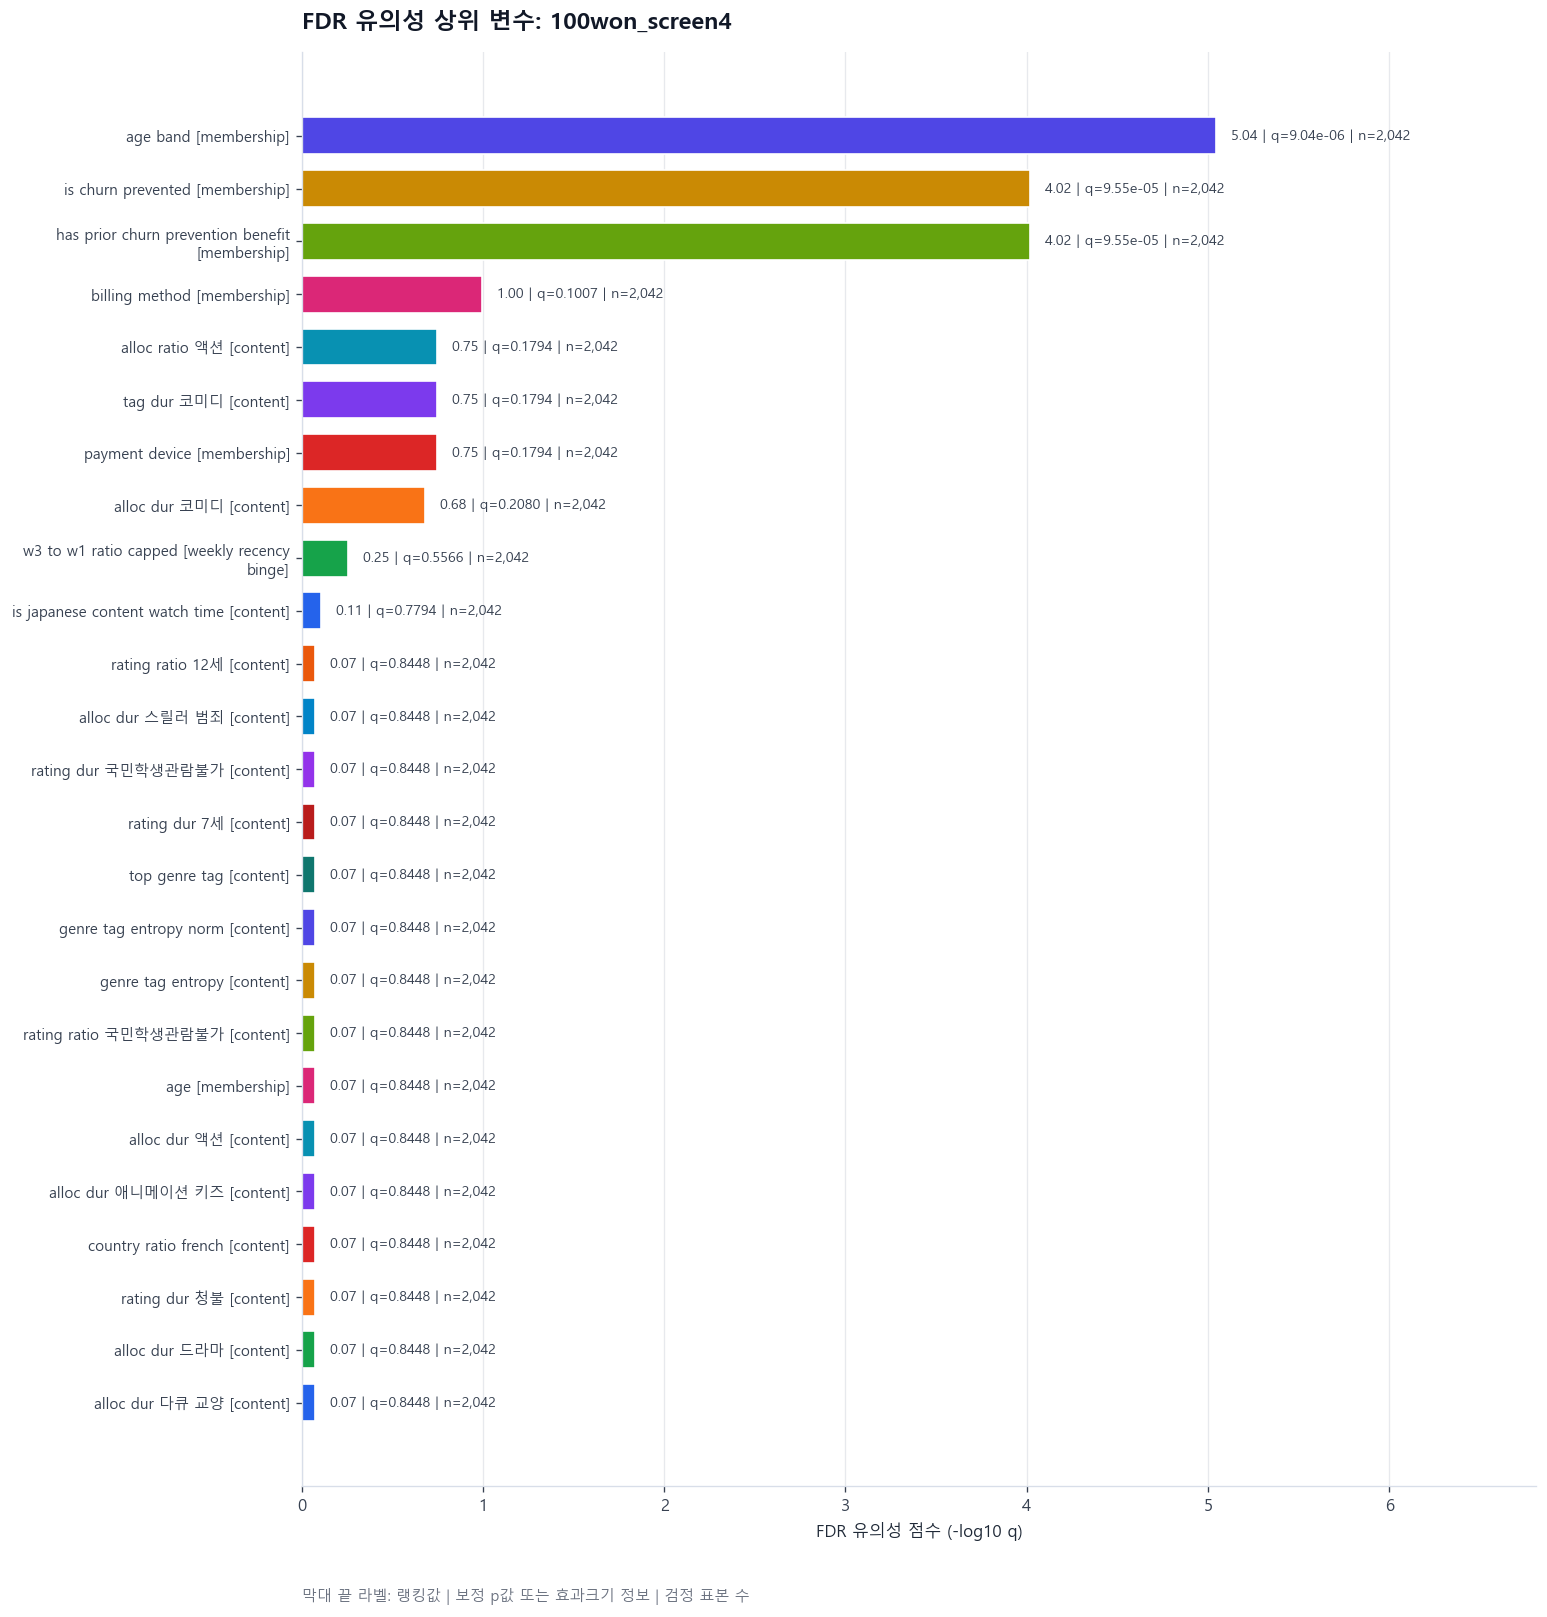

saved: C:\Code\ott-churn-prediction\park.ingyeom\reports\figures\06_significance_tests_and_eda\all\06_top_effect_100won_screen4.png


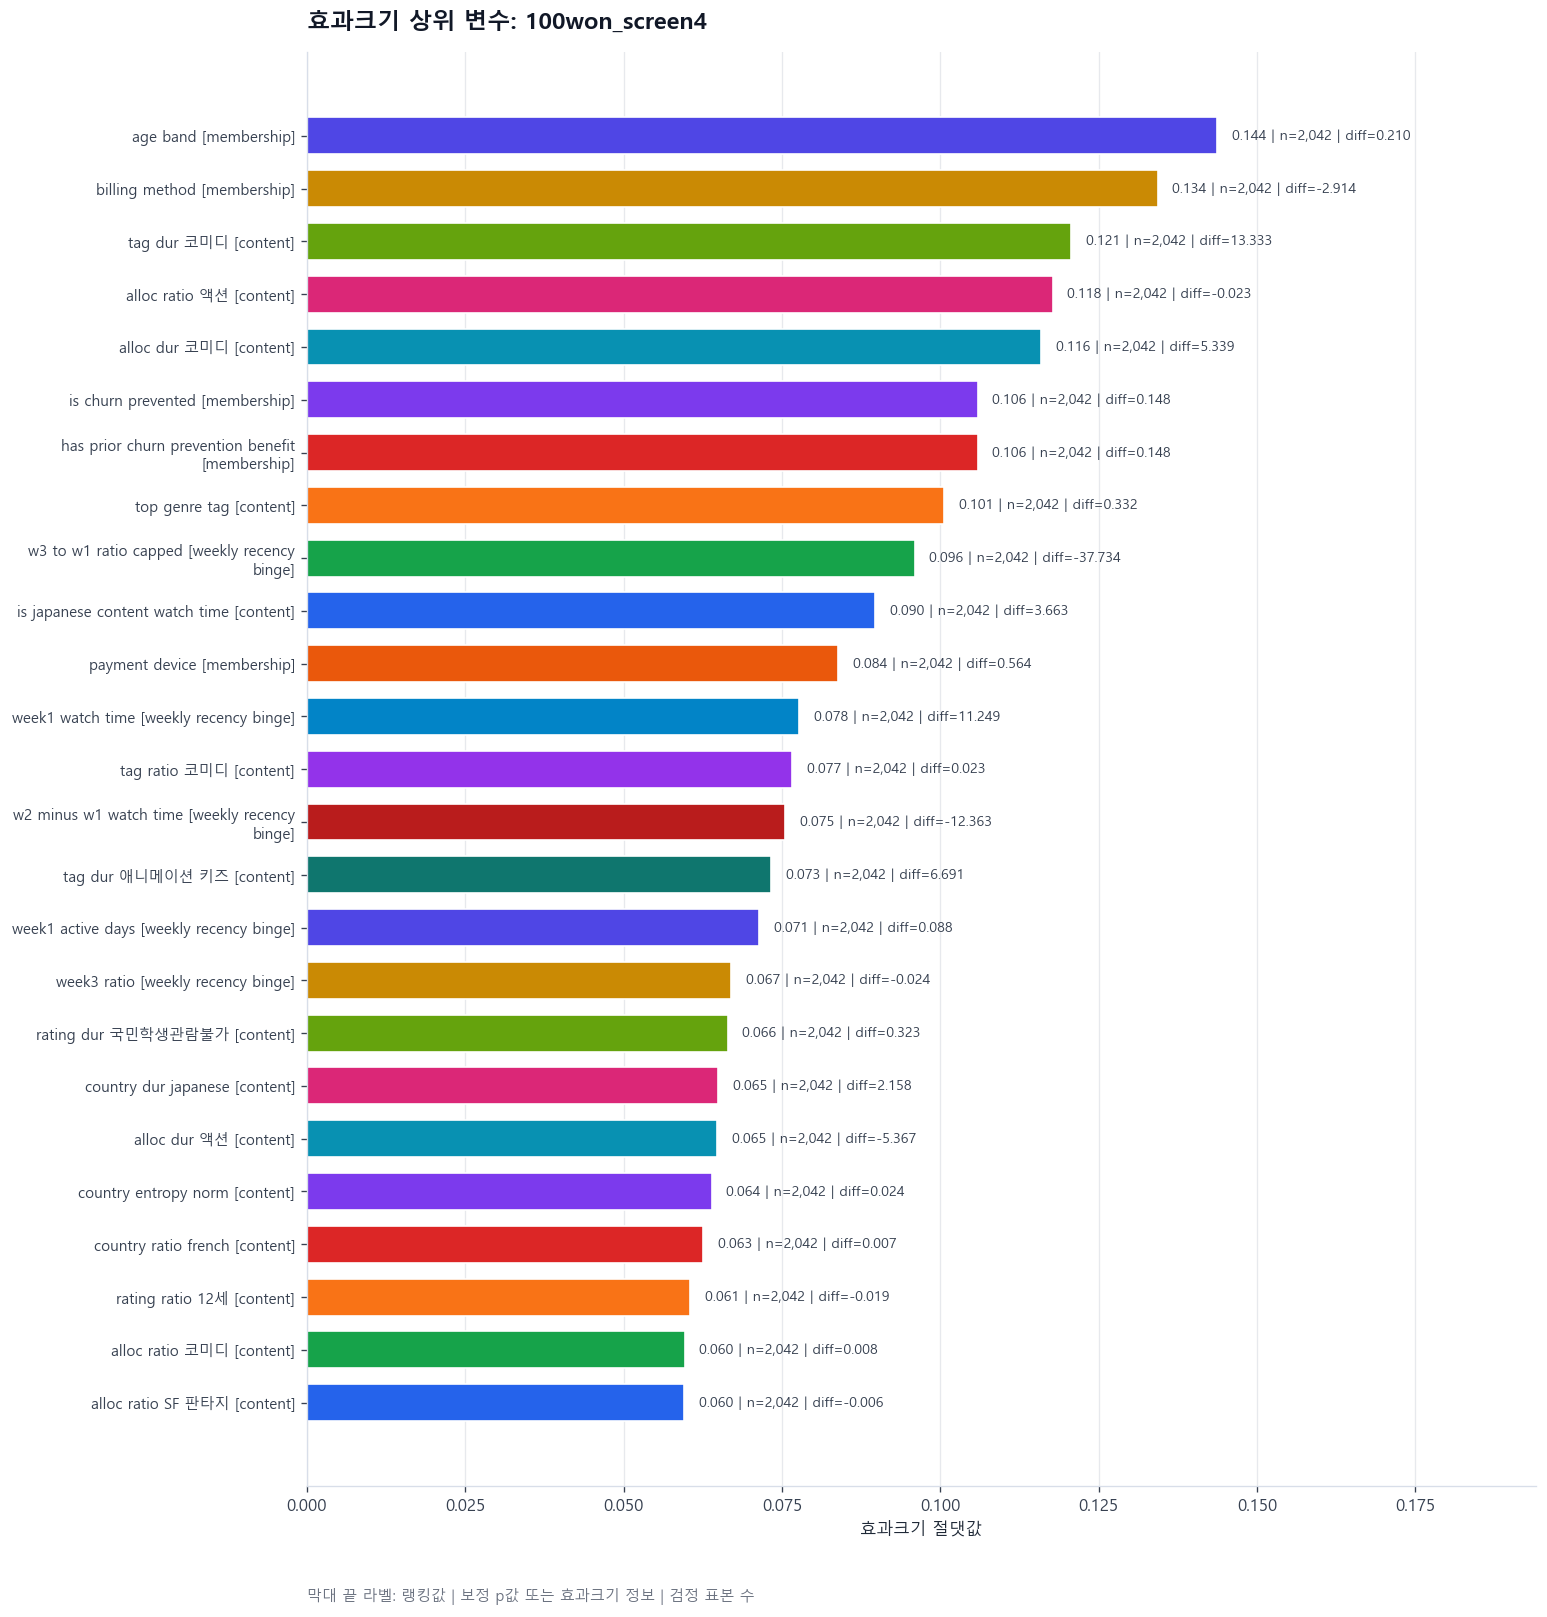

In [52]:
# 6-15. p-value / effect size ranking plot

if RUN_CORE_FIGURES or RUN_ALL_FIGURES:
    groups_for_rankings = ['all', '100won'] if not RUN_ALL_FIGURES else ['all', '100won', '100won_screen2', '100won_screen4']
    for group_name in groups_for_rankings:
        if group_name in set(all_results['analysis_group']):
            plot_top_rankings(
                all_results,
                'p_value_fdr_by_group',
                f'Top features by FDR significance: {group_name}',
                f'06_top_fdr_{group_name}.png',
                group=group_name,
                top_n=25,
            )
            plot_top_rankings(
                all_results,
                'effect_size',
                f'Top features by effect size: {group_name}',
                f'06_top_effect_{group_name}.png',
                group=group_name,
                top_n=25,
            )

## 6-16. 07번 모델링 후보 변수 저장

06번은 모델링 직전의 필터 역할을 한다. 다만 유의성 검정에서 약한 변수라도 모델에서 상호작용으로 살아날 수 있으므로, 후보군은 너무 좁히지 않는다.

In [53]:
# 6-16. 모델링 후보 변수 목록 생성

candidate_rows = all_results.loc[
    all_results['decision'].isin(['KEEP_CORE', 'KEEP_SUPPORTING', 'MODEL_ONLY'])
].copy()

# 분석 그룹 전체/100원딜에서 한 번이라도 후보로 잡힌 feature를 우선 모델링 후보로 둔다.
priority_groups = ['all', '100won', '100won_screen2', '100won_screen4']
candidate_features = candidate_rows.loc[candidate_rows['analysis_group'].isin(priority_groups), 'feature'].dropna().unique().tolist()

# 비즈니스상 반드시 넣을 후보는 검정 결과와 별개로 보존한다.
force_include = [c for c in [
    'is_100won', 'is_promotion', 'max_screen', 'price', 'age', 'gender', 'is_user_verified',
    'is_churn_prevented', 'has_prior_churn_prevention_benefit',
    'total_watch_time', 'total_sessions', 'unique_contents', 'unique_days',
    'week1_ratio', 'week3_ratio', 'w3_minus_w1_watch_time', 'daily_watch_slope',
    'promo_x_2screen', 'promo_x_4screen',
    'family_2screen_lifestyle', 'premium_action_trial_risk',
] if c in df.columns]

candidate_features = sorted(set(candidate_features).union(force_include))

candidate_feature_table = []
for feature in candidate_features:
    row = all_results.loc[(all_results['feature'] == feature) & (all_results['analysis_group'].isin(priority_groups))].copy()
    if row.empty:
        best = {'feature': feature, 'source': 'force_include'}
    else:
        row = row.sort_values(['decision', 'p_value_fdr_by_group', 'p_value'], na_position='last')
        best = row.iloc[0].to_dict()
        best['source'] = 'significance_or_force_include' if feature in force_include else 'significance'
    candidate_feature_table.append(best)

candidate_feature_table = pd.DataFrame(candidate_feature_table)
candidate_feature_table.to_csv(OUTPUT_DATA_DIR / '06_candidate_features_for_modeling.csv', index=False, encoding='utf-8-sig')

# feature list txt도 저장
with open(OUTPUT_DATA_DIR / '06_candidate_feature_list_for_modeling.txt', 'w', encoding='utf-8') as f:
    for c in candidate_features:
        f.write(c + '\n')

print('n candidate features:', len(candidate_features))
show_table(candidate_feature_table.head(100), max_rows=100, max_cols=20)


n candidate features: 39


,analysis_group,feature_family,feature,feature_type,test_type,n_total,n_feature_0,n_feature_1,target_rate_feature_0,target_rate_feature_1,rate_or_mean_diff,abs_diff,odds_ratio,effect_size,p_value,secondary_p_value,test_used,decision_pre_fdr,n_target_0,n_target_1
0,all,membership,age,numeric,welch_t_and_mannwhitney,14922,NaN,NaN,NaN,NaN,2.362888,2.362888,NaN,0.219757,2.810145e-35,1.578402e-48,welch_t,TESTED,4846.0,10076.0
1,all,membership,age_band,categorical,chi_square_categorical,14922,NaN,NaN,NaN,NaN,0.230046,0.230046,NaN,0.131691,7.157993e-54,NaN,chi_square,TESTED,NaN,NaN
2,100won_screen4,content,alloc_dur_코미디,numeric,welch_t_and_mannwhitney,2042,NaN,NaN,NaN,NaN,5.338858,5.338858,NaN,0.115859,9.962324e-03,1.952736e-01,welch_t,TESTED,1060.0,982.0
3,100won_screen4,content,alloc_ratio_액션,numeric,welch_t_and_mannwhitney,2042,NaN,NaN,NaN,NaN,-0.022932,0.022932,NaN,-0.117730,7.520300e-03,3.087974e-01,welch_t,TESTED,1060.0,982.0
4,all,membership,billing_method,numeric,welch_t_and_mannwhitney,14922,NaN,NaN,NaN,NaN,-4.084680,4.084680,NaN,-0.208187,4.140927e-30,4.566215e-29,welch_t,TESTED,4846.0,10076.0
5,100won_screen2,content,country_entropy_norm,numeric,welch_t_and_mannwhitney,1528,NaN,NaN,NaN,NaN,-0.065511,0.065511,NaN,-0.172165,3.363777e-03,1.369588e-03,welch_t,TESTED,397.0,1131.0
6,all,weekly_recency_binge,daily_watch_slope,numeric,welch_t_and_mannwhitney,14922,NaN,NaN,NaN,NaN,-0.528226,0.528226,NaN,-0.040523,2.139071e-02,4.923456e-02,welch_t,TESTED,4846.0,10076.0
7,all,usage,days_since_last_watch_to_obs_end,numeric,welch_t_and_mannwhitney,14922,NaN,NaN,NaN,NaN,0.252187,0.252187,NaN,0.048362,5.006819e-03,2.261396e-02,welch_t,TESTED,4846.0,10076.0
8,100won_screen2,interaction_segment,discount_sensitive_risk,binary,chi_square_or_fisher_2x2,1528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INSUFFICIENT_DATA,NaN,NaN
9,100won_screen4,interaction_segment,family_2screen_lifestyle,binary,chi_square_or_fisher_2x2,2042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INSUFFICIENT_DATA,NaN,NaN


## 6-17. 최종 체크

이 노트북의 산출물은 다음과 같다.

- `06_significance_all_results.csv`
- `06_significance_all_results_with_decision.csv`
- `06_significance_significant_or_model_candidates.csv`
- `06_rejected_or_weak_hypotheses.csv`
- `06_hypothesis_decision_table.csv`
- `06_candidate_features_for_modeling.csv`
- `06_candidate_feature_list_for_modeling.txt`
- `park.ingyeom/reports/figures/06_significance_tests_and_eda/06_*.png`

다음 단계는 `07_modeling_baseline.ipynb`이다.

In [54]:
# 6-17. 최종 산출물 체크

expected_data_outputs = [
    OUTPUT_DATA_DIR / '06_significance_all_results.csv',
    OUTPUT_DATA_DIR / '06_significance_all_results_with_decision.csv',
    OUTPUT_DATA_DIR / '06_significance_significant_or_model_candidates.csv',
    OUTPUT_DATA_DIR / '06_rejected_or_weak_hypotheses.csv',
    OUTPUT_DATA_DIR / '06_candidate_features_for_modeling.csv',
    OUTPUT_DATA_DIR / '06_candidate_feature_list_for_modeling.txt',
]

expected_table_outputs = [
    TABLES_DIR / '06_input_basic_summary.csv',
    TABLES_DIR / '06_analysis_group_summary.csv',
    TABLES_DIR / '06_feature_family_summary.csv',
    TABLES_DIR / '06_decision_counts_by_group.csv',
    TABLES_DIR / '06_hypothesis_decision_table.csv',
]

current_mode_figures = sorted(FIGURES_DIR.glob('06_*.png'))
legacy_top_level_figures = sorted(OUTPUT_FIGURE_DIR.glob('06_*.png'))
legacy_test_tables = sorted(TABLES_DIR.glob('06_tests_*.csv'))
cache_family_files = sorted(CACHE_DIR.glob('06_tests_*.csv'))

final_rows = []

def add_check(check, value, passed):
    final_rows.append({'check': check, 'value': value, 'pass': bool(passed)})

add_check('project_root_is_repo_root', str(PROJECT_ROOT), (PROJECT_ROOT / '.git').exists())
add_check('data_root_is_repo_data', str(DATA_ROOT), DATA_ROOT.exists())
add_check('reports_dir_is_park_reports', str(REPORTS_DIR), REPORTS_DIR == WORK_ROOT / 'reports')
add_check('input_data_dir_is_05_reports_data', str(INPUT_05_DATA_DIR), INPUT_05_DATA_DIR == REPORTS_DIR / 'data' / '05_content_feature_engineering')
add_check('output_data_dir_under_reports_data_06', str(OUTPUT_DATA_DIR), OUTPUT_DATA_DIR == REPORTS_DIR / 'data' / NOTEBOOK_ID)
add_check('output_table_dir_under_reports_tables_06', str(TABLES_DIR), TABLES_DIR == REPORTS_DIR / 'tables' / NOTEBOOK_ID)
add_check('figure_dir_under_reports_figures_06_core_or_all', str(FIGURES_DIR), FIGURES_DIR in {CORE_FIGURE_DIR, ALL_FIGURE_DIR})
add_check('input_rows_is_14922', len(df), len(df) == 14922)
add_check('membership_row_id_unique', df['membership_row_id'].is_unique if 'membership_row_id' in df.columns else False, 'membership_row_id' in df.columns and df['membership_row_id'].is_unique)
add_check('target_is_binary_0_1', sorted(pd.unique(df[TARGET]).tolist()), set(pd.unique(df[TARGET])) == {0, 1})
add_check('required_analysis_groups_exist', sorted(analysis_groups.keys()), {'all', '100won', 'non_100won', '100won_screen1', '100won_screen2', '100won_screen4'}.issubset(set(analysis_groups)))
add_check('all_results_rows_gt_zero', len(all_results), len(all_results) > 0)
add_check('tested_results_rows_gt_zero', int((all_results['decision_pre_fdr'] == 'TESTED').sum()) if 'decision_pre_fdr' in all_results.columns else 0, 'decision_pre_fdr' in all_results.columns and int((all_results['decision_pre_fdr'] == 'TESTED').sum()) > 0)
add_check('p_value_nonnull_rows_gt_zero', int(all_results['p_value'].notna().sum()) if 'p_value' in all_results.columns else 0, 'p_value' in all_results.columns and int(all_results['p_value'].notna().sum()) > 0)
add_check('decision_column_exists', 'decision' in all_results.columns, 'decision' in all_results.columns)
add_check('candidate_features_gt_zero', len(candidate_features), len(candidate_features) > 0)
add_check('figures_created_if_enabled', len(current_mode_figures), (not RUN_CORE_FIGURES and not RUN_ALL_FIGURES) or len(current_mode_figures) > 0)
add_check('no_legacy_top_level_figures', [p.name for p in legacy_top_level_figures[:10]], len(legacy_top_level_figures) == 0)
add_check('no_family_cache_files_in_tables', [p.name for p in legacy_test_tables[:10]], len(legacy_test_tables) == 0)
add_check('cache_family_files_created_or_cache_used', len(cache_family_files), USE_CACHE or len(cache_family_files) > 0)

for path in expected_data_outputs:
    add_check(f'data_output_exists::{path.name}', str(path), path.exists() and path.stat().st_size > 0)
for path in expected_table_outputs:
    add_check(f'table_output_exists::{path.name}', str(path), path.exists() and path.stat().st_size > 0)

final_checks_path = TABLES_DIR / '06_final_checks.csv'
final_checks = pd.DataFrame(final_rows)
final_checks.to_csv(final_checks_path, index=False, encoding='utf-8-sig')
add_check('final_checks_output_exists', str(final_checks_path), final_checks_path.exists() and final_checks_path.stat().st_size > 0)
final_checks = pd.DataFrame(final_rows)
final_checks.to_csv(final_checks_path, index=False, encoding='utf-8-sig')

show_table(final_checks, max_rows=100, max_cols=10)

if not final_checks['pass'].all():
    failed = final_checks.loc[~final_checks['pass']]
    raise AssertionError(f'06번 최종 검산 실패:\n{failed}')

print('06_significance_tests_and_eda passed final checks.')


,check,value,pass
0,project_root_is_repo_root,C:\Code\ott-churn-prediction,True
1,data_root_is_repo_data,C:\Code\ott-churn-prediction\_data,True
2,reports_dir_is_park_reports,C:\Code\ott-churn-prediction\park.ingyeom\reports,True
3,input_data_dir_is_05_reports_data,C:\Code\ott-churn-prediction\park.ingyeom\repo...,True
4,output_data_dir_under_reports_data_06,C:\Code\ott-churn-prediction\park.ingyeom\repo...,True
5,output_table_dir_under_reports_tables_06,C:\Code\ott-churn-prediction\park.ingyeom\repo...,True
6,figure_dir_under_reports_figures_06_core_or_all,C:\Code\ott-churn-prediction\park.ingyeom\repo...,True
7,input_rows_is_14922,14922,True
8,membership_row_id_unique,True,True
9,target_is_binary_0_1,"[0, 1]",True


06_significance_tests_and_eda passed final checks.
